In [1]:
# CELL 1 - Khai báo thư viện và thiết lập tái lập kết quả
# Mục tiêu: import thư viện cần dùng, cố định seed và chọn thiết bị chạy.
# Giữ một SEED chung giúp các mô hình được so sánh trong cùng điều kiện ngẫu nhiên.

import warnings
warnings.filterwarnings("ignore")

import copy
import random
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import yfinance as yf


SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print("SEED:", SEED)


DEVICE: cpu
SEED: 42


In [2]:
# CELL 2 - Cấu hình dữ liệu và tham số mô hình
# Mục tiêu: khai báo danh sách mã cổ phiếu, khoảng thời gian, feature đầu vào và kích thước mô hình.
# Các tham số ở đây là điểm điều chỉnh chính khi muốn thử nghiệm lại.

TICKERS = [
    "AAPL", "ADBE", "AMD", "CMCSA", "COST",
    "INTC", "INTU", "MSFT", "QCOM", "SBUX"
]

START_DATE = "2005-01-01"
END_DATE   = "2025-06-01"

BASE_FEATURE_COLS = [
    "Close", "Volume", "Return", "MA5", "MA20", "Volatility5", "Volatility20"
]
TSN_FEATURE_COLS = [
    "MA50", "EMA20", "Close_Minus_MA20", "MA20_Slope",
    "DayOfWeek", "Month", "IsMonthEnd", "Sin_DayOfWeek", "Cos_DayOfWeek",
    "Return_ZScore"
]
FEATURE_COLS = BASE_FEATURE_COLS + TSN_FEATURE_COLS

TARGET_COL = "Close"
TARGET_IDX = FEATURE_COLS.index(TARGET_COL)

LOOKBACK = 20
DIRECTION_EPS = 0.0

LSTM_HIDDEN = 64
GNN_HIDDEN = 32
MLP_HIDDEN = 64
DROPOUT = 0.2

print("TICKERS:", TICKERS)
print("FEATURE_COLS:", FEATURE_COLS)
print("LOOKBACK:", LOOKBACK)



TICKERS: ['AAPL', 'ADBE', 'AMD', 'CMCSA', 'COST', 'INTC', 'INTU', 'MSFT', 'QCOM', 'SBUX']
FEATURE_COLS: ['Close', 'Volume', 'Return', 'MA5', 'MA20', 'Volatility5', 'Volatility20', 'MA50', 'EMA20', 'Close_Minus_MA20', 'MA20_Slope', 'DayOfWeek', 'Month', 'IsMonthEnd', 'Sin_DayOfWeek', 'Cos_DayOfWeek', 'Return_ZScore']
LOOKBACK: 20


In [3]:
# CELL 3 - Tải dữ liệu và tạo feature kỹ thuật
# Mục tiêu: tải dữ liệu từng mã, làm sạch dữ liệu và tạo MA/volatility/return.
# Feature được tạo theo từng ticker trước khi ghép thành bộ dữ liệu chung.

def download_one_ticker(ticker: str, start: str, end: str) -> pd.DataFrame:
    df = yf.download(
        ticker,
        start=start,
        end=end,
        interval="1d",
        auto_adjust=False,
        progress=False,
        threads=False
    )

    if df.empty:
        raise ValueError(f"Không tải được dữ liệu cho {ticker}")

    # Nếu yfinance trả về multi-index columns thì đưa về tên cột đơn.
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]

    keep_cols = [c for c in ["Open", "High", "Low", "Close", "Volume"] if c in df.columns]
    df = df[keep_cols].copy()

    df["Close"] = df["Close"].ffill()
    df["Volume"] = df["Volume"].fillna(0.0)

    df["Return"] = df["Close"].pct_change().fillna(0.0)
    df["MA5"] = df["Close"].rolling(5).mean()
    df["MA20"] = df["Close"].rolling(20).mean()
    df["Volatility5"] = df["Return"].rolling(5).std()
    df["Volatility20"] = df["Return"].rolling(20).std()

    # Thêm TSN features
    df["MA50"] = df["Close"].rolling(50).mean()
    df["EMA20"] = df["Close"].ewm(span=20, adjust=False).mean()
    df["Close_Minus_MA20"] = df["Close"] - df["MA20"]
    df["MA20_Slope"] = df["MA20"].diff()
    
    df["DayOfWeek"] = df.index.dayofweek
    df["Month"] = df.index.month
    df["IsMonthEnd"] = df.index.is_month_end.astype(int)
    df["Sin_DayOfWeek"] = np.sin(2 * np.pi * df["DayOfWeek"] / 5.0)
    df["Cos_DayOfWeek"] = np.cos(2 * np.pi * df["DayOfWeek"] / 5.0)
    
    roll_mean20 = df["Return"].rolling(20).mean()
    roll_std20 = df["Return"].rolling(20).std()
    df["Return_ZScore"] = (df["Return"] - roll_mean20) / (roll_std20 + 1e-8)

    df = df.dropna().copy()
    df.index = pd.to_datetime(df.index)
    return df


data_dict = {}
for ticker in TICKERS:
    data_dict[ticker] = download_one_ticker(ticker, START_DATE, END_DATE)

# Giao ngày giữa tất cả mã để mỗi timestep có đủ dữ liệu cho mỗi ticker.
common_index = None
for ticker in TICKERS:
    idx = data_dict[ticker].index
    common_index = idx if common_index is None else common_index.intersection(idx)

common_index = common_index.sort_values()

for ticker in TICKERS:
    data_dict[ticker] = data_dict[ticker].loc[common_index].copy()

print("Số ngày chung:", len(common_index))
print("Ngày đầu:", common_index.min())
print("Ngày cuối:", common_index.max())

for ticker in TICKERS[:3]:
    print(ticker, data_dict[ticker].shape)
    print(data_dict[ticker].head(2))
    print()



Số ngày chung: 5086
Ngày đầu: 2005-03-15 00:00:00
Ngày cuối: 2025-05-30 00:00:00
AAPL (5086, 20)
                Open      High       Low     Close     Volume    Return  \
Date                                                                      
2005-03-15  1.451429  1.469286  1.437500  1.462857  508608800  0.015873   
2005-03-16  1.471786  1.511071  1.456429  1.470714  697813200  0.005371   

                 MA5      MA20  Volatility5  Volatility20      MA50     EMA20  \
Date                                                                            
2005-03-15  1.433786  1.525696     0.018349      0.025494  1.389264  1.477355   
2005-03-16  1.446857  1.520295     0.005807      0.023173  1.396075  1.476723   

            Close_Minus_MA20  MA20_Slope  DayOfWeek  Month  IsMonthEnd  \
Date                                                                     
2005-03-15         -0.062839   -0.002420          1      3           0   
2005-03-16         -0.049581   -0.005402          2    

In [4]:
# CELL 4 - Chuyển dữ liệu thành tensor 3 chiều
# Mục tiêu: gom dữ liệu thành dạng [thời gian, số mã, số feature] để dùng chung cho các mô hình.
# Chỉ giữ những ngày xuất hiện đầy đủ ở tất cả ticker để tránh lệch index.

def build_feature_tensor(data_dict: Dict[str, pd.DataFrame],
                         tickers: List[str],
                         feature_cols: List[str]) -> Tuple[np.ndarray, np.ndarray, np.ndarray, pd.DatetimeIndex]:
    dates = data_dict[tickers[0]].index

    T = len(dates)
    N = len(tickers)
    F = len(feature_cols)

    features_3d = np.zeros((T, N, F), dtype=np.float32)
    close_2d = np.zeros((T, N), dtype=np.float32)
    return_2d = np.zeros((T, N), dtype=np.float32)

    for j, ticker in enumerate(tickers):
        df = data_dict[ticker]

        features_3d[:, j, :] = df[feature_cols].values.astype(np.float32)
        close_2d[:, j] = df["Close"].values.astype(np.float32)
        return_2d[:, j] = df["Return"].values.astype(np.float32)

    return features_3d, close_2d, return_2d, dates


features_3d, close_2d, return_2d, dates = build_feature_tensor(
    data_dict=data_dict,
    tickers=TICKERS,
    feature_cols=FEATURE_COLS
)

print("features_3d:", features_3d.shape)
print("close_2d:", close_2d.shape)
print("return_2d:", return_2d.shape)
print("dates:", len(dates))


features_3d: (5086, 10, 17)
close_2d: (5086, 10)
return_2d: (5086, 10)
dates: 5086


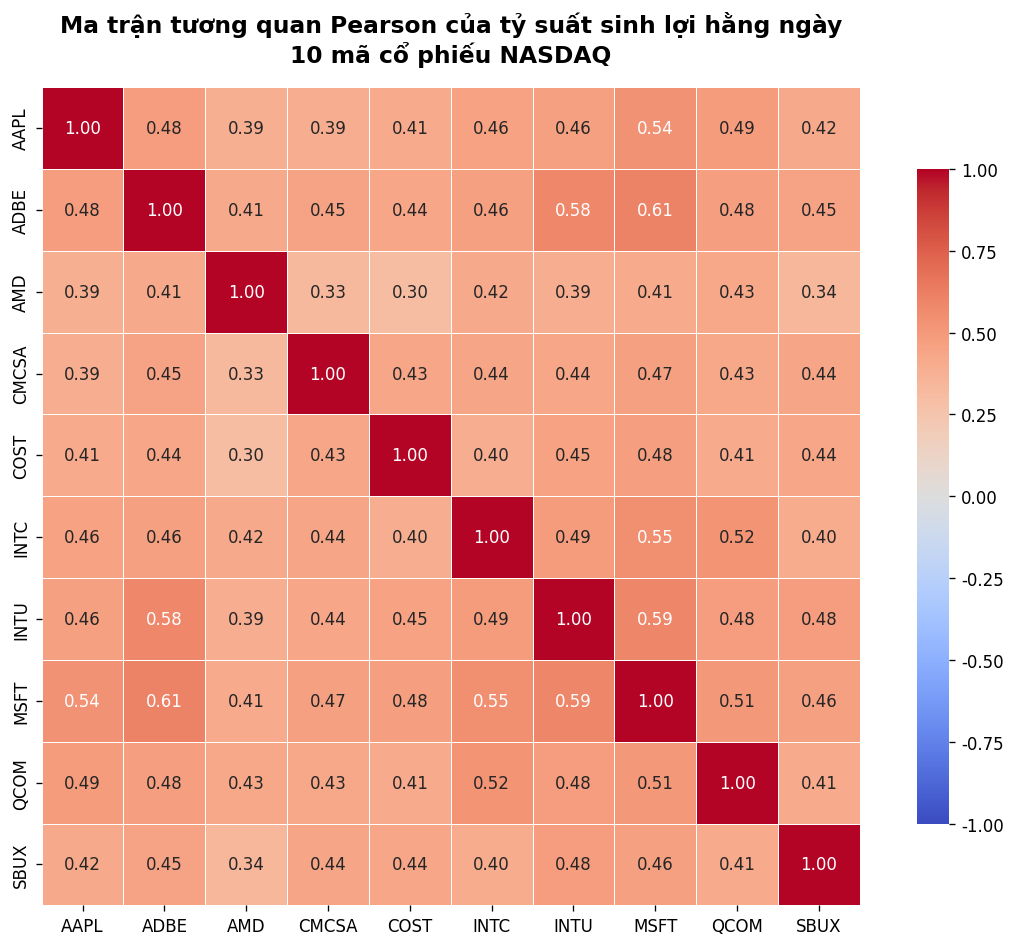

In [5]:
# CELL 4B - Biểu đồ nhiệt tương quan Pearson (EDA)
# Mục tiêu: Phân tích tương quan tuyến tính tỷ suất sinh lợi hàng ngày giữa 10 mã cổ phiếu NASDAQ.
# Đây là bước tiền xử lý/EDA quan trọng nhằm giải thích tại sao mô hình đồ thị GNN lại phù hợp với dữ liệu này.

import seaborn as sns
import matplotlib.pyplot as plt

# Tính ma trận tương quan từ return_2d thô
corr_matrix = np.corrcoef(return_2d.T)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    xticklabels=TICKERS, 
    yticklabels=TICKERS,
    vmin=-1, 
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)
plt.title(
    "Ma trận tương quan Pearson của tỷ suất sinh lợi hằng ngày\n10 mã cổ phiếu NASDAQ",
    fontsize=14,
    fontweight="bold",
    pad=15
)
plt.tight_layout()
plt.show()

In [6]:
# CELL 5 - Hàm tiện ích đánh giá và chuẩn hóa graph
# Mục tiêu: chuẩn hóa ma trận kề và tính MSE, MAE, RMSE, Directional Accuracy.
# Các hàm này được dùng lại cho Linear, LSTM và hai biến thể Hybrid.

def normalize_adjacency(adj: np.ndarray) -> np.ndarray:
    """
    Chuẩn hóa đối xứng ma trận kề: D^{-1/2} A D^{-1/2}.
    adj: [N, N]
    """
    adj = adj.astype(np.float32)
    deg = adj.sum(axis=1)
    deg_inv_sqrt = np.power(np.maximum(deg, 1e-8), -0.5)
    D_inv_sqrt = np.diag(deg_inv_sqrt)
    adj_norm = D_inv_sqrt @ adj @ D_inv_sqrt
    return adj_norm.astype(np.float32)


def compute_metrics(y_true: np.ndarray,
                    y_pred: np.ndarray,
                    last_close: np.ndarray,
                    eps: float = 0.0):
    y_true_f = y_true.reshape(-1)
    y_pred_f = y_pred.reshape(-1)
    last_f = last_close.reshape(-1)

    mse = mean_squared_error(y_true_f, y_pred_f)
    mae = mean_absolute_error(y_true_f, y_pred_f)
    rmse = float(np.sqrt(mse))

    true_up = (y_true_f - last_f) > eps
    pred_up = (y_pred_f - last_f) > eps
    directional_accuracy = float((true_up == pred_up).mean())

    return {
        "MSE": float(mse),
        "MAE": float(mae),
        "RMSE": float(rmse),
        "Directional_Accuracy": directional_accuracy
    }


def compute_full_evaluation(y_true, y_pred, last_close, tickers=None, direction_eps=0.0):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    last_close = np.asarray(last_close, dtype=np.float64)

    y_true_f = y_true.reshape(-1)
    y_pred_f = y_pred.reshape(-1)
    last_f = last_close.reshape(-1)

    mse = mean_squared_error(y_true_f, y_pred_f)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true_f, y_pred_f)

    mape = np.mean(np.abs((y_true_f - y_pred_f) / np.maximum(np.abs(y_true_f), 1e-8)))

    ss_res = np.sum((y_true_f - y_pred_f) ** 2)
    ss_tot = np.sum((y_true_f - np.mean(y_true_f)) ** 2)
    r2 = 1.0 - ss_res / (ss_tot + 1e-12)

    true_up = (y_true_f - last_f) > direction_eps
    pred_up = (y_pred_f - last_f) > direction_eps
    directional_accuracy = np.mean(true_up == pred_up)

    return {
        "MSE": float(mse),
        "RMSE": float(rmse),
        "MAE": float(mae),
        "MAPE": float(mape),
        "R_Squared": float(r2),
        "Directional_Accuracy": float(directional_accuracy)
    }


def backtest_long_only_strategy(y_true, y_pred, last_close, tickers=None, direction_eps=0.0):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    last_close = np.asarray(last_close, dtype=np.float64)

    actual_returns = (y_true - last_close) / np.maximum(last_close, 1e-8)
    predicted_changes = y_pred - last_close

    signals = predicted_changes > direction_eps

    strategy_daily_returns = []

    for day_idx in range(signals.shape[0]):
        day_signal = signals[day_idx]
        day_actual_returns = actual_returns[day_idx]

        if day_signal.sum() == 0:
            strategy_return = 0.0
        else:
            strategy_return = day_actual_returns[day_signal].mean()

        strategy_daily_returns.append(strategy_return)

    strategy_daily_returns = np.asarray(strategy_daily_returns, dtype=np.float64)
    buyhold_daily_returns = actual_returns.mean(axis=1)

    strategy_portfolio = np.cumprod(1.0 + strategy_daily_returns)
    buyhold_portfolio = np.cumprod(1.0 + buyhold_daily_returns)

    return {
        "strategy_daily_returns": strategy_daily_returns,
        "buyhold_daily_returns": buyhold_daily_returns,
        "strategy_portfolio": strategy_portfolio,
        "buyhold_portfolio": buyhold_portfolio
    }


def compute_sharpe_ratio(daily_returns, annualization=252):
    daily_returns = np.asarray(daily_returns, dtype=np.float64)
    if daily_returns.std() < 1e-12:
        return 0.0
    return float(np.sqrt(annualization) * daily_returns.mean() / daily_returns.std())


def compute_maximum_drawdown(portfolio_values):
    portfolio_values = np.asarray(portfolio_values, dtype=np.float64)
    running_max = np.maximum.accumulate(portfolio_values)
    drawdown = (portfolio_values - running_max) / np.maximum(running_max, 1e-12)
    return float(drawdown.min())


def compute_win_rate(daily_returns):
    daily_returns = np.asarray(daily_returns, dtype=np.float64)
    return float(np.mean(daily_returns > 0))


def backtest_topk_long_short_strategy(y_true, y_pred, last_close, K=2):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    last_close = np.asarray(last_close, dtype=np.float64)

    actual_returns = (y_true - last_close) / np.maximum(last_close, 1e-8)
    predicted_returns = (y_pred - last_close) / np.maximum(last_close, 1e-8)

    strategy_daily_returns = []

    for day_idx in range(y_true.shape[0]):
        pred_ret_day = predicted_returns[day_idx]
        actual_ret_day = actual_returns[day_idx]

        sorted_indices = np.argsort(pred_ret_day)

        short_indices = sorted_indices[:K]
        long_indices = sorted_indices[-K:]

        long_return = actual_ret_day[long_indices].mean()
        short_return = actual_ret_day[short_indices].mean()

        day_portfolio_return = long_return - short_return
        strategy_daily_returns.append(day_portfolio_return)

    strategy_daily_returns = np.asarray(strategy_daily_returns, dtype=np.float64)
    buyhold_daily_returns = actual_returns.mean(axis=1)

    strategy_portfolio = np.cumprod(1.0 + strategy_daily_returns)
    buyhold_portfolio = np.cumprod(1.0 + buyhold_daily_returns)

    return {
        "strategy_daily_returns": strategy_daily_returns,
        "buyhold_daily_returns": buyhold_daily_returns,
        "strategy_portfolio": strategy_portfolio,
        "buyhold_portfolio": buyhold_portfolio
    }

In [7]:
# CELL 6 - Dataset cho mô hình graph/time-series
# Mục tiêu: đóng gói sequence, node feature, adjacency, target và last close cho DataLoader.
# Dataset giữ cùng format dữ liệu để LSTM và Hybrid có thể train trong cùng pipeline.

class StockGraphDataset(Dataset):
    def __init__(self, X_seq, X_node, A, y_res, y_close, last_close):
        self.X_seq = torch.tensor(X_seq, dtype=torch.float32)
        self.X_node = torch.tensor(X_node, dtype=torch.float32)
        self.A = torch.tensor(A, dtype=torch.float32)
        self.y_res = torch.tensor(y_res, dtype=torch.float32)
        self.y_close = torch.tensor(y_close, dtype=torch.float32)
        self.last_close = torch.tensor(last_close, dtype=torch.float32)

    def __len__(self):
        return len(self.y_close)

    def __getitem__(self, idx):
        return (
            self.X_seq[idx],
            self.X_node[idx],
            self.A[idx],
            self.y_res[idx],
            self.y_close[idx],
            self.last_close[idx]
        )


In [8]:
# CELL 7 - Mô hình nền: GCN layer và LSTM baseline
# Mục tiêu: định nghĩa lớp GCN đơn giản và mô hình LSTM chỉ dùng chuỗi giá đóng cửa.
# LSTM baseline là nền để so sánh mức cải thiện của phần graph.

class SimpleGCNLayer(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        """
        x:   [B, N, F]
        adj: [B, N, N]
        """
        h = self.linear(x)
        out = torch.bmm(adj, h)
        return out


class LSTMOnlyModel(nn.Module):
    def __init__(self, input_dim=1, lstm_hidden=64, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden, 1)

    def forward(
        self,
        seq: torch.Tensor,
        node_x: torch.Tensor = None,
        adj: torch.Tensor = None,
        last_close: torch.Tensor = None,
    ) -> torch.Tensor:
        """
        seq: [batch, số mã, lookback, số feature]
        last_close: [batch, số mã]

        Pipeline train dùng chung chữ ký forward(seq, node_x, adj, last_close)
        cho cả LSTM và Hybrid. LSTM baseline bỏ qua node_x/adj và chỉ lấy
        feature close ở cột đầu tiên để giữ đúng vai trò mô hình chuỗi thuần.
        """
        if last_close is None:
            # Hỗ trợ trường hợp gọi cũ: model(seq, last_close).
            last_close = node_x

        B, N, T, F = seq.shape
        close_seq = seq[..., :1]
        seq_flat = close_seq.reshape(B * N, T, 1)

        out, _ = self.lstm(seq_flat)
        h = out[:, -1, :]
        h = self.dropout(h)

        pred_res = self.fc(h).reshape(B, N)
        pred_close = last_close + pred_res
        return pred_close


class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_out):
        scores = self.V(torch.tanh(self.W(lstm_out)))
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(weights * lstm_out, dim=1)
        return context, weights.squeeze(-1)



In [9]:
# CELL 8 - Hàm huấn luyện, validation và dự đoán
# Mục tiêu: dùng chung một quy trình train/evaluate/predict cho LSTM và Hybrid.
# Loss chính là MSE; Hybrid có thêm loss phụ cho chiều tăng/giảm để ổn định Directional Accuracy.

def compute_model_loss(model, pred_close, y_close, last_close):
    mse_loss = nn.functional.mse_loss(pred_close, y_close)

    direction_weight = float(getattr(model, "direction_loss_weight", 0.0))
    if direction_weight <= 0:
        return mse_loss

    logit_scale = float(getattr(model, "direction_logit_scale", 50.0))
    direction_target = (y_close - last_close > DIRECTION_EPS).float()
    direction_logits = (pred_close - last_close) * logit_scale
    direction_loss = nn.functional.binary_cross_entropy_with_logits(
        direction_logits,
        direction_target
    )

    return mse_loss + direction_weight * direction_loss


def train_one_epoch(model, loader, optimizer, criterion, device, noise_std=0.0):
    model.train()
    total_loss = 0.0

    for batch in loader:
        if len(batch) == 6:
            seq, node_x, adj, y_res, y_close, last_close = batch
        elif len(batch) == 5:
            seq, node_x, adj, y_close, last_close = batch
        else:
            raise ValueError("Unexpected batch format in train_one_epoch.")

        seq = seq.to(device)
        node_x = node_x.to(device)
        adj = adj.to(device)
        y_close = y_close.to(device)
        last_close = last_close.to(device)

        if noise_std > 0.0:
            seq = seq + torch.randn_like(seq) * noise_std

        optimizer.zero_grad()
        pred_close = model(seq, node_x, adj, last_close)
        loss = compute_model_loss(model, pred_close, y_close, last_close)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_close.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for batch in loader:
        if len(batch) == 6:
            seq, node_x, adj, y_res, y_close, last_close = batch
        elif len(batch) == 5:
            seq, node_x, adj, y_close, last_close = batch
        else:
            raise ValueError("Unexpected batch format in evaluate_loss.")

        seq = seq.to(device)
        node_x = node_x.to(device)
        adj = adj.to(device)
        y_close = y_close.to(device)
        last_close = last_close.to(device)

        pred_close = model(seq, node_x, adj, last_close)
        loss = compute_model_loss(model, pred_close, y_close, last_close)
        total_loss += loss.item() * y_close.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()

    preds = []
    trues = []
    lasts = []

    for batch in loader:
        if len(batch) == 6:
            seq, node_x, adj, y_res, y_close, last_close = batch
        elif len(batch) == 5:
            seq, node_x, adj, y_close, last_close = batch
        else:
            raise ValueError("Unexpected batch format in predict_model.")

        seq = seq.to(device)
        node_x = node_x.to(device)
        adj = adj.to(device)
        last_close_device = last_close.to(device)

        pred_close = model(seq, node_x, adj, last_close_device)

        preds.append(pred_close.cpu().numpy())
        trues.append(y_close.numpy())
        lasts.append(last_close.numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)
    lasts = np.concatenate(lasts, axis=0)

    return preds, trues, lasts


def fit_model_silent(model, train_loader, val_loader, epochs, lr, patience, device, verbose=False, noise_std=0.0):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    # Include the initial state in early stopping. This is important for
    # hybrid models that start from a trained LSTM backbone.
    best_state = copy.deepcopy(model.state_dict())
    best_val = evaluate_loss(model, val_loader, criterion, device)
    wait = 0

    history = {"train_loss": [], "val_loss": [], "initial_val_loss": best_val}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, noise_std=noise_std)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if verbose:
            print(f"Epoch {epoch:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


In [10]:
# CELL 9 - Cấu hình expanding-window và graph
# Mục tiêu: khai báo số ngày test, số epoch, learning rate, tham số graph và tham số ổn định hybrid.
# Các giá trị này quyết định protocol backtest và mức đóng góp của graph gate.

EXP_WARM_START = True
EXP_TEST_DAYS = 50
EXP_INITIAL_TRAIN_DAYS = 252 * 2
EXP_VAL_DAYS = 50

EXP_BATCH_SIZE = 11

EXP_USE_FAST_MODE = True

EXP_FAST_INIT_EPOCHS = 20
EXP_FAST_UPDATE_EPOCHS = 6
EXP_FAST_PATIENCE = 5

EXP_FINAL_INIT_EPOCHS = 40
EXP_FINAL_UPDATE_EPOCHS = 8
EXP_FINAL_PATIENCE = 5

EXP_INIT_EPOCHS = EXP_FAST_INIT_EPOCHS if EXP_USE_FAST_MODE else EXP_FINAL_INIT_EPOCHS
EXP_UPDATE_EPOCHS = EXP_FAST_UPDATE_EPOCHS if EXP_USE_FAST_MODE else EXP_FINAL_UPDATE_EPOCHS
EXP_PATIENCE = EXP_FAST_PATIENCE if EXP_USE_FAST_MODE else EXP_FINAL_PATIENCE

EXP_LR_LSTM = 0.005
EXP_LR_HYBRID = 0.005

EXP_LINEAR_RIDGE_ALPHAS = [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 300.0, 500.0]

EXP_GRAPH_RESIDUAL_SCALE = 0.25
EXP_HYBRID_DIRECTION_LOSS_WEIGHT = 0.02
EXP_DIRECTION_LOGIT_SCALE = 50.0
EXP_INIT_HYBRID_FROM_LSTM = True
EXP_INIT_GRAPH_GATE_FROM_NO_GATE = True
EXP_GRAPH_GATE_DELTA_SCALE = 0.50

EXP_GRAPH_RECENT_DAYS = 252 * 2
EXP_PEARSON_THRESHOLD = 0.45
EXP_PEARSON_TOPK = 4

EXP_ASSOC_RECENT_DAYS = 252 * 2
EXP_ASSOC_MIN_SUPPORT = 0.05
EXP_ASSOC_MIN_CONFIDENCE = 0.10
EXP_ASSOC_LIFT_THRESHOLD = 1.05
EXP_ASSOC_TOPK = 3
EXP_ASSOC_EDGE_WEIGHT = 0.50

EXP_FINAL_GRAPH_TOPK = 4

EXP_SWITCH_VOLATILITY_WINDOW = 20
EXP_SWITCH_VOLATILITY_THRESHOLD = 0.02

print("Using one global SEED:", SEED)
print("EXP_USE_FAST_MODE:", EXP_USE_FAST_MODE)
print("EXP_INIT_EPOCHS:", EXP_INIT_EPOCHS)
print("EXP_UPDATE_EPOCHS:", EXP_UPDATE_EPOCHS)
print("EXP_BATCH_SIZE:", EXP_BATCH_SIZE)
print("EXP_LR_LSTM:", EXP_LR_LSTM)
print("EXP_LR_HYBRID:", EXP_LR_HYBRID)
print("EXP_LINEAR_RIDGE_ALPHAS:", EXP_LINEAR_RIDGE_ALPHAS)
print("EXP_GRAPH_RESIDUAL_SCALE:", EXP_GRAPH_RESIDUAL_SCALE)
print("EXP_HYBRID_DIRECTION_LOSS_WEIGHT:", EXP_HYBRID_DIRECTION_LOSS_WEIGHT)
print("EXP_INIT_HYBRID_FROM_LSTM:", EXP_INIT_HYBRID_FROM_LSTM)
print("EXP_INIT_GRAPH_GATE_FROM_NO_GATE:", EXP_INIT_GRAPH_GATE_FROM_NO_GATE)
print("EXP_GRAPH_GATE_DELTA_SCALE:", EXP_GRAPH_GATE_DELTA_SCALE)
print("EXP_PEARSON_THRESHOLD:", EXP_PEARSON_THRESHOLD)
print("EXP_ASSOC_LIFT_THRESHOLD:", EXP_ASSOC_LIFT_THRESHOLD)
EXP_GAUSSIAN_NOISE_STD = 0.01  # Noise augmentation cho TSN-Attention
EXP_USE_ATTENTION = True



Using one global SEED: 42
EXP_USE_FAST_MODE: True
EXP_INIT_EPOCHS: 20
EXP_UPDATE_EPOCHS: 6
EXP_BATCH_SIZE: 11
EXP_LR_LSTM: 0.005
EXP_LR_HYBRID: 0.005
EXP_LINEAR_RIDGE_ALPHAS: [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 300.0, 500.0]
EXP_GRAPH_RESIDUAL_SCALE: 0.25
EXP_HYBRID_DIRECTION_LOSS_WEIGHT: 0.02
EXP_INIT_HYBRID_FROM_LSTM: True
EXP_INIT_GRAPH_GATE_FROM_NO_GATE: True
EXP_GRAPH_GATE_DELTA_SCALE: 0.5
EXP_PEARSON_THRESHOLD: 0.45
EXP_ASSOC_LIFT_THRESHOLD: 1.05


In [11]:
# CELL 10 - Chuẩn hóa dữ liệu tránh leakage
# Mục tiêu: fit scaler chỉ trên cửa sổ train ban đầu, sau đó transform toàn bộ chuỗi.
# Cách này giúp scaler không nhìn trước phân phối của giai đoạn test.

def fit_and_scale_for_expanding_initial_window(raw_features_3d, first_test_t, initial_train_days):
    T, N, F = raw_features_3d.shape

    train_start_t = max(0, first_test_t - initial_train_days)
    train_end_t = first_test_t - 1

    scaled = np.zeros_like(raw_features_3d, dtype=np.float32)
    scalers = []
    close_mins = []
    close_maxs = []

    for j in range(N):
        scaler = MinMaxScaler()
        scaler.fit(raw_features_3d[train_start_t:train_end_t + 1, j, :])

        scaled[:, j, :] = scaler.transform(raw_features_3d[:, j, :]).astype(np.float32)
        scalers.append(scaler)

        close_mins.append(float(scaler.data_min_[TARGET_IDX]))
        close_maxs.append(float(scaler.data_max_[TARGET_IDX]))

    return scaled, scalers, np.array(close_mins), np.array(close_maxs), train_start_t, train_end_t


EXP_FIRST_TEST_T = len(dates) - EXP_TEST_DAYS

exp_scaled_features_3d, exp_scalers, exp_close_mins, exp_close_maxs, exp_init_train_start_t, exp_init_train_end_t = (
    fit_and_scale_for_expanding_initial_window(
        features_3d,
        first_test_t=EXP_FIRST_TEST_T,
        initial_train_days=EXP_INITIAL_TRAIN_DAYS
    )
)

exp_close_only_3d = exp_scaled_features_3d[:, :, TARGET_IDX:TARGET_IDX+1].copy()
exp_full_node_3d = exp_scaled_features_3d.copy()

print("Expanding initial train start:", dates[exp_init_train_start_t])
print("Expanding initial train end:", dates[exp_init_train_end_t])
print("exp_scaled_features_3d shape:", exp_scaled_features_3d.shape)


Expanding initial train start: 2023-03-16 00:00:00
Expanding initial train end: 2025-03-19 00:00:00
exp_scaled_features_3d shape: (5086, 10, 17)


In [12]:
# CELL 11 - Xây dựng graph Pearson + Association
# Mục tiêu: tạo graph quan hệ giữa các cổ phiếu từ tương quan Pearson và luật đồng hướng thủ công.
# Graph được tạo lại theo từng bước expanding-window để tránh dùng thông tin tương lai.

def sparsify_keep_topk(weight_mat, topk, keep_self=True):
    N = weight_mat.shape[0]
    out = np.zeros_like(weight_mat, dtype=np.float32)

    for i in range(N):
        row = weight_mat[i].copy()
        row[i] = 0.0

        pos_idx = np.where(row > 0)[0]
        if len(pos_idx) > 0:
            chosen = pos_idx[np.argsort(row[pos_idx])[::-1][:topk]]
            out[i, chosen] = row[chosen]

    out = np.maximum(out, out.T)

    if keep_self:
        np.fill_diagonal(out, 1.0)

    return out.astype(np.float32)


def build_sparse_pearson_graph_from_train_window(return_2d, train_start_t, train_end_t,
                                                 recent_days=504, threshold=0.45, topk=4):
    graph_start_t = max(train_start_t, train_end_t - recent_days + 1)
    train_returns = return_2d[graph_start_t:train_end_t + 1].copy()

    corr = np.corrcoef(train_returns.T)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    weight = np.abs(corr).astype(np.float32)
    np.fill_diagonal(weight, 0.0)

    N = weight.shape[0]
    pearson_sparse = np.zeros_like(weight, dtype=np.float32)

    for i in range(N):
        row = weight[i].copy()

        candidate_idx = np.where(row >= threshold)[0]

        if len(candidate_idx) == 0:
            candidate_idx = np.where(row > 0)[0]

        if len(candidate_idx) > 0:
            chosen = candidate_idx[np.argsort(row[candidate_idx])[::-1][:topk]]
            pearson_sparse[i, chosen] = row[chosen]

    pearson_sparse = np.maximum(pearson_sparse, pearson_sparse.T)
    np.fill_diagonal(pearson_sparse, 1.0)

    return pearson_sparse.astype(np.float32), corr


def build_manual_association_graph_from_train_window(return_2d, tickers, train_start_t, train_end_t,
                                                     recent_days=504,
                                                     min_support=0.05,
                                                     min_confidence=0.10,
                                                     lift_threshold=1.70,
                                                     topk=5):
    graph_start_t = max(train_start_t, train_end_t - recent_days + 1)
    train_returns = return_2d[graph_start_t:train_end_t + 1].copy()

    up = (train_returns > 0).astype(np.float32)
    down = (train_returns < 0).astype(np.float32)

    _, N = up.shape
    assoc_raw = np.zeros((N, N), dtype=np.float32)

    p_up = up.mean(axis=0)
    p_down = down.mean(axis=0)

    for i in range(N):
        for j in range(N):
            if i == j:
                continue

            both_up = (up[:, i] * up[:, j]).mean()
            conf_up = both_up / (p_up[i] + 1e-8)
            lift_up = both_up / ((p_up[i] * p_up[j]) + 1e-8)

            both_down = (down[:, i] * down[:, j]).mean()
            conf_down = both_down / (p_down[i] + 1e-8)
            lift_down = both_down / ((p_down[i] * p_down[j]) + 1e-8)

            support = max(both_up, both_down)
            confidence = max(conf_up, conf_down)
            lift = max(lift_up, lift_down)

            if support >= min_support and confidence >= min_confidence and lift >= lift_threshold:
                assoc_raw[i, j] = max(assoc_raw[i, j], float(lift))

    max_val = assoc_raw.max()
    if max_val > 0:
        assoc_raw = assoc_raw / max_val

    np.fill_diagonal(assoc_raw, 1.0)
    assoc_raw = sparsify_keep_topk(assoc_raw, topk=topk, keep_self=True)

    debug_info = {
        "assoc_edges": int((assoc_raw > 0).sum() - N),
        "avg_p_up": float(p_up.mean()),
        "avg_p_down": float(p_down.mean())
    }

    return assoc_raw.astype(np.float32), debug_info


def build_combined_graph_from_train_window(return_2d, tickers, train_start_t, train_end_t):
    pearson_raw, corr_raw = build_sparse_pearson_graph_from_train_window(
        return_2d=return_2d,
        train_start_t=train_start_t,
        train_end_t=train_end_t,
        recent_days=EXP_GRAPH_RECENT_DAYS,
        threshold=EXP_PEARSON_THRESHOLD,
        topk=EXP_PEARSON_TOPK
    )

    assoc_raw, assoc_debug = build_manual_association_graph_from_train_window(
        return_2d=return_2d,
        tickers=tickers,
        train_start_t=train_start_t,
        train_end_t=train_end_t,
        recent_days=EXP_ASSOC_RECENT_DAYS,
        min_support=EXP_ASSOC_MIN_SUPPORT,
        min_confidence=EXP_ASSOC_MIN_CONFIDENCE,
        lift_threshold=EXP_ASSOC_LIFT_THRESHOLD,
        topk=EXP_ASSOC_TOPK
    )

    combined_raw = np.maximum(pearson_raw, EXP_ASSOC_EDGE_WEIGHT * assoc_raw)
    combined_raw = sparsify_keep_topk(combined_raw, topk=EXP_FINAL_GRAPH_TOPK, keep_self=True)

    adj_norm = normalize_adjacency(combined_raw).astype(np.float32)

    debug_info = {
        "pearson_edges": int((pearson_raw > 0).sum() - len(tickers)),
        "assoc_edges": assoc_debug["assoc_edges"],
        "combined_edges": int((combined_raw > 0).sum() - len(tickers))
    }

    return adj_norm, combined_raw, corr_raw, debug_info


Số node: 10
Số cạnh: 26


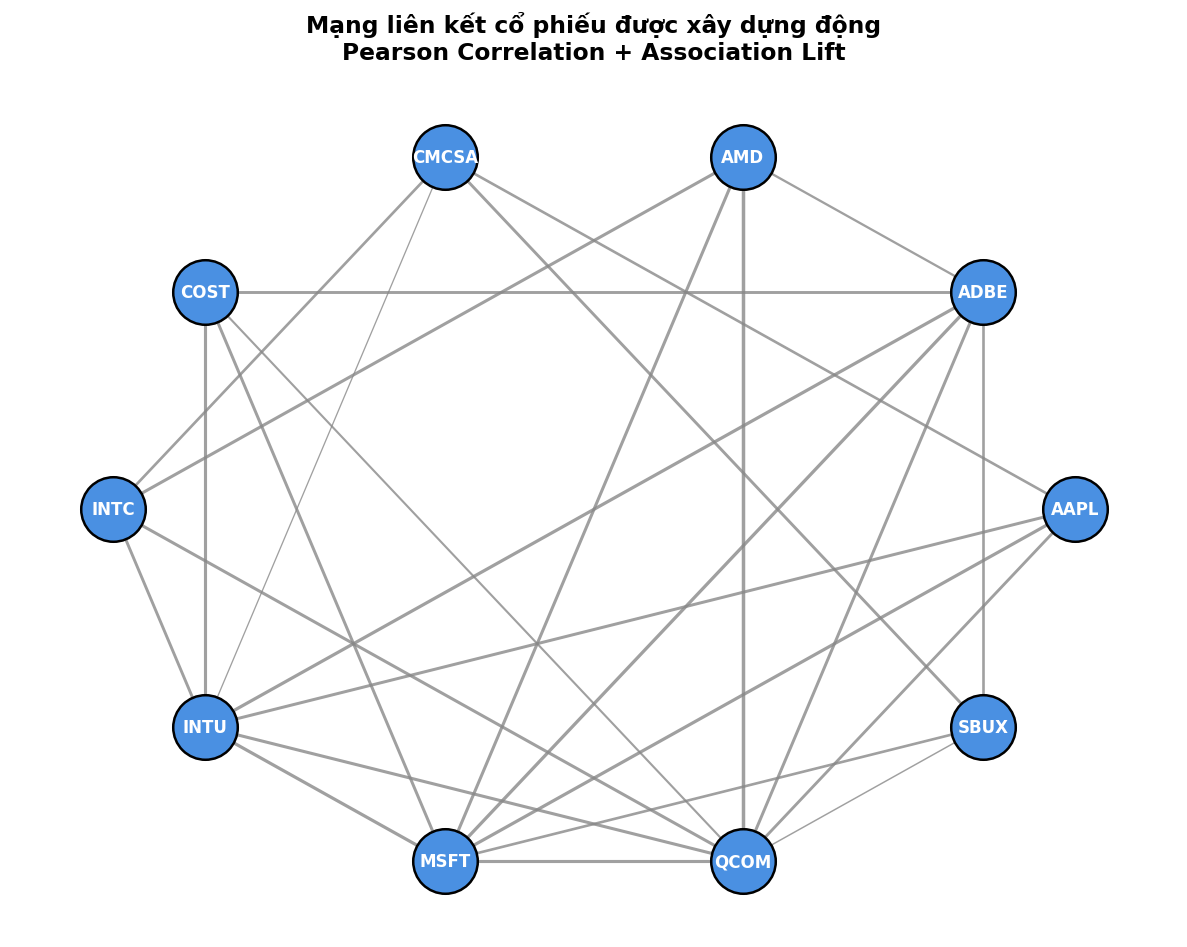

In [13]:
# CELL 11B - Trực quan hóa mạng lưới cổ phiếu (Stock Network Graph)
# Mục tiêu: Trực quan hóa cấu trúc đồ thị liên kết giữa các cổ phiếu dựa trên sự kết hợp giữa
# tương quan Pearson và luật kết hợp Association Rules tại bước test đầu tiên.

import networkx as nx

# Lấy dữ liệu đồ thị tại bước test đầu tiên
first_test_t = len(dates) - EXP_TEST_DAYS
train_start_t = max(0, first_test_t - EXP_INITIAL_TRAIN_DAYS)
train_end_t = first_test_t - 1

_, adj_raw, _, _ = build_combined_graph_from_train_window(
    return_2d=return_2d,
    tickers=TICKERS,
    train_start_t=train_start_t,
    train_end_t=train_end_t
)

# Khởi tạo đồ thị NetworkX
G = nx.Graph()
for t in TICKERS:
    G.add_node(t)

for i in range(len(TICKERS)):
    for j in range(i + 1, len(TICKERS)):
        weight = adj_raw[i, j]
        if weight > 0:
            G.add_edge(TICKERS[i], TICKERS[j], weight=weight)

print("Số node:", G.number_of_nodes())
print("Số cạnh:", G.number_of_edges())

if G.number_of_edges() == 0:
    print("CẢNH BÁO: Graph đang không có cạnh. Cần giảm threshold hoặc dùng top-k correlation.")

plt.figure(figsize=(10, 8))
pos = nx.circular_layout(G)  # Vẽ dạng vòng tròn để dễ quan sát liên kết chéo

# Cạnh có trọng số lớn hơn sẽ đậm hơn
edges = G.edges(data=True)
weights = [d['weight'] * 4 for u, v, d in edges]

# Vẽ các thành phần của đồ thị
nx.draw_networkx_nodes(G, pos, node_color='#4A90E2', node_size=1500, edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='white')
nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, edge_color='#888888', alpha=0.8)

plt.title(
    "Mạng liên kết cổ phiếu được xây dựng động\nPearson Correlation + Association Lift",
    fontsize=14,
    fontweight="bold",
    pad=15
)
plt.axis('off')
plt.tight_layout()
plt.show()

In [14]:
# CELL 12 - Tạo sample cho expanding-window
# Mục tiêu: tạo train/validation/test pack cho từng ngày test trong giai đoạn expanding-window.
# Mỗi ngày test chỉ dùng dữ liệu trước ngày đó để tạo sequence và graph.
def build_samples_for_target_range(close_only_3d, full_node_3d, adj_norm,
                                   start_t, end_t, lookback, date_index=None):
    if date_index is None:
        date_index = dates
    X_seq_list = []
    X_node_list = []
    A_list = []
    y_res_list = []
    y_close_list = []
    last_close_list = []
    date_list = []
    for t in range(start_t, end_t + 1):
        if t - lookback < 0:
            continue
        seq = close_only_3d[t - lookback:t, :, :]
        seq = np.transpose(seq, (1, 0, 2))
        node_x = full_node_3d[t - 1, :, :]
        target_close = full_node_3d[t, :, TARGET_IDX]
        last_close = full_node_3d[t - 1, :, TARGET_IDX]
        target_res = target_close - last_close
        X_seq_list.append(seq.astype(np.float32))
        X_node_list.append(node_x.astype(np.float32))
        A_list.append(adj_norm.astype(np.float32))
        y_res_list.append(target_res.astype(np.float32))
        y_close_list.append(target_close.astype(np.float32))
        last_close_list.append(last_close.astype(np.float32))
        date_list.append(date_index[t])
    X_seq = np.stack(X_seq_list)
    X_node = np.stack(X_node_list)
    A = np.stack(A_list)
    y_res = np.stack(y_res_list)
    y_close = np.stack(y_close_list)
    last_close = np.stack(last_close_list)
    date_list = np.array(date_list)
    return {
        "X_seq": X_seq,
        "X_node": X_node,
        "A": A,
        "y_res": y_res,
        "y_close": y_close,
        "last_close": last_close,
        "dates": date_list
    }
def prepare_expanding_step_data(
    test_t,
    lookback,
    val_days,
    first_test_t=None,
    close_only_3d=None,
    full_node_3d=None,
    return_matrix=None,
    date_index=None,
    sequence_feature_mode="close",
    node_feature_mode="all"
):
    if date_index is None:
        date_index = dates
    if return_matrix is None:
        return_matrix = return_2d
    if first_test_t is None:
        first_test_t = len(date_index) - EXP_TEST_DAYS
    # Sử dụng features_3d thô toàn cục đã tính từ CELL 3
    raw_features_3d = features_3d
    T, N, F = raw_features_3d.shape
    train_start_t = max(0, first_test_t - EXP_INITIAL_TRAIN_DAYS)
    train_end_t = test_t - 1
    # Fit MinMaxScaler động trên từng expanding train window [train_start_t : train_end_t]
    # Giải quyết triệt để lỗi giá năm 2025-2026 vượt ra ngoài range huấn luyện của quá khứ
    step_scaled = np.zeros_like(raw_features_3d, dtype=np.float32)
    close_mins = np.zeros(N, dtype=np.float32)
    close_maxs = np.zeros(N, dtype=np.float32)
    for j in range(N):
        scaler = MinMaxScaler()
        scaler.fit(raw_features_3d[train_start_t:train_end_t + 1, j, :])
        step_scaled[:, j, :] = scaler.transform(raw_features_3d[:, j, :]).astype(np.float32)
        close_mins[j] = float(scaler.data_min_[TARGET_IDX])
        close_maxs[j] = float(scaler.data_max_[TARGET_IDX])
    step_full_node_3d = step_scaled.copy()
    if sequence_feature_mode == "all":
        step_sequence_3d = step_full_node_3d.copy()
    elif sequence_feature_mode == "base":
        step_sequence_3d = step_full_node_3d[:, :, :len(BASE_FEATURE_COLS)].copy()
    else:
        step_sequence_3d = step_scaled[:, :, TARGET_IDX:TARGET_IDX+1].copy()
    if node_feature_mode == "base":
        step_node_3d = step_full_node_3d[:, :, :len(BASE_FEATURE_COLS)].copy()
    else:
        step_node_3d = step_full_node_3d.copy()
    adj_norm, adj_raw, corr_raw, graph_debug = build_combined_graph_from_train_window(
        return_2d=return_matrix,
        tickers=TICKERS,
        train_start_t=train_start_t,
        train_end_t=train_end_t
    )
    sample_start_t = max(train_start_t + lookback, lookback)
    all_trainval = build_samples_for_target_range(
        close_only_3d=step_sequence_3d,
        full_node_3d=step_node_3d,
        adj_norm=adj_norm,
        start_t=sample_start_t,
        end_t=train_end_t,
        lookback=lookback,
        date_index=date_index
    )
    n_total = len(all_trainval["y_close"])
    if n_total <= val_days:
        raise ValueError("Không đủ train samples để tách validation.")
    split_idx = n_total - val_days
    train_pack = {
        k: v[:split_idx] if isinstance(v, np.ndarray) else v
        for k, v in all_trainval.items()
    }
    val_pack = {
        k: v[split_idx:] if isinstance(v, np.ndarray) else v
        for k, v in all_trainval.items()
    }
    test_pack = build_samples_for_target_range(
        close_only_3d=step_sequence_3d,
        full_node_3d=step_node_3d,
        adj_norm=adj_norm,
        start_t=test_t,
        end_t=test_t,
        lookback=lookback,
        date_index=date_index
    )
    meta = {
        "test_t": test_t,
        "test_date": date_index[test_t],
        "train_start_t": train_start_t,
        "train_end_t": train_end_t,
        "adj_norm": adj_norm,
        "adj_raw": adj_raw,
        "corr_raw": corr_raw,
        "graph_debug": graph_debug,
        "close_mins": close_mins,
        "close_maxs": close_maxs
    }
    return train_pack, val_pack, test_pack, meta
def pack_to_dataset(pack):
    return StockGraphDataset(
        X_seq=pack["X_seq"],
        X_node=pack["X_node"],
        A=pack["A"],
        y_res=pack["y_res"],
        y_close=pack["y_close"],
        last_close=pack["last_close"]
    )


In [15]:
# CELL 13 - Hai biến thể Hybrid LSTM-GNN: No-Gate và Graph-Gate
# Mục tiêu: so sánh hybrid dùng graph trực tiếp với hybrid có gate điều tiết đóng góp của graph.
# No-Gate dùng toàn bộ correction từ GNN; Graph-Gate học mức nên tin vào phần graph ở từng thời điểm.

class HybridLSTMGNNNoGate(nn.Module):
    def __init__(self, seq_input_dim, node_input_dim,
                 lstm_hidden=64, gnn_hidden=32, mlp_hidden=64, dropout=0.2,
                 graph_residual_scale=0.25,
                 direction_loss_weight=0.0,
                 direction_logit_scale=50.0):
        super().__init__()

        self.graph_residual_scale = graph_residual_scale
        self.direction_loss_weight = direction_loss_weight
        self.direction_logit_scale = direction_logit_scale

        self.lstm = nn.LSTM(
            input_size=seq_input_dim,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True
        )

        self.lstm_head = nn.Linear(lstm_hidden, 1)

        self.node_proj = nn.Linear(node_input_dim, gnn_hidden)
        self.gcn1 = SimpleGCNLayer(gnn_hidden, gnn_hidden)
        self.gcn2 = SimpleGCNLayer(gnn_hidden, gnn_hidden)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.graph_head = nn.Sequential(
            nn.Linear(lstm_hidden + gnn_hidden, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1)
        )
        nn.init.zeros_(self.graph_head[-1].weight)
        nn.init.zeros_(self.graph_head[-1].bias)

    def forward(self, seq, node_x, adj, last_close, return_gate=False):
        B, N, T, F = seq.shape

        seq_flat = seq.reshape(B * N, T, F)
        lstm_out, _ = self.lstm(seq_flat)
        h = lstm_out[:, -1, :].reshape(B, N, -1)
        h = self.dropout(h)

        lstm_res = self.lstm_head(h).squeeze(-1)

        g = self.node_proj(node_x)
        g = self.gcn1(g, adj)
        g = self.relu(g)
        g = self.dropout(g)

        g = self.gcn2(g, adj)
        g = self.relu(g)
        g = self.dropout(g)

        fusion = torch.cat([h, g], dim=-1)
        graph_res = self.graph_head(fusion).squeeze(-1)

        pred_res = lstm_res + self.graph_residual_scale * graph_res
        pred_close = last_close + pred_res

        if return_gate:
            no_gate_marker = torch.ones(B, N, device=g.device, dtype=g.dtype)
            return pred_close, no_gate_marker

        return pred_close


class HybridLSTMGNNGraphGate(nn.Module):
    def __init__(self, seq_input_dim, node_input_dim,
                 lstm_hidden=64, gnn_hidden=32, mlp_hidden=64, dropout=0.2,
                 graph_residual_scale=0.25,
                 direction_loss_weight=0.0,
                 direction_logit_scale=50.0,
                 gate_delta_scale=0.50):
        super().__init__()

        self.graph_residual_scale = graph_residual_scale
        self.direction_loss_weight = direction_loss_weight
        self.direction_logit_scale = direction_logit_scale
        self.gate_delta_scale = gate_delta_scale

        self.lstm = nn.LSTM(
            input_size=seq_input_dim,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True
        )

        self.lstm_head = nn.Linear(lstm_hidden, 1)

        self.node_proj = nn.Linear(node_input_dim, gnn_hidden)
        self.gcn1 = SimpleGCNLayer(gnn_hidden, gnn_hidden)
        self.gcn2 = SimpleGCNLayer(gnn_hidden, gnn_hidden)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.gate_layer = nn.Linear(lstm_hidden + gnn_hidden, 1)
        nn.init.zeros_(self.gate_layer.weight)
        nn.init.zeros_(self.gate_layer.bias)

        self.graph_head = nn.Sequential(
            nn.Linear(lstm_hidden + gnn_hidden, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1)
        )
        nn.init.zeros_(self.graph_head[-1].weight)
        nn.init.zeros_(self.graph_head[-1].bias)

    def forward(self, seq, node_x, adj, last_close, return_gate=False):
        B, N, T, F = seq.shape

        seq_flat = seq.reshape(B * N, T, F)
        lstm_out, _ = self.lstm(seq_flat)
        h = lstm_out[:, -1, :].reshape(B, N, -1)
        h = self.dropout(h)

        lstm_res = self.lstm_head(h).squeeze(-1)

        g = self.node_proj(node_x)
        g = self.gcn1(g, adj)
        g = self.relu(g)
        g = self.dropout(g)

        g = self.gcn2(g, adj)
        g = self.relu(g)
        g = self.dropout(g)

        fusion = torch.cat([h, g], dim=-1)
        graph_res = self.graph_head(fusion).squeeze(-1)

        # Output gate is centered at 1.0, so the initial Graph-Gate model
        # exactly matches No-Gate after copying No-Gate weights.
        gate_delta = torch.tanh(self.gate_layer(fusion)).squeeze(-1)
        gate = 1.0 + self.gate_delta_scale * gate_delta

        pred_res = lstm_res + self.graph_residual_scale * gate * graph_res
        pred_close = last_close + pred_res

        if return_gate:
            return pred_close, gate

        return pred_close


def initialize_hybrid_from_lstm_model(hybrid_model, lstm_model):
    """Use the trained LSTM baseline as the hybrid temporal backbone."""
    hybrid_model.lstm.load_state_dict(copy.deepcopy(lstm_model.lstm.state_dict()))
    hybrid_model.lstm_head.load_state_dict(copy.deepcopy(lstm_model.fc.state_dict()))
    return hybrid_model


def initialize_graph_gate_from_no_gate_model(graph_gate_model, no_gate_model):
    """Start Graph-Gate from the trained No-Gate model, then learn gate adjustments."""
    graph_gate_model.lstm.load_state_dict(copy.deepcopy(no_gate_model.lstm.state_dict()))
    graph_gate_model.lstm_head.load_state_dict(copy.deepcopy(no_gate_model.lstm_head.state_dict()))
    graph_gate_model.node_proj.load_state_dict(copy.deepcopy(no_gate_model.node_proj.state_dict()))
    graph_gate_model.gcn1.load_state_dict(copy.deepcopy(no_gate_model.gcn1.state_dict()))
    graph_gate_model.gcn2.load_state_dict(copy.deepcopy(no_gate_model.gcn2.state_dict()))
    graph_gate_model.graph_head.load_state_dict(copy.deepcopy(no_gate_model.graph_head.state_dict()))
    return graph_gate_model


@torch.no_grad()
def predict_model_with_gate(model, loader, device):
    model.eval()

    preds = []
    trues = []
    lasts = []
    gates = []

    for batch in loader:
        if len(batch) == 6:
            seq, node_x, adj, _, y_close, last_close = batch
        elif len(batch) == 5:
            seq, node_x, adj, y_close, last_close = batch
        else:
            raise ValueError("Unexpected batch format in predict_model_with_gate.")

        seq = seq.to(device)
        node_x = node_x.to(device)
        adj = adj.to(device)
        last_close_device = last_close.to(device)

        pred_close, gate = model(seq, node_x, adj, last_close_device, return_gate=True)

        preds.append(pred_close.cpu().numpy())
        trues.append(y_close.numpy())
        lasts.append(last_close.numpy())
        gates.append(gate.cpu().numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)
    lasts = np.concatenate(lasts, axis=0)
    gates = np.concatenate(gates, axis=0)

    return preds, trues, lasts, gates


# Backward-compatible alias for older cells, if any.
predict_model_graph_gate = predict_model_with_gate


class TSNAttentionGraphGatedLSTMGNN(nn.Module):
    def __init__(self, seq_input_dim, node_input_dim,
                 lstm_hidden=64, gnn_hidden=32, mlp_hidden=64, dropout=0.2,
                 graph_residual_scale=0.25,
                 direction_loss_weight=0.0,
                 direction_logit_scale=50.0,
                 gate_delta_scale=0.50):
        super().__init__()

        self.graph_residual_scale = graph_residual_scale
        self.direction_loss_weight = direction_loss_weight
        self.direction_logit_scale = direction_logit_scale
        self.gate_delta_scale = gate_delta_scale

        self.lstm = nn.LSTM(
            input_size=seq_input_dim,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True
        )

        self.temporal_attention = TemporalAttention(lstm_hidden)

        self.lstm_head = nn.Linear(lstm_hidden, 1)

        self.node_proj = nn.Linear(node_input_dim, gnn_hidden)
        self.gcn1 = SimpleGCNLayer(gnn_hidden, gnn_hidden)
        self.gcn2 = SimpleGCNLayer(gnn_hidden, gnn_hidden)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.gate_layer = nn.Linear(lstm_hidden + gnn_hidden, 1)
        nn.init.zeros_(self.gate_layer.weight)
        nn.init.zeros_(self.gate_layer.bias)

        self.graph_head = nn.Sequential(
            nn.Linear(lstm_hidden + gnn_hidden, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1)
        )
        nn.init.zeros_(self.graph_head[-1].weight)
        nn.init.zeros_(self.graph_head[-1].bias)

    def forward(self, seq, node_x, adj, last_close, return_gate=False, return_attention=False):
        B, N, T, F = seq.shape

        seq_flat = seq.reshape(B * N, T, F)
        lstm_out, _ = self.lstm(seq_flat)
        h, attn_weights = self.temporal_attention(lstm_out)
        h = h.reshape(B, N, -1)
        attn_weights = attn_weights.reshape(B, N, T)
        h = self.dropout(h)

        lstm_res = self.lstm_head(h).squeeze(-1)

        g = self.node_proj(node_x)
        g = self.gcn1(g, adj)
        g = self.relu(g)
        g = self.dropout(g)

        g = self.gcn2(g, adj)
        g = self.relu(g)
        g = self.dropout(g)

        fusion = torch.cat([h, g], dim=-1)
        graph_res = self.graph_head(fusion).squeeze(-1)

        gate_delta = torch.tanh(self.gate_layer(fusion)).squeeze(-1)
        gate = 1.0 + self.gate_delta_scale * gate_delta

        pred_res = lstm_res + self.graph_residual_scale * gate * graph_res
        pred_close = last_close + pred_res

        if return_attention:
            return pred_close, gate, attn_weights
        if return_gate:
            return pred_close, gate
        return pred_close


def initialize_tsn_from_graph_gate_model(tsn_model, graph_gate_model):
    tsn_model.lstm.load_state_dict(copy.deepcopy(graph_gate_model.lstm.state_dict()))
    tsn_model.lstm_head.load_state_dict(copy.deepcopy(graph_gate_model.lstm_head.state_dict()))
    tsn_model.node_proj.load_state_dict(copy.deepcopy(graph_gate_model.node_proj.state_dict()))
    tsn_model.gcn1.load_state_dict(copy.deepcopy(graph_gate_model.gcn1.state_dict()))
    tsn_model.gcn2.load_state_dict(copy.deepcopy(graph_gate_model.gcn2.state_dict()))
    tsn_model.graph_head.load_state_dict(copy.deepcopy(graph_gate_model.graph_head.state_dict()))
    tsn_model.gate_layer.load_state_dict(copy.deepcopy(graph_gate_model.gate_layer.state_dict()))
    return tsn_model


@torch.no_grad()
def predict_model_with_attention(model, loader, device):
    model.eval()

    preds = []
    trues = []
    lasts = []
    gates = []
    attns = []

    for batch in loader:
        if len(batch) == 6:
            seq, node_x, adj, _, y_close, last_close = batch
        elif len(batch) == 5:
            seq, node_x, adj, y_close, last_close = batch
        else:
            raise ValueError("Unexpected batch format in predict_model_with_attention.")

        seq = seq.to(device)
        node_x = node_x.to(device)
        adj = adj.to(device)
        last_close_device = last_close.to(device)

        pred_close, gate, attn_weights = model(seq, node_x, adj, last_close_device, return_attention=True)

        preds.append(pred_close.cpu().numpy())
        trues.append(y_close.numpy())
        lasts.append(last_close.numpy())
        gates.append(gate.cpu().numpy())
        attns.append(attn_weights.cpu().numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)
    lasts = np.concatenate(lasts, axis=0)
    gates = np.concatenate(gates, axis=0)
    attns = np.concatenate(attns, axis=0)

    return preds, trues, lasts, gates, attns



In [16]:
# CELL 14 - Linear Regression baseline
# Mục tiêu: huấn luyện Ridge Linear Regression riêng cho từng mã và chọn alpha bằng validation.
# Linear là baseline cổ điển, dễ giải thích và không dùng deep learning.

def _fit_ridge_for_one_stock(X_train, y_train, X_val, y_val, alphas):
    best_model = None
    best_val = float("inf")

    for alpha in alphas:
        model = Ridge(alpha=alpha)
        model.fit(X_train, y_train)
        pred_val = model.predict(X_val)
        val_mse = mean_squared_error(y_val, pred_val)

        if val_mse < best_val:
            best_val = val_mse
            best_model = model

    return best_model


def run_expanding_linear_backtest(
    test_indices=None,
    first_test_t=None,
    close_only_3d=None,
    full_node_3d=None,
    return_matrix=None,
    date_index=None,
    log_prefix="[Linear]"
):
    if date_index is None:
        date_index = dates
    if return_matrix is None:
        return_matrix = return_2d
    T = len(date_index)
    if test_indices is None:
        first_test_t = T - EXP_TEST_DAYS
        test_indices = range(first_test_t, T)
    else:
        test_indices = list(test_indices)
        if first_test_t is None:
            first_test_t = int(test_indices[0])

    test_count = len(test_indices)
    preds_all = []
    trues_all = []
    lasts_all = []
    preds_scaled_all = []
    trues_scaled_all = []
    lasts_scaled_all = []
    step_rows = []

    for step, test_t in enumerate(test_indices, start=1):
        train_pack, val_pack, test_pack, meta = prepare_expanding_step_data(
            test_t=test_t,
            lookback=LOOKBACK,
            val_days=EXP_VAL_DAYS,
            first_test_t=first_test_t,
            close_only_3d=close_only_3d,
            full_node_3d=full_node_3d,
            return_matrix=return_matrix,
            date_index=date_index
        )

        X_train_seq = train_pack["X_seq"]
        y_train_res = train_pack["y_res"]
        X_val_seq = val_pack["X_seq"]
        y_val_res = val_pack["y_res"]
        X_test_seq = test_pack["X_seq"]
        y_test_close = test_pack["y_close"]
        last_close = test_pack["last_close"]

        n_test = X_test_seq.shape[0]
        pred_res = np.zeros((n_test, len(TICKERS)), dtype=np.float32)

        for j in range(len(TICKERS)):
            X_train_j = X_train_seq[:, j, :, :].reshape(X_train_seq.shape[0], -1)
            y_train_j = y_train_res[:, j]
            X_val_j = X_val_seq[:, j, :, :].reshape(X_val_seq.shape[0], -1)
            y_val_j = y_val_res[:, j]
            X_test_j = X_test_seq[:, j, :, :].reshape(n_test, -1)

            lin_model = _fit_ridge_for_one_stock(
                X_train=X_train_j,
                y_train=y_train_j,
                X_val=X_val_j,
                y_val=y_val_j,
                alphas=EXP_LINEAR_RIDGE_ALPHAS
            )
            pred_res[:, j] = lin_model.predict(X_test_j).astype(np.float32)

        pred_close = last_close + pred_res

        # Thu thap scaled closes
        preds_scaled_all.append(pred_close)
        trues_scaled_all.append(y_test_close)
        lasts_scaled_all.append(last_close)
        
        # Thực hiện inverse scaling động ngay tại từng bước dựa trên min-max thực tế
        close_mins = meta["close_mins"]
        close_maxs = meta["close_maxs"]
        pred_close_real = pred_close * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        y_test_close_real = y_test_close * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        last_close_real = last_close * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        
        day_mse = mean_squared_error(y_test_close_real.reshape(-1), pred_close_real.reshape(-1))

        preds_all.append(pred_close_real)
        trues_all.append(y_test_close_real)
        lasts_all.append(last_close_real)

        step_rows.append({
            "Step": step,
            "Date": meta["test_date"],
            "Day_MSE": day_mse
        })

        if step % 10 == 0 or step == 1 or step == test_count:
            print(f"{log_prefix} Step {step:02d}/{test_count} | Date={meta['test_date'].date()} | Day_MSE={day_mse:.6f}")

    preds_all = np.concatenate(preds_all, axis=0)
    trues_all = np.concatenate(trues_all, axis=0)
    lasts_all = np.concatenate(lasts_all, axis=0)

    preds_scaled_all = np.concatenate(preds_scaled_all, axis=0)
    trues_scaled_all = np.concatenate(trues_scaled_all, axis=0)
    lasts_scaled_all = np.concatenate(lasts_scaled_all, axis=0)

    scaled_metrics = compute_full_evaluation(trues_scaled_all, preds_scaled_all, lasts_scaled_all, tickers=TICKERS, direction_eps=DIRECTION_EPS)
    metrics = compute_full_evaluation(trues_all, preds_all, lasts_all, tickers=TICKERS, direction_eps=DIRECTION_EPS)
    step_df = pd.DataFrame(step_rows)

    return metrics, scaled_metrics, step_df, preds_all, trues_all, lasts_all

In [17]:
# CELL 15 - Chạy backtest cho LSTM và hai mô hình Hybrid
# Mục tiêu: chạy expanding-window cho LSTM, Hybrid No-Gate và Hybrid Graph-Gate trong cùng protocol.
# Các mô hình được train và đánh giá trên cùng ngày test để so sánh công bằng.
def _append_gate_stats(rows, step, date, model_name, gate_values):
    rows.append({
        "Step": step,
        "Date": date,
        "Model": model_name,
        "Gate_Mean": float(gate_values.mean()),
        "Gate_Min": float(gate_values.min()),
        "Gate_Max": float(gate_values.max()),
        "Gate_STD": float(gate_values.std())
    })
def _append_step_result(pred_list, true_list, last_list, rows, step, date, pred_close, true_close, last_close):
    day_mse = mean_squared_error(true_close.reshape(-1), pred_close.reshape(-1))
    pred_list.append(pred_close)
    true_list.append(true_close)
    last_list.append(last_close)
    rows.append({"Step": step, "Date": date, "Day_MSE": day_mse})
    return day_mse
def run_joint_expanding_lstm_hybrid_backtest(
    test_indices=None,
    first_test_t=None,
    close_only_3d=None,
    full_node_3d=None,
    return_matrix=None,
    date_index=None,
    log_prefix="",
    calibrate_graph_gate=False
):
    if date_index is None:
        date_index = dates
    if return_matrix is None:
        return_matrix = return_2d
    T = len(date_index)
    if test_indices is None:
        first_test_t = T - EXP_TEST_DAYS
        test_indices = range(first_test_t, T)
    else:
        test_indices = list(test_indices)
        if first_test_t is None:
            first_test_t = int(test_indices[0])
    test_count = len(test_indices)
    lstm_preds_all, lstm_trues_all, lstm_lasts_all = [], [], []
    no_gate_preds_all, no_gate_trues_all, no_gate_lasts_all = [], [], []
    graph_gate_preds_all, graph_gate_trues_all, graph_gate_lasts_all = [], [], []
    lstm_preds_scaled_all, lstm_trues_scaled_all, lstm_lasts_scaled_all = [], [], []
    no_gate_preds_scaled_all, no_gate_trues_scaled_all, no_gate_lasts_scaled_all = [], [], []
    graph_gate_preds_scaled_all, graph_gate_trues_scaled_all, graph_gate_lasts_scaled_all = [], [], []
    lstm_rows = []
    no_gate_rows = []
    graph_gate_rows = []
    graph_rows = []
    gate_rows = []
    saved_lstm_state = None
    saved_no_gate_state = None
    saved_graph_gate_state = None
    for step, test_t in enumerate(test_indices, start=1):
        train_pack, val_pack, test_pack, meta = prepare_expanding_step_data(
            test_t=test_t,
            lookback=LOOKBACK,
            val_days=EXP_VAL_DAYS,
            first_test_t=first_test_t,
            close_only_3d=close_only_3d,
            full_node_3d=full_node_3d,
            return_matrix=return_matrix,
            date_index=date_index,
            sequence_feature_mode="close",
            node_feature_mode="base"
        )
        close_mins = meta["close_mins"]
        close_maxs = meta["close_maxs"]
        train_ds = pack_to_dataset(train_pack)
        val_ds = pack_to_dataset(val_pack)
        test_ds = pack_to_dataset(test_pack)
        train_loader = DataLoader(train_ds, batch_size=EXP_BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=EXP_BATCH_SIZE, shuffle=False, num_workers=0)
        test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)
        current_epochs = EXP_INIT_EPOCHS if step == 1 else EXP_UPDATE_EPOCHS
        lstm_model = LSTMOnlyModel(
            input_dim=1,
            lstm_hidden=LSTM_HIDDEN,
            dropout=DROPOUT
        ).to(DEVICE)
        if EXP_WARM_START and saved_lstm_state is not None:
            lstm_model.load_state_dict(saved_lstm_state)
        lstm_model, _ = fit_model_silent(
            model=lstm_model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=current_epochs,
            lr=EXP_LR_LSTM,
            patience=EXP_PATIENCE,
            device=DEVICE,
            verbose=False
        )
        if EXP_WARM_START:
            saved_lstm_state = copy.deepcopy(lstm_model.state_dict())
        lstm_pred_close, lstm_true_close, lstm_last_close = predict_model(lstm_model, test_loader, DEVICE)
        # Thu thap scaled
        lstm_preds_scaled_all.append(lstm_pred_close)
        lstm_trues_scaled_all.append(lstm_true_close)
        lstm_lasts_scaled_all.append(lstm_last_close)
        
        # Inverse scaling động
        lstm_pred_real = lstm_pred_close * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        lstm_true_real = lstm_true_close * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        lstm_last_real = lstm_last_close * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        lstm_day_mse = _append_step_result(
            lstm_preds_all, lstm_trues_all, lstm_lasts_all,
            lstm_rows, step, meta["test_date"], lstm_pred_real, lstm_true_real, lstm_last_real
        )
        # Tinh toan volatility dong dua tren ty suat sinh loi 20 ngay gan nhat
        recent_returns = return_matrix[test_t - EXP_SWITCH_VOLATILITY_WINDOW : test_t, :]
        mean_vol = float(recent_returns.std(axis=0).mean())
        
        # Ap dung switch phong thu: neu thi truong bien dong qua manh, ha ty le dong gop cua GNN
        step_residual_scale = EXP_GRAPH_RESIDUAL_SCALE
        if mean_vol > EXP_SWITCH_VOLATILITY_THRESHOLD:
            step_residual_scale = 0.05
            if step == 1 or step % 10 == 0:
                print(f"[Volatility Switch Alert] High stress volatility detected ({mean_vol:.4f} > {EXP_SWITCH_VOLATILITY_THRESHOLD}). Scaling GNN influence to 0.05 to protect portfolio.")
        no_gate_model = HybridLSTMGNNNoGate(
            seq_input_dim=1,
            node_input_dim=len(BASE_FEATURE_COLS),
            lstm_hidden=LSTM_HIDDEN,
            gnn_hidden=GNN_HIDDEN,
            mlp_hidden=MLP_HIDDEN,
            dropout=DROPOUT,
            graph_residual_scale=step_residual_scale,
            direction_loss_weight=EXP_HYBRID_DIRECTION_LOSS_WEIGHT,
            direction_logit_scale=EXP_DIRECTION_LOGIT_SCALE
        ).to(DEVICE)
        if EXP_WARM_START and saved_no_gate_state is not None:
            no_gate_model.load_state_dict(saved_no_gate_state)
        if EXP_INIT_HYBRID_FROM_LSTM:
            no_gate_model = initialize_hybrid_from_lstm_model(no_gate_model, lstm_model)
        no_gate_model, _ = fit_model_silent(
            model=no_gate_model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=current_epochs,
            lr=EXP_LR_HYBRID,
            patience=EXP_PATIENCE,
            device=DEVICE,
            verbose=False
        )
        if EXP_WARM_START:
            saved_no_gate_state = copy.deepcopy(no_gate_model.state_dict())
        no_gate_pred_close, no_gate_true_close, no_gate_last_close, no_gate_marker = predict_model_with_gate(
            no_gate_model, test_loader, DEVICE
        )
        # Thu thap scaled
        no_gate_preds_scaled_all.append(no_gate_pred_close)
        no_gate_trues_scaled_all.append(no_gate_true_close)
        no_gate_lasts_scaled_all.append(no_gate_last_close)
        # Inverse scaling động
        no_gate_pred_real = no_gate_pred_close * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        no_gate_true_real = no_gate_true_close * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        no_gate_last_real = no_gate_last_close * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        no_gate_day_mse = _append_step_result(
            no_gate_preds_all, no_gate_trues_all, no_gate_lasts_all,
            no_gate_rows, step, meta["test_date"], no_gate_pred_real, no_gate_true_real, no_gate_last_real
        )
        _append_gate_stats(gate_rows, step, meta["test_date"], "Hybrid LSTM-GNN No-Gate", no_gate_marker)
        graph_gate_model = HybridLSTMGNNGraphGate(
            seq_input_dim=1,
            node_input_dim=len(BASE_FEATURE_COLS),
            lstm_hidden=LSTM_HIDDEN,
            gnn_hidden=GNN_HIDDEN,
            mlp_hidden=MLP_HIDDEN,
            dropout=DROPOUT,
            graph_residual_scale=step_residual_scale,
            direction_loss_weight=EXP_HYBRID_DIRECTION_LOSS_WEIGHT,
            direction_logit_scale=EXP_DIRECTION_LOGIT_SCALE,
            gate_delta_scale=EXP_GRAPH_GATE_DELTA_SCALE
        ).to(DEVICE)
        if EXP_WARM_START and saved_graph_gate_state is not None:
            graph_gate_model.load_state_dict(saved_graph_gate_state)
        if EXP_INIT_GRAPH_GATE_FROM_NO_GATE:
            graph_gate_model = initialize_graph_gate_from_no_gate_model(graph_gate_model, no_gate_model)
        elif EXP_INIT_HYBRID_FROM_LSTM:
            graph_gate_model = initialize_hybrid_from_lstm_model(graph_gate_model, lstm_model)
        graph_gate_model, _ = fit_model_silent(
            model=graph_gate_model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=current_epochs,
            lr=EXP_LR_HYBRID,
            patience=EXP_PATIENCE,
            device=DEVICE,
            verbose=False
        )
        if EXP_WARM_START:
            saved_graph_gate_state = copy.deepcopy(graph_gate_model.state_dict())
        graph_gate_raw_pred_close, graph_gate_true_close, graph_gate_last_close, graph_gate_values = predict_model_with_gate(
            graph_gate_model, test_loader, DEVICE
        )
        best_alpha = 1.0
        if calibrate_graph_gate:
            val_no_gate_pred, val_true, _, _ = predict_model_with_gate(no_gate_model, val_loader, DEVICE)
            val_graph_gate_pred, _, _, _ = predict_model_with_gate(graph_gate_model, val_loader, DEVICE)
            alpha_candidates = np.array([0.0, 0.25, 0.50, 0.75, 1.0], dtype=np.float32)
            alpha_mse = []
            for alpha in alpha_candidates:
                val_blend = (1.0 - alpha) * val_no_gate_pred + alpha * val_graph_gate_pred
                alpha_mse.append(mean_squared_error(val_true.reshape(-1), val_blend.reshape(-1)))
            best_alpha = float(alpha_candidates[int(np.argmin(alpha_mse))])
        graph_gate_pred_close = (1.0 - best_alpha) * no_gate_pred_close + best_alpha * graph_gate_raw_pred_close
        # Thu thap scaled
        graph_gate_preds_scaled_all.append(graph_gate_pred_close)
        graph_gate_trues_scaled_all.append(graph_gate_true_close)
        graph_gate_lasts_scaled_all.append(graph_gate_last_close)
        
        # Inverse scaling động
        graph_gate_pred_real = graph_gate_pred_close * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        graph_gate_true_real = graph_gate_true_close * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        graph_gate_last_real = graph_gate_last_close * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        graph_gate_day_mse = _append_step_result(
            graph_gate_preds_all, graph_gate_trues_all, graph_gate_lasts_all,
            graph_gate_rows, step, meta["test_date"], graph_gate_pred_real, graph_gate_true_real, graph_gate_last_real
        )
        gate_name = "Hybrid LSTM-GNN Graph-Gate Calibrated" if calibrate_graph_gate else "Hybrid LSTM-GNN Graph-Gate"
        _append_gate_stats(gate_rows, step, meta["test_date"], gate_name, graph_gate_values)
        graph_rows.append({
            "Step": step,
            "Date": meta["test_date"],
            "Pearson_Edges": meta["graph_debug"]["pearson_edges"],
            "Assoc_Edges": meta["graph_debug"]["assoc_edges"],
            "Combined_Edges": meta["graph_debug"]["combined_edges"]
        })
        if step % 10 == 0 or step == 1 or step == test_count:
            print(
                f"{log_prefix}Step {step:02d}/{test_count} | Date={meta['test_date'].date()} | "
                f"LSTM_MSE={lstm_day_mse:.6f} | "
                f"NoGate_MSE={no_gate_day_mse:.6f} | "
                f"GraphGate_MSE={graph_gate_day_mse:.6f} | "
                f"Alpha={best_alpha:.2f} | GateMean={graph_gate_values.mean():.3f}"
            )
    lstm_preds_all = np.concatenate(lstm_preds_all, axis=0)
    lstm_trues_all = np.concatenate(lstm_trues_all, axis=0)
    lstm_lasts_all = np.concatenate(lstm_lasts_all, axis=0)
    no_gate_preds_all = np.concatenate(no_gate_preds_all, axis=0)
    no_gate_trues_all = np.concatenate(no_gate_trues_all, axis=0)
    no_gate_lasts_all = np.concatenate(no_gate_lasts_all, axis=0)
    graph_gate_preds_all = np.concatenate(graph_gate_preds_all, axis=0)
    graph_gate_trues_all = np.concatenate(graph_gate_trues_all, axis=0)
    graph_gate_lasts_all = np.concatenate(graph_gate_lasts_all, axis=0)
    lstm_preds_scaled_all = np.concatenate(lstm_preds_scaled_all, axis=0)
    lstm_trues_scaled_all = np.concatenate(lstm_trues_scaled_all, axis=0)
    lstm_lasts_scaled_all = np.concatenate(lstm_lasts_scaled_all, axis=0)
    no_gate_preds_scaled_all = np.concatenate(no_gate_preds_scaled_all, axis=0)
    no_gate_trues_scaled_all = np.concatenate(no_gate_trues_scaled_all, axis=0)
    no_gate_lasts_scaled_all = np.concatenate(no_gate_lasts_scaled_all, axis=0)
    graph_gate_preds_scaled_all = np.concatenate(graph_gate_preds_scaled_all, axis=0)
    graph_gate_trues_scaled_all = np.concatenate(graph_gate_trues_scaled_all, axis=0)
    graph_gate_lasts_scaled_all = np.concatenate(graph_gate_lasts_scaled_all, axis=0)
    # Đánh giá toàn bộ chỉ số cho các mô hình
    lstm_metrics = compute_full_evaluation(lstm_trues_all, lstm_preds_all, lstm_lasts_all, tickers=TICKERS, direction_eps=DIRECTION_EPS)
    no_gate_metrics = compute_full_evaluation(no_gate_trues_all, no_gate_preds_all, no_gate_lasts_all, tickers=TICKERS, direction_eps=DIRECTION_EPS)
    graph_gate_metrics = compute_full_evaluation(graph_gate_trues_all, graph_gate_preds_all, graph_gate_lasts_all, tickers=TICKERS, direction_eps=DIRECTION_EPS)
    lstm_scaled_metrics = compute_full_evaluation(lstm_trues_scaled_all, lstm_preds_scaled_all, lstm_lasts_scaled_all, tickers=TICKERS, direction_eps=DIRECTION_EPS)
    no_gate_scaled_metrics = compute_full_evaluation(no_gate_trues_scaled_all, no_gate_preds_scaled_all, no_gate_lasts_scaled_all, tickers=TICKERS, direction_eps=DIRECTION_EPS)
    graph_gate_scaled_metrics = compute_full_evaluation(graph_gate_trues_scaled_all, graph_gate_preds_scaled_all, graph_gate_lasts_scaled_all, tickers=TICKERS, direction_eps=DIRECTION_EPS)
    return (
        lstm_metrics, lstm_scaled_metrics, pd.DataFrame(lstm_rows), lstm_preds_all, lstm_trues_all, lstm_lasts_all,
        no_gate_metrics, no_gate_scaled_metrics, pd.DataFrame(no_gate_rows), no_gate_preds_all, no_gate_trues_all, no_gate_lasts_all,
        graph_gate_metrics, graph_gate_scaled_metrics, pd.DataFrame(graph_gate_rows), graph_gate_preds_all, graph_gate_trues_all, graph_gate_lasts_all,
        pd.DataFrame(graph_rows), pd.DataFrame(gate_rows)
    )
def run_tsn_expanding_backtest(
    test_indices=None,
    first_test_t=None,
    close_only_3d=None,
    full_node_3d=None,
    return_matrix=None,
    date_index=None,
    log_prefix="[TSN]",
    num_base_features=None
):
    if date_index is None:
        date_index = dates
    if return_matrix is None:
        return_matrix = return_2d
    if num_base_features is None:
        num_base_features = len(BASE_FEATURE_COLS)
    T = len(date_index)
    if test_indices is None:
        first_test_t = T - EXP_TEST_DAYS
        test_indices = range(first_test_t, T)
    else:
        test_indices = list(test_indices)
        if first_test_t is None:
            first_test_t = int(test_indices[0])
    test_count = len(test_indices)
    num_all_features = len(FEATURE_COLS)
    gg_tsn_preds_all, gg_tsn_trues_all, gg_tsn_lasts_all = [], [], []
    tsn_attn_preds_all, tsn_attn_trues_all, tsn_attn_lasts_all = [], [], []
    gg_tsn_preds_scaled, gg_tsn_trues_scaled, gg_tsn_lasts_scaled = [], [], []
    tsn_attn_preds_scaled, tsn_attn_trues_scaled, tsn_attn_lasts_scaled = [], [], []
    gg_tsn_rows = []
    tsn_attn_rows = []
    tsn_gate_rows = []
    all_tsn_attn_weights = []
    all_tsn_gate_values = []
    all_tsn_dates = []
    saved_gg_tsn_state = None
    saved_tsn_attn_state = None
    for step, test_t in enumerate(test_indices, start=1):
        train_pack, val_pack, test_pack, meta = prepare_expanding_step_data(
            test_t=test_t,
            lookback=LOOKBACK,
            val_days=EXP_VAL_DAYS,
            first_test_t=first_test_t,
            close_only_3d=close_only_3d,
            full_node_3d=full_node_3d,
            return_matrix=return_matrix,
            date_index=date_index,
            sequence_feature_mode="all",
            node_feature_mode="all"
        )
        close_mins = meta["close_mins"]
        close_maxs = meta["close_maxs"]
        train_ds = pack_to_dataset(train_pack)
        val_ds = pack_to_dataset(val_pack)
        test_ds = pack_to_dataset(test_pack)
        train_loader = DataLoader(train_ds, batch_size=EXP_BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=EXP_BATCH_SIZE, shuffle=False, num_workers=0)
        test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)
        current_epochs = EXP_INIT_EPOCHS if step == 1 else EXP_UPDATE_EPOCHS
        recent_returns = return_matrix[test_t - EXP_SWITCH_VOLATILITY_WINDOW : test_t, :]
        mean_vol = float(recent_returns.std(axis=0).mean())
        step_residual_scale = EXP_GRAPH_RESIDUAL_SCALE
        if mean_vol > EXP_SWITCH_VOLATILITY_THRESHOLD:
            step_residual_scale = 0.05
        # --- Model 5: GraphGate + TSN features (full features) ---
        gg_tsn_model = HybridLSTMGNNGraphGate(
            seq_input_dim=num_all_features,
            node_input_dim=num_all_features,
            lstm_hidden=LSTM_HIDDEN,
            gnn_hidden=GNN_HIDDEN,
            mlp_hidden=MLP_HIDDEN,
            dropout=DROPOUT,
            graph_residual_scale=step_residual_scale,
            direction_loss_weight=EXP_HYBRID_DIRECTION_LOSS_WEIGHT,
            direction_logit_scale=EXP_DIRECTION_LOGIT_SCALE,
            gate_delta_scale=EXP_GRAPH_GATE_DELTA_SCALE
        ).to(DEVICE)
        if EXP_WARM_START and saved_gg_tsn_state is not None:
            gg_tsn_model.load_state_dict(saved_gg_tsn_state)
        gg_tsn_model, _ = fit_model_silent(
            model=gg_tsn_model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=current_epochs,
            lr=EXP_LR_HYBRID,
            patience=EXP_PATIENCE,
            device=DEVICE,
            verbose=False
        )
        if EXP_WARM_START:
            saved_gg_tsn_state = copy.deepcopy(gg_tsn_model.state_dict())
        gg_tsn_pred, gg_tsn_true, gg_tsn_last, _ = predict_model_with_gate(
            gg_tsn_model, test_loader, DEVICE
        )
        gg_tsn_preds_scaled.append(gg_tsn_pred)
        gg_tsn_trues_scaled.append(gg_tsn_true)
        gg_tsn_lasts_scaled.append(gg_tsn_last)
        gg_tsn_pred_real = gg_tsn_pred * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        gg_tsn_true_real = gg_tsn_true * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        gg_tsn_last_real = gg_tsn_last * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        _append_step_result(
            gg_tsn_preds_all, gg_tsn_trues_all, gg_tsn_lasts_all,
            gg_tsn_rows, step, meta["test_date"], gg_tsn_pred_real, gg_tsn_true_real, gg_tsn_last_real
        )
        # --- Model 6: TSNAttention + full features + noise ---
        tsn_attn_model = TSNAttentionGraphGatedLSTMGNN(
            seq_input_dim=num_all_features,
            node_input_dim=num_all_features,
            lstm_hidden=LSTM_HIDDEN,
            gnn_hidden=GNN_HIDDEN,
            mlp_hidden=MLP_HIDDEN,
            dropout=DROPOUT,
            graph_residual_scale=step_residual_scale,
            direction_loss_weight=EXP_HYBRID_DIRECTION_LOSS_WEIGHT,
            direction_logit_scale=EXP_DIRECTION_LOGIT_SCALE,
            gate_delta_scale=EXP_GRAPH_GATE_DELTA_SCALE
        ).to(DEVICE)
        if EXP_WARM_START and saved_tsn_attn_state is not None:
            tsn_attn_model.load_state_dict(saved_tsn_attn_state)
        else:
            tsn_attn_model = initialize_tsn_from_graph_gate_model(tsn_attn_model, gg_tsn_model)
        tsn_attn_model, _ = fit_model_silent(
            model=tsn_attn_model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=current_epochs,
            lr=EXP_LR_HYBRID,
            patience=EXP_PATIENCE,
            device=DEVICE,
            verbose=False,
            noise_std=EXP_GAUSSIAN_NOISE_STD
        )
        if EXP_WARM_START:
            saved_tsn_attn_state = copy.deepcopy(tsn_attn_model.state_dict())
        tsn_attn_pred, tsn_attn_true, tsn_attn_last, tsn_gate_vals, tsn_attn_wts = predict_model_with_attention(
            tsn_attn_model, test_loader, DEVICE
        )
        tsn_attn_preds_scaled.append(tsn_attn_pred)
        tsn_attn_trues_scaled.append(tsn_attn_true)
        tsn_attn_lasts_scaled.append(tsn_attn_last)
        tsn_attn_pred_real = tsn_attn_pred * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        tsn_attn_true_real = tsn_attn_true * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        tsn_attn_last_real = tsn_attn_last * (close_maxs - close_mins)[None, :] + close_mins[None, :]
        _append_step_result(
            tsn_attn_preds_all, tsn_attn_trues_all, tsn_attn_lasts_all,
            tsn_attn_rows, step, meta["test_date"], tsn_attn_pred_real, tsn_attn_true_real, tsn_attn_last_real
        )
        all_tsn_attn_weights.append(tsn_attn_wts)
        all_tsn_gate_values.append(tsn_gate_vals)
        all_tsn_dates.append(meta["test_date"])
        _append_gate_stats(tsn_gate_rows, step, meta["test_date"], "TSN-Attention Graph-Gate", tsn_gate_vals)
        if step % 10 == 0 or step == 1 or step == test_count:
            gg_day_mse = mean_squared_error(gg_tsn_true_real.reshape(-1), gg_tsn_pred_real.reshape(-1))
            tsn_day_mse = mean_squared_error(tsn_attn_true_real.reshape(-1), tsn_attn_pred_real.reshape(-1))
            print(f"{log_prefix} Step {step:02d}/{test_count} | Date={meta['test_date'].date()} | GG+TSN_MSE={gg_day_mse:.4f} | TSNAttn_MSE={tsn_day_mse:.4f}")
    gg_tsn_preds_all = np.concatenate(gg_tsn_preds_all, axis=0)
    gg_tsn_trues_all = np.concatenate(gg_tsn_trues_all, axis=0)
    gg_tsn_lasts_all = np.concatenate(gg_tsn_lasts_all, axis=0)
    tsn_attn_preds_all = np.concatenate(tsn_attn_preds_all, axis=0)
    tsn_attn_trues_all = np.concatenate(tsn_attn_trues_all, axis=0)
    tsn_attn_lasts_all = np.concatenate(tsn_attn_lasts_all, axis=0)
    gg_tsn_preds_scaled = np.concatenate(gg_tsn_preds_scaled, axis=0)
    gg_tsn_trues_scaled = np.concatenate(gg_tsn_trues_scaled, axis=0)
    gg_tsn_lasts_scaled = np.concatenate(gg_tsn_lasts_scaled, axis=0)
    tsn_attn_preds_scaled = np.concatenate(tsn_attn_preds_scaled, axis=0)
    tsn_attn_trues_scaled = np.concatenate(tsn_attn_trues_scaled, axis=0)
    tsn_attn_lasts_scaled = np.concatenate(tsn_attn_lasts_scaled, axis=0)
    all_tsn_attn_weights = np.concatenate(all_tsn_attn_weights, axis=0)
    all_tsn_gate_values = np.concatenate(all_tsn_gate_values, axis=0)
    gg_tsn_metrics = compute_full_evaluation(gg_tsn_trues_all, gg_tsn_preds_all, gg_tsn_lasts_all, tickers=TICKERS, direction_eps=DIRECTION_EPS)
    gg_tsn_scaled_metrics = compute_full_evaluation(gg_tsn_trues_scaled, gg_tsn_preds_scaled, gg_tsn_lasts_scaled, tickers=TICKERS, direction_eps=DIRECTION_EPS)
    tsn_attn_metrics = compute_full_evaluation(tsn_attn_trues_all, tsn_attn_preds_all, tsn_attn_lasts_all, tickers=TICKERS, direction_eps=DIRECTION_EPS)
    tsn_attn_scaled_metrics = compute_full_evaluation(tsn_attn_trues_scaled, tsn_attn_preds_scaled, tsn_attn_lasts_scaled, tickers=TICKERS, direction_eps=DIRECTION_EPS)
    return (
        gg_tsn_metrics, gg_tsn_scaled_metrics, pd.DataFrame(gg_tsn_rows), gg_tsn_preds_all, gg_tsn_trues_all, gg_tsn_lasts_all,
        tsn_attn_metrics, tsn_attn_scaled_metrics, pd.DataFrame(tsn_attn_rows), tsn_attn_preds_all, tsn_attn_trues_all, tsn_attn_lasts_all,
        pd.DataFrame(tsn_gate_rows),
        all_tsn_attn_weights, all_tsn_gate_values, all_tsn_dates
    )


In [18]:
# CELL 16 - Kiểm tra nhanh graph đầu tiên
# Mục tiêu: in số cạnh Pearson/Association/Combined ở bước test đầu tiên để kiểm tra graph hợp lý.
# Cell này giúp phát hiện graph quá thưa hoặc quá dày trước khi đọc kết quả cuối.

debug_test_t = len(dates) - EXP_TEST_DAYS

_, _, _, debug_meta = prepare_expanding_step_data(
    test_t=debug_test_t,
    lookback=LOOKBACK,
    val_days=EXP_VAL_DAYS
)

print(debug_meta["graph_debug"])


{'pearson_edges': 46, 'assoc_edges': 44, 'combined_edges': 52}


In [19]:
# CELL 17 - Chạy toàn bộ thí nghiệm
# Mục tiêu: chạy Linear Regression, LSTM, Hybrid No-Gate và Hybrid Graph-Gate trên cùng 50 ngày test cuối.
# Đây là cell chính để tạo kết quả so sánh cuối cùng.

# Chạy và nhận về cả metrics unscaled (USD) lẫn scaled [0, 1]
linear_exp_metrics, linear_exp_scaled_metrics, linear_exp_step_df, linear_exp_pred, linear_exp_true, linear_exp_last = run_expanding_linear_backtest()

(
    lstm_exp_metrics, lstm_exp_scaled_metrics, lstm_exp_step_df, lstm_exp_pred, lstm_exp_true, lstm_exp_last,
    no_gate_exp_metrics, no_gate_exp_scaled_metrics, no_gate_exp_step_df, no_gate_exp_pred, no_gate_exp_true, no_gate_exp_last,
    graph_gate_exp_metrics, graph_gate_exp_scaled_metrics, graph_gate_exp_step_df, graph_gate_exp_pred, graph_gate_exp_true, graph_gate_exp_last,
    graph_step_df, gate_step_df
) = run_joint_expanding_lstm_hybrid_backtest()

# Chạy TSN models (GraphGate+TSN features & TSN-Attention)
(
    gg_tsn_exp_metrics, gg_tsn_exp_scaled_metrics, gg_tsn_exp_step_df, gg_tsn_exp_pred, gg_tsn_exp_true, gg_tsn_exp_last,
    tsn_attn_exp_metrics, tsn_attn_exp_scaled_metrics, tsn_attn_exp_step_df, tsn_attn_exp_pred, tsn_attn_exp_true, tsn_attn_exp_last,
    tsn_gate_step_df,
    tsn_attn_weights_all, tsn_gate_values_all, tsn_test_dates
) = run_tsn_expanding_backtest()


[Linear] Step 01/50 | Date=2025-03-20 | Day_MSE=6.867438
[Linear] Step 10/50 | Date=2025-04-02 | Day_MSE=15.440407
[Linear] Step 20/50 | Date=2025-04-16 | Day_MSE=58.050793
[Linear] Step 30/50 | Date=2025-05-01 | Day_MSE=109.442955
[Linear] Step 40/50 | Date=2025-05-15 | Day_MSE=50.122852
[Linear] Step 50/50 | Date=2025-05-30 | Day_MSE=100.878036
[Volatility Switch Alert] High stress volatility detected (0.0259 > 0.02). Scaling GNN influence to 0.05 to protect portfolio.
Step 01/50 | Date=2025-03-20 | LSTM_MSE=5.994841 | NoGate_MSE=7.344557 | GraphGate_MSE=7.344557 | Alpha=1.00 | GateMean=1.000
[Volatility Switch Alert] High stress volatility detected (0.0237 > 0.02). Scaling GNN influence to 0.05 to protect portfolio.
Step 10/50 | Date=2025-04-02 | LSTM_MSE=23.483904 | NoGate_MSE=20.388624 | GraphGate_MSE=15.243631 | Alpha=1.00 | GateMean=0.980
[Volatility Switch Alert] High stress volatility detected (0.0396 > 0.02). Scaling GNN influence to 0.05 to protect portfolio.
Step 20/50 | Da

In [20]:
# CELL 18 - Bảng kết quả tổng hợp ML + Clean Ablation Study
# Mục tiêu: So sánh 6 mô hình bằng ablation sạch, tách rõ BASE vs TSN features và xuất kết quả ra outputs/.

import os
import seaborn as sns

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

test_dates = pd.DatetimeIndex(dates[-EXP_TEST_DAYS:])


def count_day_wins_vs_lstm(model_step_df, lstm_step_df):
    model_mse = np.asarray(model_step_df["Day_MSE"].values, dtype=np.float64)
    lstm_mse = np.asarray(lstm_step_df["Day_MSE"].values, dtype=np.float64)
    return int((model_mse < lstm_mse).sum())


def count_ticker_wins_vs_lstm(model_true, model_pred, lstm_true, lstm_pred):
    wins = 0
    for j in range(len(TICKERS)):
        model_mse_j = mean_squared_error(model_true[:, j], model_pred[:, j])
        lstm_mse_j = mean_squared_error(lstm_true[:, j], lstm_pred[:, j])
        wins += int(model_mse_j < lstm_mse_j)
    return wins


def build_ablation_row(model_name, feature_set, metrics, step_df, y_true, y_pred):
    return {
        "Model": model_name,
        "Feature_Set": feature_set,
        "MSE": float(metrics["MSE"]),
        "MAE": float(metrics["MAE"]),
        "RMSE": float(metrics["RMSE"]),
        "Directional_Accuracy": float(metrics["Directional_Accuracy"]),
        "Days_Win_vs_LSTM": count_day_wins_vs_lstm(step_df, lstm_exp_step_df) if model_name != "LSTM" else 0,
        "Tickers_Win_vs_LSTM": count_ticker_wins_vs_lstm(y_true, y_pred, lstm_exp_true, lstm_exp_pred) if model_name != "LSTM" else 0,
    }


ablation_summary_df = pd.DataFrame([
    build_ablation_row(
        "Linear Regression",
        "BASE temporal features",
        linear_exp_metrics,
        linear_exp_step_df,
        linear_exp_true,
        linear_exp_pred,
    ),
    build_ablation_row(
        "LSTM",
        "Close-only temporal baseline",
        lstm_exp_metrics,
        lstm_exp_step_df,
        lstm_exp_true,
        lstm_exp_pred,
    ),
    build_ablation_row(
        "LSTM-GNN No-Gate",
        "BASE node features",
        no_gate_exp_metrics,
        no_gate_exp_step_df,
        no_gate_exp_true,
        no_gate_exp_pred,
    ),
    build_ablation_row(
        "LSTM-GNN Graph-Gate",
        "BASE node features",
        graph_gate_exp_metrics,
        graph_gate_exp_step_df,
        graph_gate_exp_true,
        graph_gate_exp_pred,
    ),
    build_ablation_row(
        "LSTM-GNN Graph-Gate + TSN Features",
        "BASE + TSN node/sequence features",
        gg_tsn_exp_metrics,
        gg_tsn_exp_step_df,
        gg_tsn_exp_true,
        gg_tsn_exp_pred,
    ),
    build_ablation_row(
        "TSN-Attention Graph-Gated LSTM-GNN",
        "BASE + TSN features + Gaussian noise + Temporal Attention",
        tsn_attn_exp_metrics,
        tsn_attn_exp_step_df,
        tsn_attn_exp_true,
        tsn_attn_exp_pred,
    ),
])

ablation_summary_df = ablation_summary_df[[
    "Model",
    "Feature_Set",
    "MSE",
    "MAE",
    "RMSE",
    "Directional_Accuracy",
    "Days_Win_vs_LSTM",
    "Tickers_Win_vs_LSTM",
]]

print("=" * 100)
print("CLEAN ABLATION SUMMARY - USD / UNSCALED")
print("=" * 100)
display(ablation_summary_df)

ablation_summary_path = os.path.join(OUTPUT_DIR, "ablation_summary.csv")
ablation_summary_df.to_csv(ablation_summary_path, index=False, encoding="utf-8-sig")


# Backward-compatible detailed result tables
ablation_scaled_df = pd.DataFrame([
    {"Model": "1. Linear Regression", **linear_exp_scaled_metrics},
    {"Model": "2. LSTM", **lstm_exp_scaled_metrics},
    {"Model": "3. LSTM-GNN No-Gate", **no_gate_exp_scaled_metrics},
    {"Model": "4. LSTM-GNN Graph-Gate", **graph_gate_exp_scaled_metrics},
    {"Model": "5. Graph-Gate + TSN Features", **gg_tsn_exp_scaled_metrics},
    {"Model": "6. TSN-Attention Graph-Gated LSTM-GNN", **tsn_attn_exp_scaled_metrics},
]).reset_index(drop=True)

ablation_usd_df = pd.DataFrame([
    {"Model": "1. Linear Regression", **linear_exp_metrics},
    {"Model": "2. LSTM", **lstm_exp_metrics},
    {"Model": "3. LSTM-GNN No-Gate", **no_gate_exp_metrics},
    {"Model": "4. LSTM-GNN Graph-Gate", **graph_gate_exp_metrics},
    {"Model": "5. Graph-Gate + TSN Features", **gg_tsn_exp_metrics},
    {"Model": "6. TSN-Attention Graph-Gated LSTM-GNN", **tsn_attn_exp_metrics},
]).reset_index(drop=True)

print("\n=== ABLATION STUDY - THANG ĐO SCALED [0, 1] ===")
display(ablation_scaled_df[["Model", "MSE", "RMSE", "MAE", "Directional_Accuracy"]])

print("\n=== ABLATION STUDY - ĐƠN VỊ GIÁ USD THỰC TẾ ===")
display(ablation_usd_df[["Model", "MSE", "RMSE", "MAE", "MAPE", "R_Squared", "Directional_Accuracy"]])


# Long-format predictions

def build_predictions_long(model_name, y_true_real, y_pred_real, test_dates, tickers):
    rows = []
    y_true_real = np.asarray(y_true_real)
    y_pred_real = np.asarray(y_pred_real)
    for day_idx, date in enumerate(test_dates):
        for ticker_idx, ticker in enumerate(tickers):
            actual = float(y_true_real[day_idx, ticker_idx])
            predicted = float(y_pred_real[day_idx, ticker_idx])
            rows.append({
                "Date": date,
                "Ticker": ticker,
                "Model": model_name,
                "Actual": actual,
                "Predicted": predicted,
                "Error": predicted - actual,
            })
    return pd.DataFrame(rows)

predictions_long_df = pd.concat([
    build_predictions_long("Linear Regression", linear_exp_true, linear_exp_pred, test_dates, TICKERS),
    build_predictions_long("LSTM", lstm_exp_true, lstm_exp_pred, test_dates, TICKERS),
    build_predictions_long("LSTM-GNN No-Gate", no_gate_exp_true, no_gate_exp_pred, test_dates, TICKERS),
    build_predictions_long("LSTM-GNN Graph-Gate", graph_gate_exp_true, graph_gate_exp_pred, test_dates, TICKERS),
    build_predictions_long("LSTM-GNN Graph-Gate + TSN Features", gg_tsn_exp_true, gg_tsn_exp_pred, test_dates, TICKERS),
    build_predictions_long("TSN-Attention Graph-Gated LSTM-GNN", tsn_attn_exp_true, tsn_attn_exp_pred, test_dates, TICKERS),
], ignore_index=True)

predictions_long_path = os.path.join(OUTPUT_DIR, "predictions_long.csv")
predictions_long_df.to_csv(predictions_long_path, index=False, encoding="utf-8-sig")


# Long-format gate values for TSN-Attention model

gate_rows = []
for day_idx, date in enumerate(test_dates):
    for ticker_idx, ticker in enumerate(TICKERS):
        gate_rows.append({
            "Date": date,
            "Ticker": ticker,
            "Gate_Value": float(tsn_gate_values_all[day_idx, ticker_idx]),
        })

gate_long_df = pd.DataFrame(gate_rows)
gate_values_path = os.path.join(OUTPUT_DIR, "gate_values_long.csv")
gate_long_df.to_csv(gate_values_path, index=False, encoding="utf-8-sig")


# Long-format temporal attention weights

attention_rows = []
for day_idx, date in enumerate(test_dates):
    for ticker_idx, ticker in enumerate(TICKERS):
        for lookback_idx in range(LOOKBACK):
            attention_rows.append({
                "Date": date,
                "Ticker": ticker,
                "Lookback_Index": lookback_idx + 1,
                "Attention_Weight": float(tsn_attn_weights_all[day_idx, ticker_idx, lookback_idx]),
            })

attention_long_df = pd.DataFrame(attention_rows)
attention_weights_path = os.path.join(OUTPUT_DIR, "attention_weights_long.csv")
attention_long_df.to_csv(attention_weights_path, index=False, encoding="utf-8-sig")


print("\n=== EXPORTED FILES ===")
print(ablation_summary_path)
print(predictions_long_path)
print(gate_values_path)
print(attention_weights_path)

print("\n=== CHECKLIST XÁC NHẬN ===")
print("Baseline graph models đã dùng base features chưa?: YES - run_joint_expanding_lstm_hybrid_backtest dùng node_feature_mode='base' và node_input_dim=len(BASE_FEATURE_COLS)")
print("TSN models đã dùng full features chưa?: YES - run_tsn_expanding_backtest dùng sequence_feature_mode='all', node_feature_mode='all', num_all_features=len(FEATURE_COLS)")
print("Attention weights đã lưu được chưa?: YES - tsn_attn_weights_all + attention_long_df")
print("Gate values đã lưu được chưa?: YES - tsn_gate_values_all + gate_long_df")
print("CSV đã được xuất chưa?: YES - 4 files trong outputs/")
print("Bảng ablation đã có đủ 6 model chưa?:", "YES" if len(ablation_summary_df) == 6 else "NO")



CLEAN ABLATION SUMMARY - USD / UNSCALED


,Model,Feature_Set,MSE,MAE,RMSE,Directional_Accuracy,Days_Win_vs_LSTM,Tickers_Win_vs_LSTM
0,Linear Regression,BASE temporal features,73.939977,4.554675,8.598836,0.534,31,8
1,LSTM,Close-only temporal baseline,78.578143,4.748576,8.864431,0.416,0,0
2,LSTM-GNN No-Gate,BASE node features,75.196653,4.600213,8.671600,0.422,34,9
3,LSTM-GNN Graph-Gate,BASE node features,74.798444,4.604502,8.648609,0.434,33,9
4,LSTM-GNN Graph-Gate + TSN Features,BASE + TSN node/sequence features,74.190089,4.615699,8.613367,0.458,32,5
5,TSN-Attention Graph-Gated LSTM-GNN,BASE + TSN features + Gaussian noise + Tempora...,73.713920,4.525330,8.585681,0.488,34,10



=== ABLATION STUDY - THANG ĐO SCALED [0, 1] ===


,Model,MSE,RMSE,MAE,Directional_Accuracy
0,1. Linear Regression,0.002041,0.045179,0.027999,0.534
1,2. LSTM,0.002078,0.045586,0.028682,0.416
2,3. LSTM-GNN No-Gate,0.002046,0.045233,0.028257,0.422
3,4. LSTM-GNN Graph-Gate,0.002046,0.045235,0.028315,0.434
4,5. Graph-Gate + TSN Features,0.002054,0.045323,0.028483,0.458
5,6. TSN-Attention Graph-Gated LSTM-GNN,0.002020,0.044940,0.027962,0.488



=== ABLATION STUDY - ĐƠN VỊ GIÁ USD THỰC TẾ ===


,Model,MSE,RMSE,MAE,MAPE,R_Squared,Directional_Accuracy
0,1. Linear Regression,73.939977,8.598836,4.554675,0.019270,0.999142,0.534
1,2. LSTM,78.578143,8.864431,4.748576,0.019623,0.999089,0.416
2,3. LSTM-GNN No-Gate,75.196653,8.671600,4.600213,0.019379,0.999128,0.422
3,4. LSTM-GNN Graph-Gate,74.798444,8.648609,4.604502,0.019460,0.999132,0.434
4,5. Graph-Gate + TSN Features,74.190089,8.613367,4.615699,0.019632,0.999140,0.458
5,6. TSN-Attention Graph-Gated LSTM-GNN,73.713920,8.585681,4.525330,0.019148,0.999145,0.488



=== EXPORTED FILES ===
outputs\ablation_summary.csv
outputs\predictions_long.csv
outputs\gate_values_long.csv
outputs\attention_weights_long.csv

=== CHECKLIST XÁC NHẬN ===
Baseline graph models đã dùng base features chưa?: YES - run_joint_expanding_lstm_hybrid_backtest dùng node_feature_mode='base' và node_input_dim=len(BASE_FEATURE_COLS)
TSN models đã dùng full features chưa?: YES - run_tsn_expanding_backtest dùng sequence_feature_mode='all', node_feature_mode='all', num_all_features=len(FEATURE_COLS)
Attention weights đã lưu được chưa?: YES - tsn_attn_weights_all + attention_long_df
Gate values đã lưu được chưa?: YES - tsn_gate_values_all + gate_long_df
CSV đã được xuất chưa?: YES - 4 files trong outputs/
Bảng ablation đã có đủ 6 model chưa?: YES


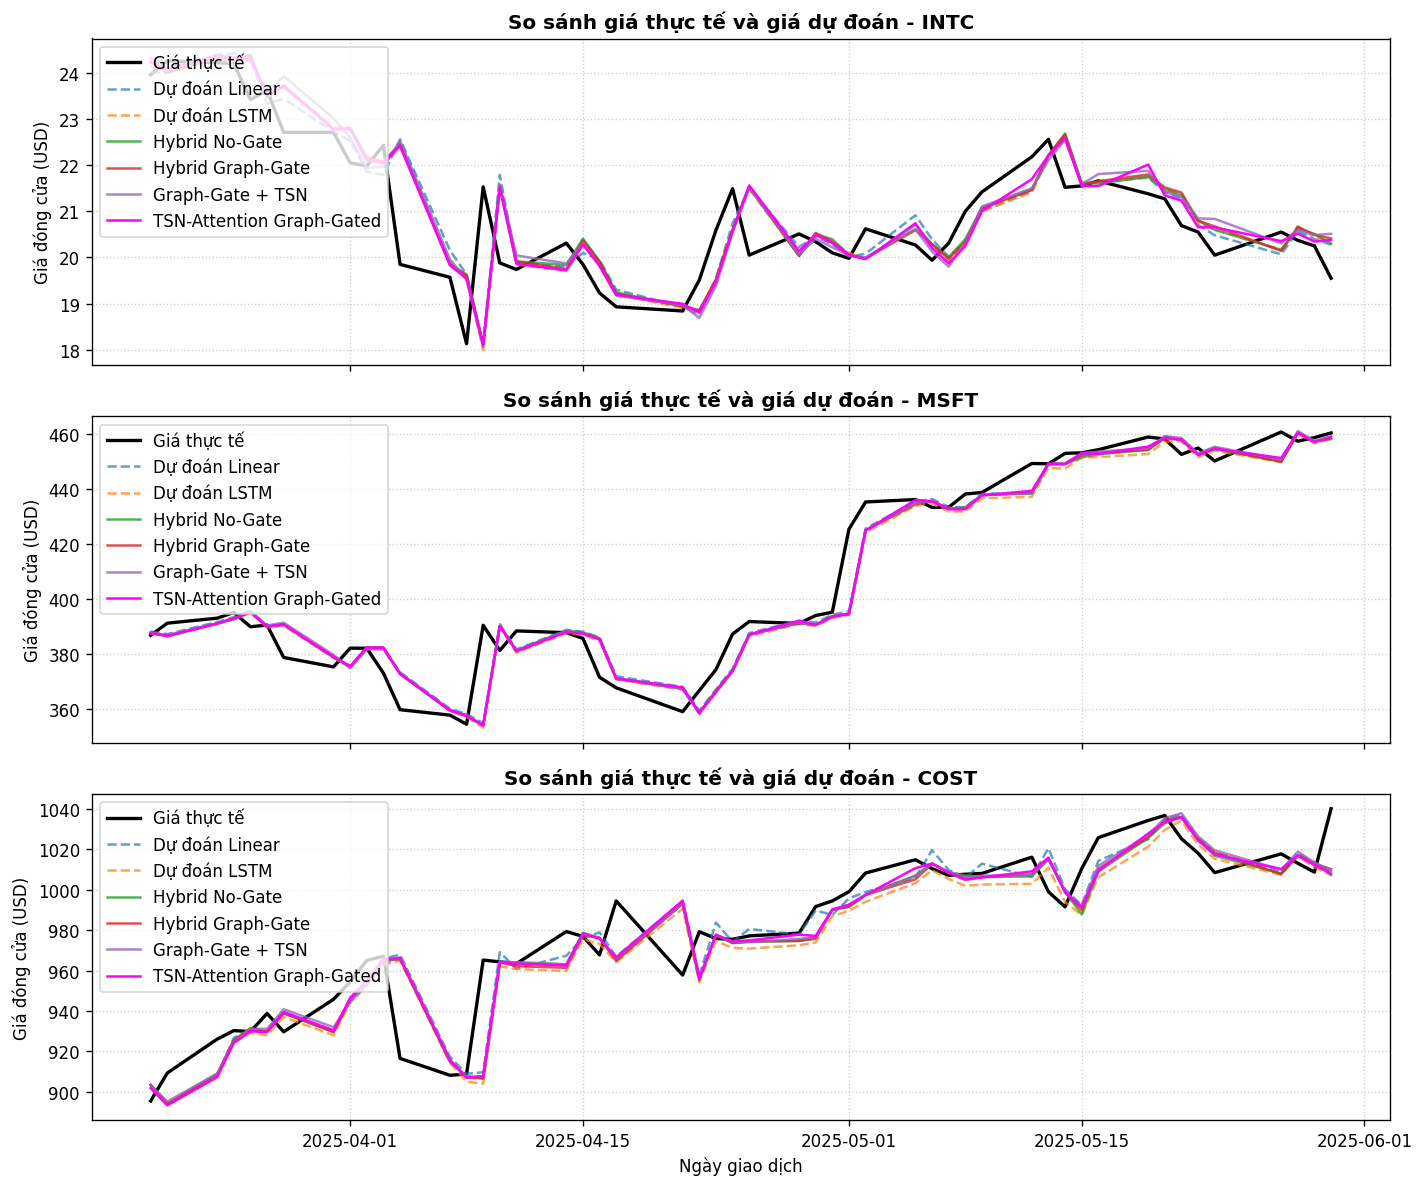

In [21]:
# CELL 18A - So sánh giá thực tế và giá dự đoán
test_dates = dates[-EXP_TEST_DAYS:]
selected_tickers = ["INTC", "MSFT", "COST"]
selected_indices = [TICKERS.index(t) for t in selected_tickers]
fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(12, 10), sharex=True)
for idx, (ticker, t_idx) in enumerate(zip(selected_tickers, selected_indices)):
    ax = axes[idx]
    ax.plot(test_dates, no_gate_exp_true[:, t_idx],
            label="Giá thực tế", color="black", linewidth=2.0)
    ax.plot(test_dates, linear_exp_pred[:, t_idx],
            label="Dự đoán Linear", linestyle="--", alpha=0.7)
    ax.plot(test_dates, lstm_exp_pred[:, t_idx],
            label="Dự đoán LSTM", linestyle="--", alpha=0.7)
    ax.plot(test_dates, no_gate_exp_pred[:, t_idx],
            label="Hybrid No-Gate", linewidth=1.5, alpha=0.8)
    ax.plot(test_dates, graph_gate_exp_pred[:, t_idx],
            label="Hybrid Graph-Gate", linewidth=1.5, alpha=0.8)
    ax.plot(test_dates, gg_tsn_exp_pred[:, t_idx],
            label="Graph-Gate + TSN", linewidth=1.5, alpha=0.8)
    ax.plot(test_dates, tsn_attn_exp_pred[:, t_idx],
            label="TSN-Attention Graph-Gated", linewidth=1.5, color="magenta")
    ax.set_title(
        f"So sánh giá thực tế và giá dự đoán - {ticker}",
        fontsize=12,
        fontweight="bold"
    )
    ax.set_ylabel("Giá đóng cửa (USD)")
    ax.legend(loc="upper left")
    ax.grid(True, linestyle=":", alpha=0.6)
plt.xlabel("Ngày giao dịch")
plt.tight_layout()
plt.show()


In [22]:
# CELL 18B - Định nghĩa hàm tạo prediction DataFrame
# Mục tiêu: gom các dự đoán và giá thực tế dạng scaled thành dataframe chi tiết giá thực tế để backtest.

def build_financial_prediction_df(
    model_name,
    y_true_real,
    y_pred_real,
    last_close_real,
    dates,
    tickers,
    first_test_t,
    close_mins=None,
    close_maxs=None
):
    y_true_real = np.asarray(y_true_real)
    y_pred_real = np.asarray(y_pred_real)
    last_close_real = np.asarray(last_close_real)

    test_days, num_tickers = y_true_real.shape
    test_dates = dates[first_test_t:first_test_t + test_days]

    rows = []
    for day_idx, date in enumerate(test_dates):
        for ticker_idx, ticker in enumerate(tickers):
            rows.append({
                "Model": model_name,
                "Date": date,
                "Ticker": ticker,
                "Last_Close": float(last_close_real[day_idx, ticker_idx]),
                "Actual_Close": float(y_true_real[day_idx, ticker_idx]),
                "Predicted_Close": float(y_pred_real[day_idx, ticker_idx]),
            })

    return pd.DataFrame(rows)


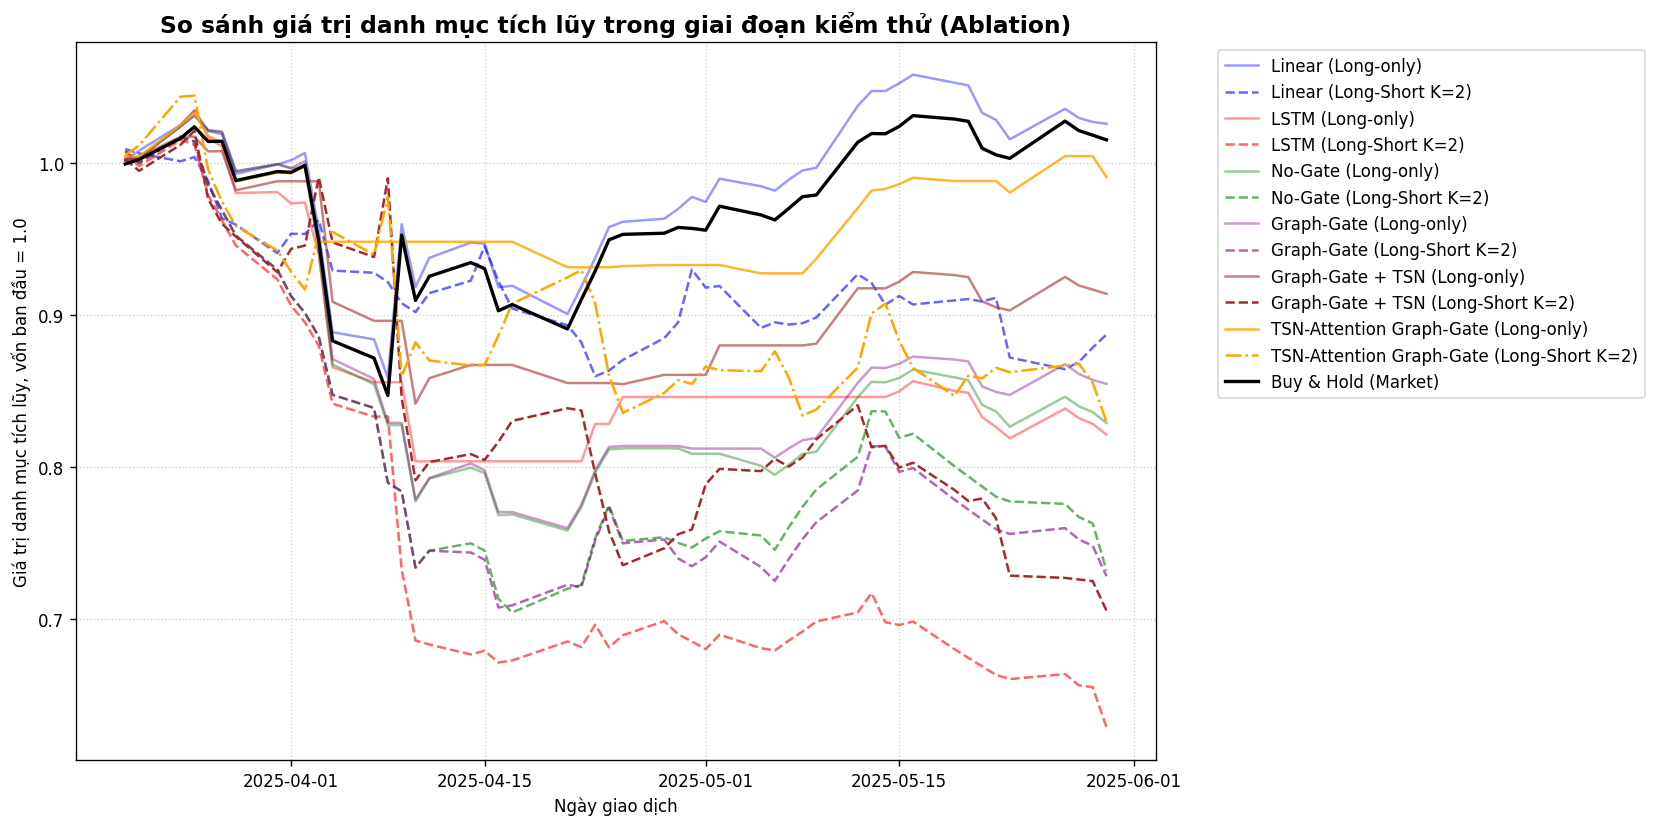

In [23]:
# CELL 18C - Vẽ cumulative return theo từng mô hình

test_dates = dates[-EXP_TEST_DAYS:]

linear_bt = backtest_long_only_strategy(linear_exp_true, linear_exp_pred, linear_exp_last, TICKERS)
lstm_bt = backtest_long_only_strategy(lstm_exp_true, lstm_exp_pred, lstm_exp_last, TICKERS)
no_gate_bt = backtest_long_only_strategy(no_gate_exp_true, no_gate_exp_pred, no_gate_exp_last, TICKERS)
graph_gate_bt = backtest_long_only_strategy(graph_gate_exp_true, graph_gate_exp_pred, graph_gate_exp_last, TICKERS)
gg_tsn_bt = backtest_long_only_strategy(gg_tsn_exp_true, gg_tsn_exp_pred, gg_tsn_exp_last, TICKERS)
tsn_attn_bt = backtest_long_only_strategy(tsn_attn_exp_true, tsn_attn_exp_pred, tsn_attn_exp_last, TICKERS)

linear_ls = backtest_topk_long_short_strategy(linear_exp_true, linear_exp_pred, linear_exp_last, K=2)
lstm_ls = backtest_topk_long_short_strategy(lstm_exp_true, lstm_exp_pred, lstm_exp_last, K=2)
no_gate_ls = backtest_topk_long_short_strategy(no_gate_exp_true, no_gate_exp_pred, no_gate_exp_last, K=2)
graph_gate_ls = backtest_topk_long_short_strategy(graph_gate_exp_true, graph_gate_exp_pred, graph_gate_exp_last, K=2)
gg_tsn_ls = backtest_topk_long_short_strategy(gg_tsn_exp_true, gg_tsn_exp_pred, gg_tsn_exp_last, K=2)
tsn_attn_ls = backtest_topk_long_short_strategy(tsn_attn_exp_true, tsn_attn_exp_pred, tsn_attn_exp_last, K=2)

plt.figure(figsize=(14, 7))

plt.plot(test_dates, (1.0 + linear_bt["strategy_daily_returns"]).cumprod(), label="Linear (Long-only)", color="blue", alpha=0.4)
plt.plot(test_dates, (1.0 + linear_ls["strategy_daily_returns"]).cumprod(), label="Linear (Long-Short K=2)", color="blue", linestyle="--", alpha=0.6)

plt.plot(test_dates, (1.0 + lstm_bt["strategy_daily_returns"]).cumprod(), label="LSTM (Long-only)", color="red", alpha=0.4)
plt.plot(test_dates, (1.0 + lstm_ls["strategy_daily_returns"]).cumprod(), label="LSTM (Long-Short K=2)", color="red", linestyle="--", alpha=0.6)

plt.plot(test_dates, (1.0 + no_gate_bt["strategy_daily_returns"]).cumprod(), label="No-Gate (Long-only)", color="green", alpha=0.4)
plt.plot(test_dates, (1.0 + no_gate_ls["strategy_daily_returns"]).cumprod(), label="No-Gate (Long-Short K=2)", color="green", linestyle="--", alpha=0.6)

plt.plot(test_dates, (1.0 + graph_gate_bt["strategy_daily_returns"]).cumprod(), label="Graph-Gate (Long-only)", color="purple", alpha=0.4)
plt.plot(test_dates, (1.0 + graph_gate_ls["strategy_daily_returns"]).cumprod(), label="Graph-Gate (Long-Short K=2)", color="purple", linestyle="--", alpha=0.6)

plt.plot(test_dates, (1.0 + gg_tsn_bt["strategy_daily_returns"]).cumprod(), label="Graph-Gate + TSN (Long-only)", color="brown", alpha=0.6)
plt.plot(test_dates, (1.0 + gg_tsn_ls["strategy_daily_returns"]).cumprod(), label="Graph-Gate + TSN (Long-Short K=2)", color="brown", linestyle="--")

plt.plot(test_dates, (1.0 + tsn_attn_bt["strategy_daily_returns"]).cumprod(), label="TSN-Attention Graph-Gate (Long-only)", color="orange", alpha=0.8)
plt.plot(test_dates, (1.0 + tsn_attn_ls["strategy_daily_returns"]).cumprod(), label="TSN-Attention Graph-Gate (Long-Short K=2)", color="orange", linestyle="-.")

buyhold_equity = (1.0 + graph_gate_bt["buyhold_daily_returns"]).cumprod()
plt.plot(test_dates, buyhold_equity, label="Buy & Hold (Market)", color="black", linewidth=2)

plt.title("So sánh giá trị danh mục tích lũy trong giai đoạn kiểm thử (Ablation)", fontsize=14, fontweight="bold")
plt.xlabel("Ngày giao dịch")
plt.ylabel("Giá trị danh mục tích lũy, vốn ban đầu = 1.0")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()



=== BẢNG CHỈ SỐ TÀI CHÍNH CHI TIẾT (TÍNH TRÊN GIÁ TRỊ USD THỰC TẾ) ===


,Mô hình / Chiến lược,Lợi nhuận chiến lược (%),Lợi nhuận Buy & Hold (%),Sharpe Ratio hằng năm,Sharpe B&H hằng năm,Mức sụt giảm tối đa (%),Sụt giảm tối đa B&H (%),Tỷ lệ ngày thắng (%),Số vị thế TB
0,Linear (Long-only),2.592342,1.537525,0.518682,0.387495,16.993619,17.277095,56.0,10.0
1,TSN-Attention (Long-only),-0.917862,1.537525,-0.160558,0.387495,10.253432,17.277095,28.0,5.0
2,Graph-Gate + TSN (Long-only),-8.597855,1.537525,-1.494456,0.387495,17.268409,17.277095,28.0,6.0
3,Linear (Long-Short K=2),-11.275556,1.537525,-2.281347,0.387495,14.824334,17.277095,48.0,4.0
4,Hybrid Graph-Gate (Long-only),-14.525340,1.537525,-2.194853,0.387495,26.339413,17.277095,40.0,8.8
5,TSN-Attention (Long-Short K=2),-17.041314,1.537525,-1.967599,0.387495,20.576902,17.277095,50.0,4.0
6,Hybrid No-Gate (Long-only),-17.102594,1.537525,-2.652275,0.387495,26.487059,17.277095,42.0,9.0
7,LSTM (Long-only),-17.870753,1.537525,-3.437933,0.387495,22.329133,17.277095,22.0,5.4
8,Hybrid No-Gate (Long-Short K=2),-26.807947,1.537525,-4.348925,0.387495,30.784252,17.277095,34.0,4.0
9,Hybrid Graph-Gate (Long-Short K=2),-27.189959,1.537525,-4.465859,0.387495,30.463224,17.277095,34.0,4.0


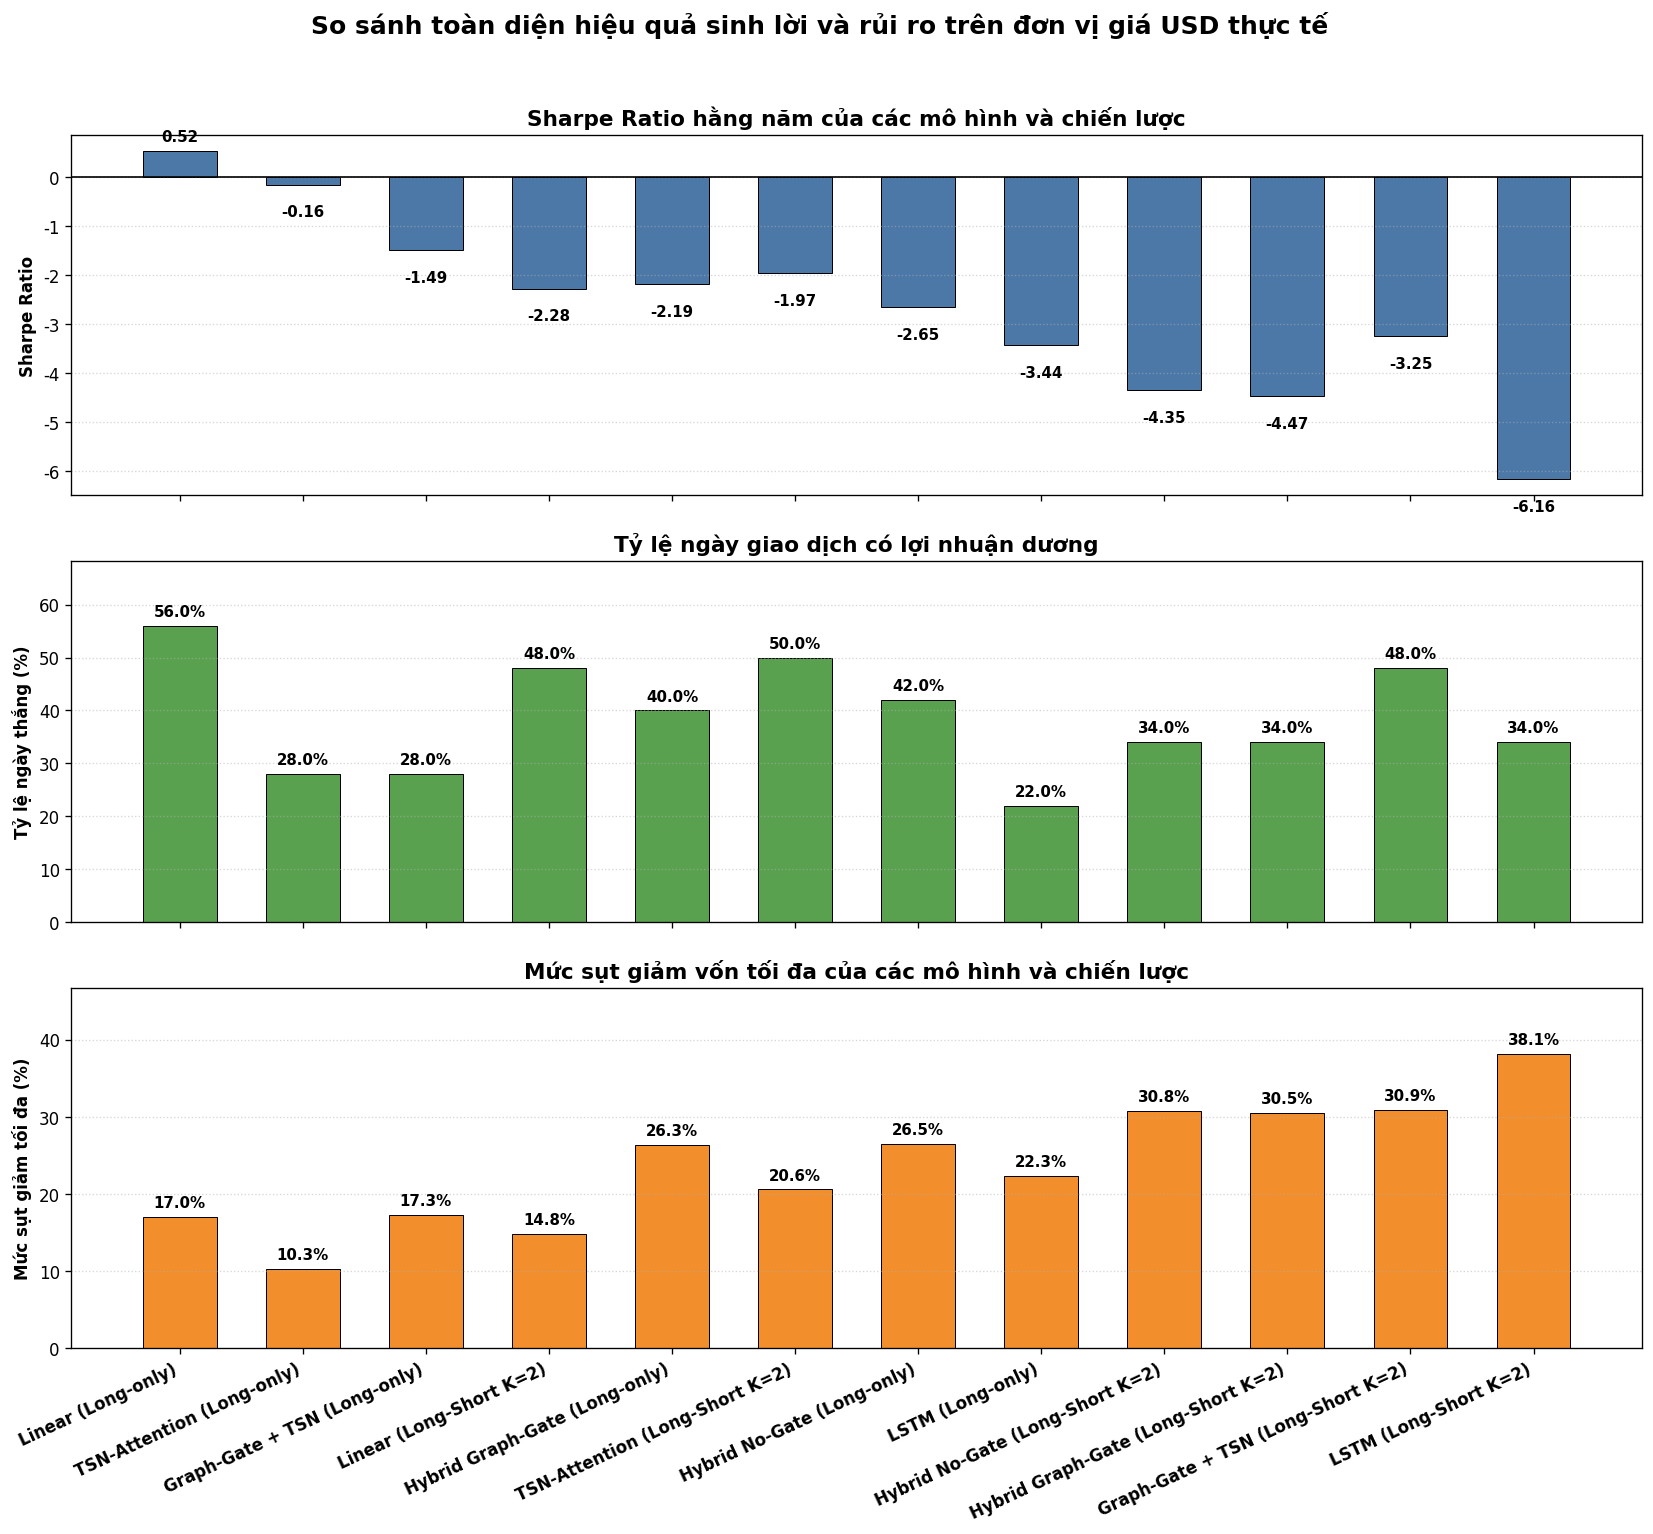

In [24]:
# CELL 18D - So sánh chỉ số hiệu quả tài chính
# Mục tiêu: Đánh giá chi tiết hiệu năng tài chính dựa trên 9 chỉ số tiêu chuẩn chuyên sâu.
# So sánh song hành hai chiến lược: Long-only (chỉ mua) vs Top-K Long-Short (Mua Top K - Bán khống Bottom K).
# Tất cả chỉ số được tính toán unscaled từ giá trị USD thực tế.
def get_detailed_financial_metrics(bt_res, model_name):
    daily_ret = bt_res["strategy_daily_returns"]
    port_vals = bt_res["strategy_portfolio"]
    bh_ret = bt_res["buyhold_daily_returns"]
    bh_port = bt_res["buyhold_portfolio"]
    
    cum_ret = float(port_vals[-1] - 1.0) if len(port_vals) > 0 else 0.0
    bh_cum_ret = float(bh_port[-1] - 1.0) if len(bh_port) > 0 else 0.0
    
    sharpe = compute_sharpe_ratio(daily_ret)
    bh_sharpe = compute_sharpe_ratio(bh_ret)
    
    mdd = compute_maximum_drawdown(port_vals)
    bh_mdd = compute_maximum_drawdown(bh_port)
    
    win_rate = compute_win_rate(daily_ret)
    
    # Vị thế mở trung bình
    if "Long-Short" in model_name:
        avg_positions = 4.0  # K=2 long + K=2 short cố định
    else:
        avg_positions = float((bt_res.get("strategy_daily_returns", np.zeros(1)) != 0).mean() * len(TICKERS))
        
    return {
        "Mô hình / Chiến lược": model_name,
        "Lợi nhuận chiến lược (%)": cum_ret * 100,
        "Lợi nhuận Buy & Hold (%)": bh_cum_ret * 100,
        "Sharpe Ratio hằng năm": sharpe,
        "Sharpe B&H hằng năm": bh_sharpe,
        "Mức sụt giảm tối đa (%)": abs(mdd * 100),
        "Sụt giảm tối đa B&H (%)": abs(bh_mdd * 100),
        "Tỷ lệ ngày thắng (%)": win_rate * 100,
        "Số vị thế TB": avg_positions
    }
models_bt = {
    "Linear (Long-only)": linear_bt,
    "Linear (Long-Short K=2)": linear_ls,
    "LSTM (Long-only)": lstm_bt,
    "LSTM (Long-Short K=2)": lstm_ls,
    "Hybrid No-Gate (Long-only)": no_gate_bt,
    "Hybrid No-Gate (Long-Short K=2)": no_gate_ls,
    "Hybrid Graph-Gate (Long-only)": graph_gate_bt,
    "Hybrid Graph-Gate (Long-Short K=2)": graph_gate_ls,
    "Graph-Gate + TSN (Long-only)": gg_tsn_bt,
    "Graph-Gate + TSN (Long-Short K=2)": gg_tsn_ls,
    "TSN-Attention (Long-only)": tsn_attn_bt,
    "TSN-Attention (Long-Short K=2)": tsn_attn_ls
}
financial_rows = []
for name, bt_res in models_bt.items():
    financial_rows.append(get_detailed_financial_metrics(bt_res, name))
financial_metrics_df = pd.DataFrame(financial_rows).sort_values("Lợi nhuận chiến lược (%)", ascending=False).reset_index(drop=True)
print("=== BẢNG CHỈ SỐ TÀI CHÍNH CHI TIẾT (TÍNH TRÊN GIÁ TRỊ USD THỰC TẾ) ===")
display(financial_metrics_df)
# ==========================
# Cấu hình hiển thị đồ thị cột
# ==========================
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
model_labels = financial_metrics_df["Mô hình / Chiến lược"].tolist()
x = np.arange(len(model_labels))
fig, axes = plt.subplots(
    3, 1,
    figsize=(14, 13),
    sharex=True
)
# Hàm thêm nhãn số trên đầu cột
def add_bar_labels(ax, bars, fmt="{:.2f}"):
    for bar in bars:
        height = bar.get_height()
        if height >= 0:
            y_offset = 4
            va = "bottom"
        else:
            y_offset = -12
            va = "top"
        ax.annotate(
            fmt.format(height),
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, y_offset),
            textcoords="offset points",
            ha="center",
            va=va,
            fontsize=9,
            fontweight="bold"
        )
# 1. Sharpe Ratio
bars1 = axes[0].bar(
    x,
    financial_metrics_df["Sharpe Ratio hằng năm"],
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.6,
    width=0.6
)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_ylabel("Sharpe Ratio", fontweight="bold")
axes[0].set_title("Sharpe Ratio hằng năm của các mô hình và chiến lược", fontsize=13, fontweight="bold")
axes[0].grid(axis="y", linestyle=":", alpha=0.5)
add_bar_labels(axes[0], bars1, fmt="{:.2f}")
# 2. Tỷ lệ ngày thắng
bars2 = axes[1].bar(
    x,
    financial_metrics_df["Tỷ lệ ngày thắng (%)"],
    color="#59A14F",
    edgecolor="black",
    linewidth=0.6,
    width=0.6
)
axes[1].set_ylabel("Tỷ lệ ngày thắng (%)", fontweight="bold")
axes[1].set_title("Tỷ lệ ngày giao dịch có lợi nhuận dương", fontsize=13, fontweight="bold")
axes[1].set_ylim(0, financial_metrics_df["Tỷ lệ ngày thắng (%)"].max() * 1.2 + 1)
axes[1].grid(axis="y", linestyle=":", alpha=0.5)
add_bar_labels(axes[1], bars2, fmt="{:.1f}%")
# 3. Mức sụt giảm tối đa
bars3 = axes[2].bar(
    x,
    financial_metrics_df["Mức sụt giảm tối đa (%)"],
    color="#F28E2B",
    edgecolor="black",
    linewidth=0.6,
    width=0.6
)
axes[2].set_ylabel("Mức sụt giảm tối đa (%)", fontweight="bold")
axes[2].set_title("Mức sụt giảm vốn tối đa của các mô hình và chiến lược", fontsize=13, fontweight="bold")
axes[2].set_ylim(0, financial_metrics_df["Mức sụt giảm tối đa (%)"].max() * 1.2 + 1)
axes[2].grid(axis="y", linestyle=":", alpha=0.5)
add_bar_labels(axes[2], bars3, fmt="{:.1f}%")
axes[2].set_xticks(x)
axes[2].set_xticklabels(
    model_labels,
    rotation=25,
    ha="right",
    fontweight="bold"
)
fig.suptitle("So sánh toàn diện hiệu quả sinh lời và rủi ro trên đơn vị giá USD thực tế", fontsize=15, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


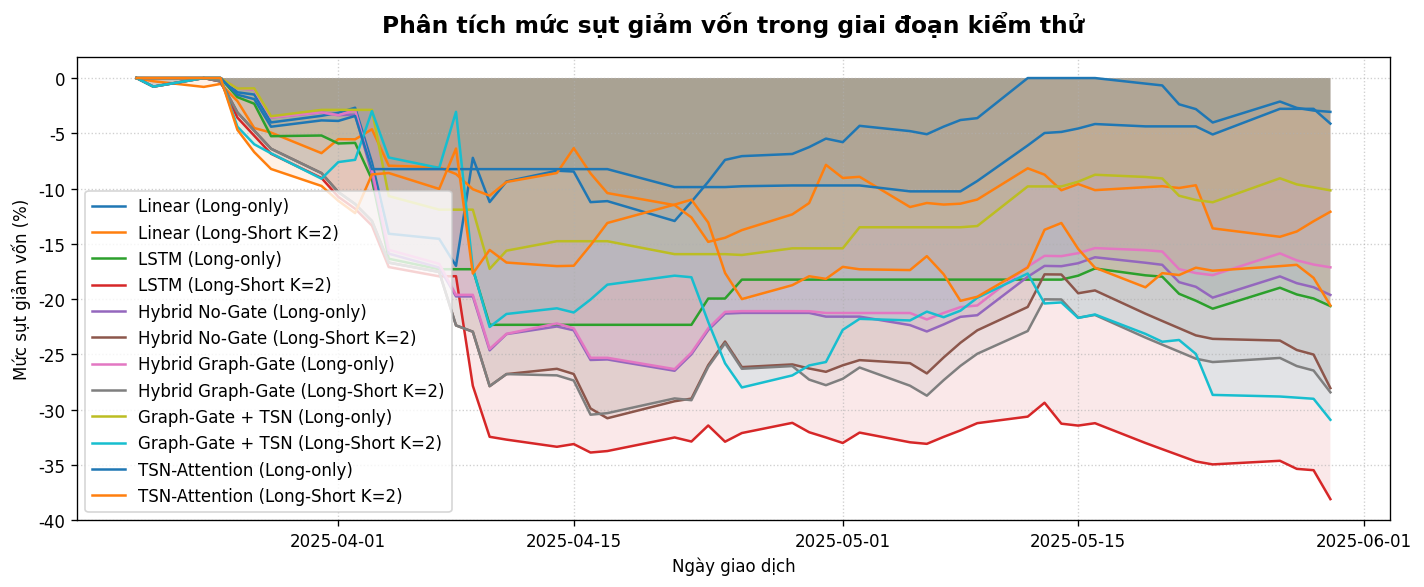

In [25]:
# CELL 18E - Biểu đồ sụt giảm vốn theo thời gian (Drawdown Shaded Area Chart)

plt.figure(figsize=(12, 5))

for name, bt_res in models_bt.items():
    port_vals = bt_res["strategy_portfolio"]
    cum_max = np.maximum.accumulate(port_vals)
    drawdowns = (port_vals - cum_max) / (cum_max + 1e-12)
    plt.plot(test_dates, drawdowns * 100, label=name)
    plt.fill_between(test_dates, drawdowns * 100, 0, alpha=0.1)

bh_port = graph_gate_bt["buyhold_portfolio"]
bh_cum_max = np.maximum.accumulate(bh_port)
bh_drawdowns = (bh_port - bh_cum_max) / (bh_cum_max + 1e-12)

plt.title("Phân tích mức sụt giảm vốn trong giai đoạn kiểm thử", fontsize=14, fontweight="bold", pad=15)
plt.ylabel("Mức sụt giảm vốn (%)")
plt.xlabel("Ngày giao dịch")
plt.legend(loc="lower left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [26]:
# CELL 19 - So sánh MSE theo từng ngày test
# Mục tiêu: kiểm tra Hybrid thắng LSTM hoặc Graph-Gate thắng No-Gate bao nhiêu ngày trong test window.
# Góc nhìn theo ngày giúp hiểu kết quả tổng hợp có ổn định hay chỉ tốt ở vài điểm.

compare_step_df = lstm_exp_step_df.rename(columns={"Day_MSE": "LSTM_Day_MSE"}).merge(
    no_gate_exp_step_df.rename(columns={"Day_MSE": "NoGate_Day_MSE"}),
    on=["Step", "Date"],
    how="inner"
).merge(
    graph_gate_exp_step_df.rename(columns={"Day_MSE": "GraphGate_Day_MSE"}),
    on=["Step", "Date"],
    how="inner"
)

compare_step_df["NoGate_Better_Than_LSTM"] = compare_step_df["NoGate_Day_MSE"] < compare_step_df["LSTM_Day_MSE"]
compare_step_df["GraphGate_Better_Than_LSTM"] = compare_step_df["GraphGate_Day_MSE"] < compare_step_df["LSTM_Day_MSE"]
compare_step_df["GraphGate_Better_Than_NoGate"] = compare_step_df["GraphGate_Day_MSE"] < compare_step_df["NoGate_Day_MSE"]
compare_step_df["NoGate_Improvement_vs_LSTM"] = compare_step_df["LSTM_Day_MSE"] - compare_step_df["NoGate_Day_MSE"]
compare_step_df["GraphGate_Improvement_vs_LSTM"] = compare_step_df["LSTM_Day_MSE"] - compare_step_df["GraphGate_Day_MSE"]
compare_step_df["GraphGate_Improvement_vs_NoGate"] = compare_step_df["NoGate_Day_MSE"] - compare_step_df["GraphGate_Day_MSE"]

print("No-Gate better than LSTM:", int(compare_step_df["NoGate_Better_Than_LSTM"].sum()), "/", len(compare_step_df))
print("Graph-Gate better than LSTM:", int(compare_step_df["GraphGate_Better_Than_LSTM"].sum()), "/", len(compare_step_df))
print("Graph-Gate better than No-Gate:", int(compare_step_df["GraphGate_Better_Than_NoGate"].sum()), "/", len(compare_step_df))

compare_step_df.head()

# So sánh thêm TSN models
compare_step_df = compare_step_df.merge(
    gg_tsn_exp_step_df.rename(columns={"Day_MSE": "GG_TSN_Day_MSE"})[["Step", "GG_TSN_Day_MSE"]],
    on="Step", how="left"
).merge(
    tsn_attn_exp_step_df.rename(columns={"Day_MSE": "TSNAttn_Day_MSE"})[["Step", "TSNAttn_Day_MSE"]],
    on="Step", how="left"
)
compare_step_df["GG_TSN_Better_Than_LSTM"] = compare_step_df["GG_TSN_Day_MSE"] < compare_step_df["LSTM_Day_MSE"]
compare_step_df["TSNAttn_Better_Than_LSTM"] = compare_step_df["TSNAttn_Day_MSE"] < compare_step_df["LSTM_Day_MSE"]

print("GG+TSN better than LSTM:", int(compare_step_df["GG_TSN_Better_Than_LSTM"].sum()), "/", len(compare_step_df))
print("TSN-Attention better than LSTM:", int(compare_step_df["TSNAttn_Better_Than_LSTM"].sum()), "/", len(compare_step_df))


No-Gate better than LSTM: 34 / 50
Graph-Gate better than LSTM: 33 / 50
Graph-Gate better than No-Gate: 20 / 50
GG+TSN better than LSTM: 32 / 50
TSN-Attention better than LSTM: 34 / 50


In [27]:
# CELL 20 - Chẩn đoán graph và graph gate
# Mục tiêu: xem số cạnh trung bình của graph và thống kê gate để hiểu Graph-Gate dùng graph mạnh/yếu ra sao.
# GateMean gần 1 nghĩa là mô hình dùng phần graph mạnh hơn; thấp hơn nghĩa là graph bị giảm ảnh hưởng.

print("Số cạnh Pearson trung bình:", graph_step_df["Pearson_Edges"].mean())
print("Số cạnh Association trung bình:", graph_step_df["Assoc_Edges"].mean())
print("Số cạnh Combined trung bình:", graph_step_df["Combined_Edges"].mean())

print("Thống kê gate theo mô hình:")
display(gate_step_df.groupby("Model")[["Gate_Mean", "Gate_Min", "Gate_Max", "Gate_STD"]].mean().reset_index())

if graph_step_df["Combined_Edges"].mean() == 0:
    print("CẢNH BÁO: Combined graph vẫn không có cạnh. Kết quả hiện tại chưa chứng minh được đóng góp thật sự của GNN.")
else:
    print("Graph đã có cạnh. Có thể tiếp tục phân tích đóng góp của mô hình LSTM-GNN.")

graph_step_df.head(5), gate_step_df.head(10)


Số cạnh Pearson trung bình: 43.04
Số cạnh Association trung bình: 44.0
Số cạnh Combined trung bình: 51.72
Thống kê gate theo mô hình:


,Model,Gate_Mean,Gate_Min,Gate_Max,Gate_STD
0,Hybrid LSTM-GNN Graph-Gate,0.712177,0.7079,0.716348,0.002862
1,Hybrid LSTM-GNN No-Gate,1.000000,1.0000,1.000000,0.000000


Graph đã có cạnh. Có thể tiếp tục phân tích đóng góp của mô hình LSTM-GNN.


(   Step       Date  Pearson_Edges  Assoc_Edges  Combined_Edges
 0     1 2025-03-20             46           44              52
 1     2 2025-03-21             46           44              50
 2     3 2025-03-24             46           44              50
 3     4 2025-03-25             46           44              52
 4     5 2025-03-26             46           44              52,
    Step       Date                       Model  Gate_Mean  Gate_Min  Gate_Max  \
 0     1 2025-03-20     Hybrid LSTM-GNN No-Gate        1.0       1.0       1.0   
 1     1 2025-03-20  Hybrid LSTM-GNN Graph-Gate        1.0       1.0       1.0   
 2     2 2025-03-21     Hybrid LSTM-GNN No-Gate        1.0       1.0       1.0   
 3     2 2025-03-21  Hybrid LSTM-GNN Graph-Gate        1.0       1.0       1.0   
 4     3 2025-03-24     Hybrid LSTM-GNN No-Gate        1.0       1.0       1.0   
 5     3 2025-03-24  Hybrid LSTM-GNN Graph-Gate        1.0       1.0       1.0   
 6     4 2025-03-25     Hybrid LSTM-GNN N

In [28]:
# CELL 21 - MSE theo từng mã cổ phiếu

stock_rows = []

for j, ticker in enumerate(TICKERS):
    linear_mse_j = mean_squared_error(linear_exp_true[:, j], linear_exp_pred[:, j])
    lstm_mse_j = mean_squared_error(lstm_exp_true[:, j], lstm_exp_pred[:, j])
    no_gate_mse_j = mean_squared_error(no_gate_exp_true[:, j], no_gate_exp_pred[:, j])
    graph_gate_mse_j = mean_squared_error(graph_gate_exp_true[:, j], graph_gate_exp_pred[:, j])

    gg_tsn_mse_j = mean_squared_error(gg_tsn_exp_true[:, j], gg_tsn_exp_pred[:, j])
    tsn_attn_mse_j = mean_squared_error(tsn_attn_exp_true[:, j], tsn_attn_exp_pred[:, j])

    stock_rows.append({
        "Ticker": ticker,
        "Linear_MSE": linear_mse_j,
        "LSTM_MSE": lstm_mse_j,
        "NoGate_MSE": no_gate_mse_j,
        "GraphGate_MSE": graph_gate_mse_j,
        "GG_TSN_MSE": gg_tsn_mse_j,
        "TSNAttn_MSE": tsn_attn_mse_j,
        "NoGate_Better_Than_LSTM": no_gate_mse_j < lstm_mse_j,
        "GraphGate_Better_Than_LSTM": graph_gate_mse_j < lstm_mse_j,
        "GG_TSN_Better_Than_LSTM": gg_tsn_mse_j < lstm_mse_j,
        "TSNAttn_Better_Than_LSTM": tsn_attn_mse_j < lstm_mse_j,
        "GraphGate_Better_Than_NoGate": graph_gate_mse_j < no_gate_mse_j,
        "NoGate_Improvement_vs_LSTM": lstm_mse_j - no_gate_mse_j,
        "GraphGate_Improvement_vs_LSTM": lstm_mse_j - graph_gate_mse_j,
        "GG_TSN_Improvement_vs_LSTM": lstm_mse_j - gg_tsn_mse_j,
        "TSNAttn_Improvement_vs_LSTM": lstm_mse_j - tsn_attn_mse_j,
        "GraphGate_Improvement_vs_NoGate": no_gate_mse_j - graph_gate_mse_j
    })

stock_mse_df = pd.DataFrame(stock_rows).sort_values("GraphGate_Improvement_vs_NoGate", ascending=False).reset_index(drop=True)
stock_mse_df

,Ticker,Linear_MSE,LSTM_MSE,NoGate_MSE,GraphGate_MSE,GG_TSN_MSE,TSNAttn_MSE,NoGate_Better_Than_LSTM,GraphGate_Better_Than_LSTM,GG_TSN_Better_Than_LSTM,TSNAttn_Better_Than_LSTM,GraphGate_Better_Than_NoGate,NoGate_Improvement_vs_LSTM,GraphGate_Improvement_vs_LSTM,GG_TSN_Improvement_vs_LSTM,TSNAttn_Improvement_vs_LSTM,GraphGate_Improvement_vs_NoGate
0,COST,258.419281,288.483795,268.985504,265.640167,258.310791,259.762238,True,True,True,True,True,19.498291,22.843628,30.173004,28.721558,3.345337
1,INTU,250.033997,256.262512,247.545151,246.523666,243.991257,245.041214,True,True,True,True,True,8.717361,9.738846,12.271255,11.221298,1.021484
2,MSFT,78.069557,84.032051,80.917419,80.880920,81.250008,79.584892,True,True,True,True,True,3.114632,3.151131,2.782043,4.447159,0.036499
3,SBUX,7.912677,8.025046,8.064120,8.040023,8.031517,7.940563,False,False,False,True,True,-0.039074,-0.014977,-0.006471,0.084484,0.024097
4,CMCSA,0.418099,0.395809,0.391552,0.392886,0.397848,0.385591,True,True,False,True,False,0.004256,0.002923,-0.002039,0.010218,-0.001333
5,INTC,0.758196,0.758988,0.751519,0.757775,0.780564,0.733907,True,True,False,True,False,0.007469,0.001213,-0.021576,0.025081,-0.006256
6,AAPL,44.592682,45.525707,45.438862,45.496593,45.507286,45.322960,True,True,True,True,False,0.086845,0.029114,0.018421,0.202747,-0.057732
7,ADBE,53.046715,55.975166,54.439789,54.529804,57.233158,53.588280,True,True,False,True,False,1.535378,1.445362,-1.257992,2.386887,-0.090015
8,QCOM,26.520632,26.315195,25.952417,26.089989,26.257998,25.617363,True,True,True,True,False,0.362778,0.225206,0.057198,0.697832,-0.137571
9,AMD,19.627934,20.007166,19.480209,19.632622,20.140511,19.162191,True,True,False,True,False,0.526957,0.374544,-0.133345,0.844975,-0.152412


In [29]:
# CELL 22 - Đếm số mã hybrid thắng baseline
# Mục tiêu: tóm tắt số ticker mà No-Gate/Graph-Gate cải thiện so với LSTM hoặc so với nhau.
# Đây là kiểm tra nhanh về độ nhất quán của lợi ích từ graph.

print("Số mã No-Gate tốt hơn LSTM:", int(stock_mse_df["NoGate_Better_Than_LSTM"].sum()), "/", len(stock_mse_df))
print("Số mã Graph-Gate tốt hơn LSTM:", int(stock_mse_df["GraphGate_Better_Than_LSTM"].sum()), "/", len(stock_mse_df))
print("Số mã Graph-Gate tốt hơn No-Gate:", int(stock_mse_df["GraphGate_Better_Than_NoGate"].sum()), "/", len(stock_mse_df))
stock_mse_df
print("Số mã GG+TSN tốt hơn LSTM:", int(stock_mse_df["GG_TSN_Better_Than_LSTM"].sum()), "/", len(stock_mse_df))
print("Số mã TSN-Attention tốt hơn LSTM:", int(stock_mse_df["TSNAttn_Better_Than_LSTM"].sum()), "/", len(stock_mse_df))


Số mã No-Gate tốt hơn LSTM: 9 / 10
Số mã Graph-Gate tốt hơn LSTM: 9 / 10
Số mã Graph-Gate tốt hơn No-Gate: 4 / 10
Số mã GG+TSN tốt hơn LSTM: 5 / 10
Số mã TSN-Attention tốt hơn LSTM: 10 / 10


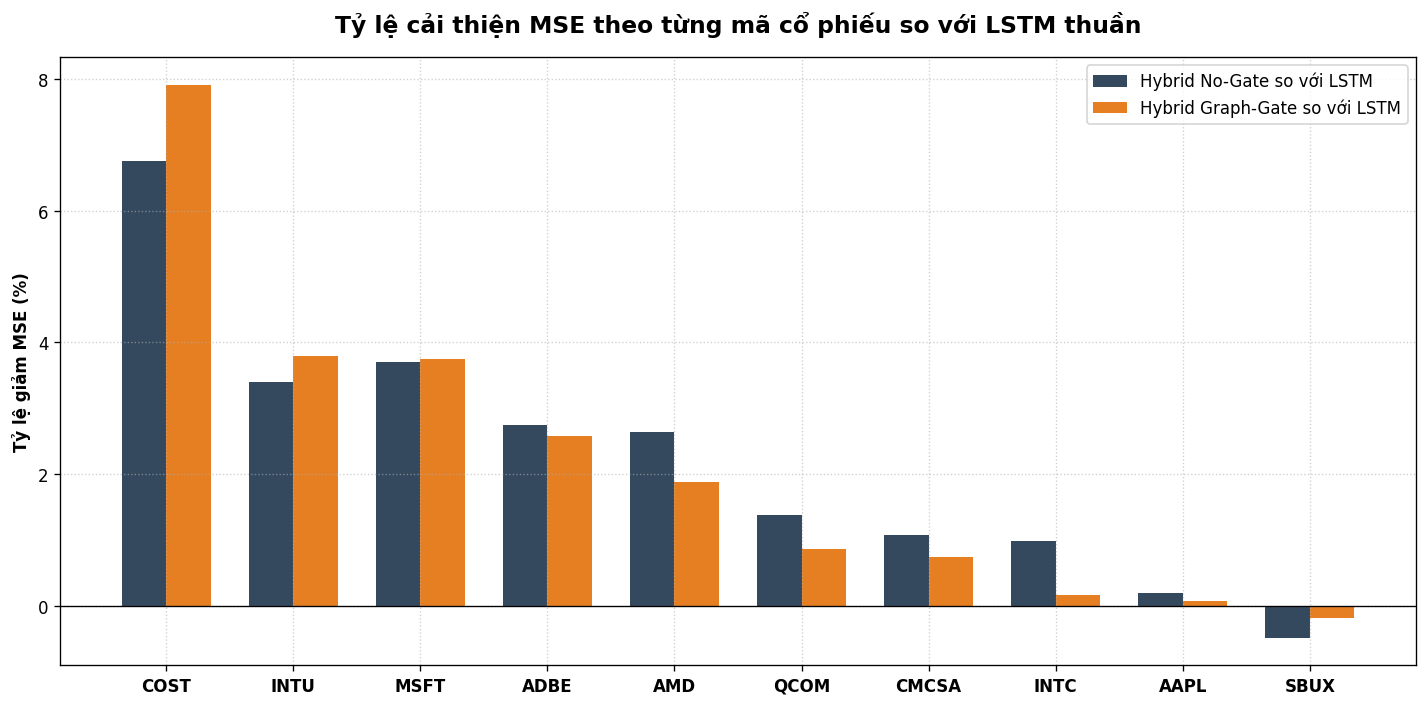

In [30]:
# CELL 22B - Biểu đồ cải thiện hiệu năng dự đoán (%) của mô hình Hybrid
# Mục tiêu: Đánh giá mức độ đóng góp của cấu trúc mạng liên kết (Graph) đối với từng cổ phiếu riêng lẻ.
# Chỉ ra phần trăm giảm lỗi MSE của No-Gate và Graph-Gate so với mô hình LSTM thuần túy.

# Tính toán phần trăm cải thiện
stock_mse_df["NoGate_Improvement_Pct"] = (stock_mse_df["NoGate_Improvement_vs_LSTM"] / stock_mse_df["LSTM_MSE"]) * 100
stock_mse_df["GraphGate_Improvement_Pct"] = (stock_mse_df["GraphGate_Improvement_vs_LSTM"] / stock_mse_df["LSTM_MSE"]) * 100

# Sắp xếp để vẽ biểu đồ trực quan
plot_df = stock_mse_df.sort_values("GraphGate_Improvement_Pct", ascending=False)

plt.figure(figsize=(12, 6))
x = np.arange(len(plot_df["Ticker"]))
width = 0.35

plt.bar(x - width/2, plot_df["NoGate_Improvement_Pct"], width, label="Hybrid No-Gate so với LSTM", color="#34495E")
plt.bar(x + width/2, plot_df["GraphGate_Improvement_Pct"], width, label="Hybrid Graph-Gate so với LSTM", color="#E67E22")

plt.axhline(0, color="black", linewidth=0.8, linestyle="-")
plt.xticks(x, plot_df["Ticker"], fontweight="bold")
plt.ylabel("Tỷ lệ giảm MSE (%)", fontweight="bold")
plt.title(
    "Tỷ lệ cải thiện MSE theo từng mã cổ phiếu so với LSTM thuần",
    fontsize=14,
    fontweight="bold",
    pad=15
)
plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

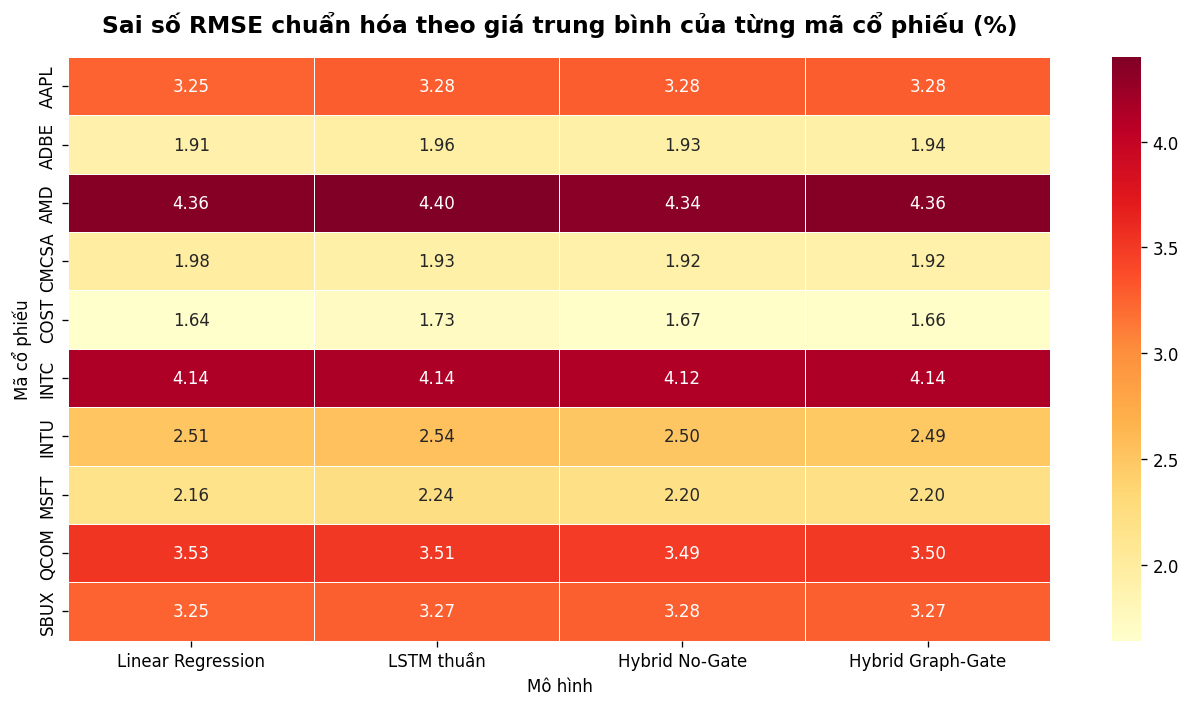

,Linear Regression,LSTM thuần,Hybrid No-Gate,Hybrid Graph-Gate
Ticker,,,,
AAPL,3.251104,3.284940,3.281806,3.283890
ADBE,1.909782,1.961789,1.934696,1.936295
AMD,4.358540,4.400444,4.342107,4.359061
CMCSA,1.979844,1.926346,1.915960,1.919219
COST,1.641419,1.734274,1.674640,1.664193
INTC,4.139777,4.141940,4.121510,4.138630
INTU,2.507825,2.538868,2.495312,2.490158
MSFT,2.159807,2.240767,2.198848,2.198352
QCOM,3.527553,3.513864,3.489559,3.498796


In [31]:
# CELL 23 - Heatmap sai số chuẩn hóa theo từng mã

import seaborn as sns

normalized_rows = []

for j, ticker in enumerate(TICKERS):
    mean_price = np.mean(no_gate_exp_true[:, j])

    normalized_rows.append({
        "Ticker": ticker,
        "Linear Regression": np.sqrt(mean_squared_error(linear_exp_true[:, j], linear_exp_pred[:, j])) / mean_price * 100,
        "LSTM thuần": np.sqrt(mean_squared_error(lstm_exp_true[:, j], lstm_exp_pred[:, j])) / mean_price * 100,
        "Hybrid No-Gate": np.sqrt(mean_squared_error(no_gate_exp_true[:, j], no_gate_exp_pred[:, j])) / mean_price * 100,
        "Hybrid Graph-Gate": np.sqrt(mean_squared_error(graph_gate_exp_true[:, j], graph_gate_exp_pred[:, j])) / mean_price * 100,
    })

normalized_error_df = pd.DataFrame(normalized_rows).set_index("Ticker")

plt.figure(figsize=(11, 6))
sns.heatmap(
    normalized_error_df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title(
    "Sai số RMSE chuẩn hóa theo giá trung bình của từng mã cổ phiếu (%)",
    fontsize=14,
    fontweight="bold",
    pad=15
)
plt.xlabel("Mô hình")
plt.ylabel("Mã cổ phiếu")
plt.tight_layout()
plt.show()

normalized_error_df

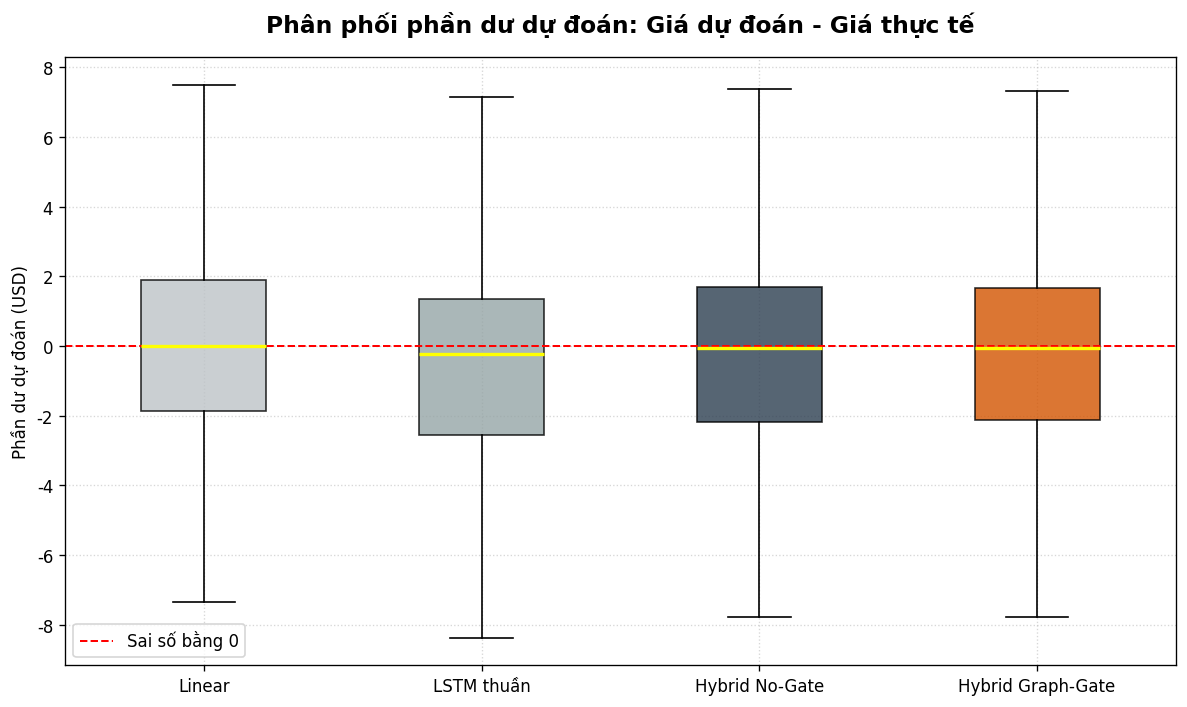

In [32]:
# CELL 23B - Biểu đồ hộp phân phối phần dư (Prediction Residuals Box Plot)

linear_errors = (linear_exp_pred - linear_exp_true).flatten()
lstm_errors = (lstm_exp_pred - lstm_exp_true).flatten()
no_gate_errors = (no_gate_exp_pred - no_gate_exp_true).flatten()
graph_gate_errors = (graph_gate_exp_pred - graph_gate_exp_true).flatten()

error_data = [linear_errors, lstm_errors, no_gate_errors, graph_gate_errors]
labels = ["Linear", "LSTM thuần", "Hybrid No-Gate", "Hybrid Graph-Gate"]

plt.figure(figsize=(10, 6))
box = plt.boxplot(error_data, patch_artist=True, labels=labels, showfliers=False)

colors = ['#BDC3C7', '#95A5A6', '#2C3E50', '#D35400']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

for median in box['medians']:
    median.set(color='yellow', linewidth=2.0)

plt.axhline(0, color="red", linestyle="--", linewidth=1.2, label="Sai số bằng 0")
plt.title("Phân phối phần dư dự đoán: Giá dự đoán - Giá thực tế", fontsize=14, fontweight="bold", pad=15)
plt.ylabel("Phần dư dự đoán (USD)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

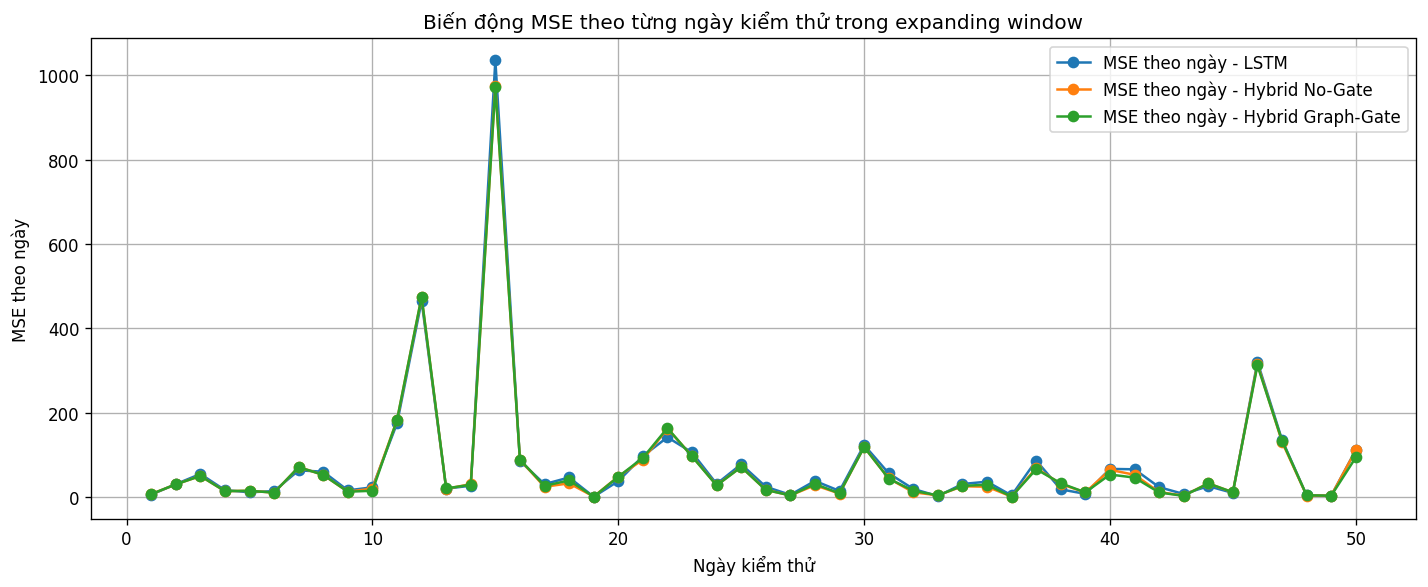

In [33]:
# CELL 24 - Biểu đồ MSE theo từng ngày test

plt.figure(figsize=(12, 5))
plt.plot(compare_step_df["Step"], compare_step_df["LSTM_Day_MSE"], label="MSE theo ngày - LSTM", marker="o")
plt.plot(compare_step_df["Step"], compare_step_df["NoGate_Day_MSE"], label="MSE theo ngày - Hybrid No-Gate", marker="o")
plt.plot(compare_step_df["Step"], compare_step_df["GraphGate_Day_MSE"], label="MSE theo ngày - Hybrid Graph-Gate", marker="o")
plt.title("Biến động MSE theo từng ngày kiểm thử trong expanding window")
plt.xlabel("Ngày kiểm thử")
plt.ylabel("MSE theo ngày")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

BẮT ĐẦU CHẠY THỬ NGHIỆM: Giai đoạn 1: 2020-2021 (Test 2022)
Huấn luyện từ: 2020-01-03 đến 2021-12-31
Kiểm thử từ: 2022-01-03 đến 2022-03-15
[Giai đoạn 1: 2020-2021 (Test 2022) - Linear] Step 01/50 | Date=2022-01-03 | Day_MSE=30.554209
[Giai đoạn 1: 2020-2021 (Test 2022) - Linear] Step 10/50 | Date=2022-01-14 | Day_MSE=30.352503
[Giai đoạn 1: 2020-2021 (Test 2022) - Linear] Step 20/50 | Date=2022-01-31 | Day_MSE=107.983192
[Giai đoạn 1: 2020-2021 (Test 2022) - Linear] Step 30/50 | Date=2022-02-14 | Day_MSE=7.888922
[Giai đoạn 1: 2020-2021 (Test 2022) - Linear] Step 40/50 | Date=2022-03-01 | Day_MSE=24.629263
[Giai đoạn 1: 2020-2021 (Test 2022) - Linear] Step 50/50 | Date=2022-03-15 | Day_MSE=72.899338
[Volatility Switch Alert] High stress volatility detected (0.0219 > 0.02). Scaling GNN influence to 0.05 to protect portfolio.
[Giai đoạn 1: 2020-2021 (Test 2022) - GNN] Step 01/50 | Date=2022-01-03 | LSTM_MSE=23.301815 | NoGate_MSE=25.537010 | GraphGate_MSE=25.220776 | Alpha=1.00 | GateMe

,Window,Model,MSE,Directional Accuracy
0,Giai đoạn 1: 2020-2021 (Test 2022),Linear Regression,64.536095,0.434
1,Giai đoạn 1: 2020-2021 (Test 2022),LSTM thuần,61.012061,0.504
2,Giai đoạn 1: 2020-2021 (Test 2022),Hybrid No-Gate,60.856425,0.496
3,Giai đoạn 1: 2020-2021 (Test 2022),Hybrid Graph-Gate Calibrated,60.751988,0.494
4,Giai đoạn 1: 2020-2021 (Test 2022),Graph-Gate + TSN,62.637921,0.526
5,Giai đoạn 1: 2020-2021 (Test 2022),TSN-Attention Graph-Gate,61.903236,0.552
6,Giai đoạn 2: 2021-2022 (Test 2023),Linear Regression,24.799228,0.502
7,Giai đoạn 2: 2021-2022 (Test 2023),LSTM thuần,24.833650,0.528
8,Giai đoạn 2: 2021-2022 (Test 2023),Hybrid No-Gate,24.992066,0.484
9,Giai đoạn 2: 2021-2022 (Test 2023),Hybrid Graph-Gate Calibrated,25.008191,0.480


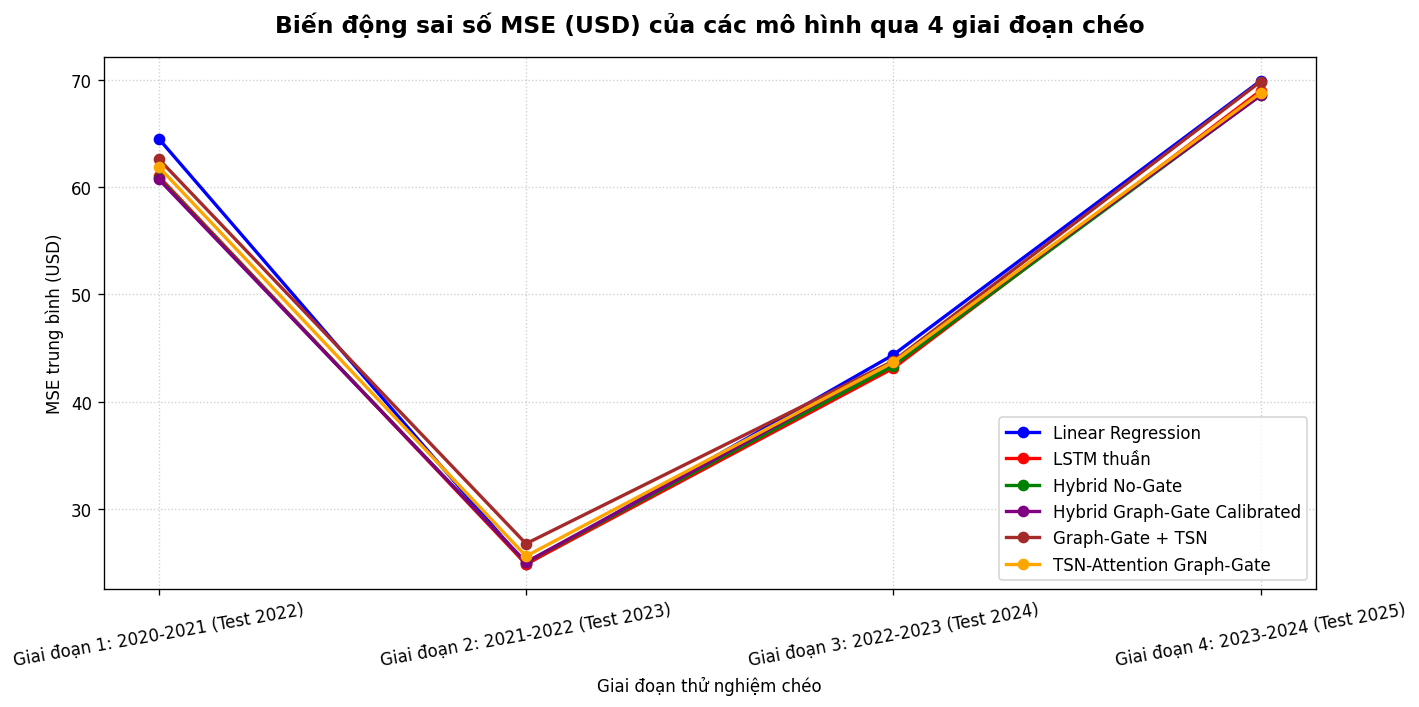

In [34]:
# CELL 25 - Đánh giá đa giai đoạn chéo (Multi-window Verification Pipeline)
# Mục tiêu: Đánh giá độ ổn định và tính tổng quát của mô hình chéo qua 4 giai đoạn thị trường thực tế:
# - Giai đoạn 1: Train 2020-2021 + Test đầu năm 2022 (Khủng hoảng đại dịch & lạm phát mới nổi).
# - Giai đoạn 2: Train 2021-2022 + Test đầu năm 2023 (Thời kỳ thắt chặt chính sách tiền tệ mạnh).
# - Giai đoạn 3: Train 2022-2023 + Test đầu năm 2024 (Thời kỳ phục hồi và bong bóng cổ phiếu công nghệ).
# - Giai đoạn 4: Train 2023-2024 + Test đầu năm 2025 (Thời kỳ tăng trưởng phân hóa cực stress).
# Kết quả đánh giá được thực hiện unscaled trên đơn vị giá USD thực tế và so sánh trực quan.
verify_windows = [
    {"name": "Giai đoạn 1: 2020-2021 (Test 2022)", "start_date": "2022-01-01", "train_days": 252 * 2},
    {"name": "Giai đoạn 2: 2021-2022 (Test 2023)", "start_date": "2023-01-01", "train_days": 252 * 2},
    {"name": "Giai đoạn 3: 2022-2023 (Test 2024)", "start_date": "2024-01-01", "train_days": 252 * 2},
    {"name": "Giai đoạn 4: 2023-2024 (Test 2025)", "start_date": "2025-01-01", "train_days": 252 * 2}
]
def resolve_forward_test_indices(dates, start_date, n_days):
    date_index = pd.DatetimeIndex(dates)
    candidates = np.where(date_index >= pd.Timestamp(start_date))[0].astype(int)
    if len(candidates) < n_days:
        raise ValueError(f"Không đủ {n_days} ngày test sau {start_date}.")
    return candidates[:n_days]
verify_summary_rows = []
for w in verify_windows:
    print("=" * 60)
    print(f"BẮT ĐẦU CHẠY THỬ NGHIỆM: {w['name']}")
    print("=" * 60)
    
    verify_test_indices = resolve_forward_test_indices(dates, w["start_date"], EXP_TEST_DAYS)
    verify_first_test_t = int(verify_test_indices[0])
    
    verify_scaled_features_3d, _, _, _, verify_train_start_t, verify_train_end_t = fit_and_scale_for_expanding_initial_window(
        features_3d,
        first_test_t=verify_first_test_t,
        initial_train_days=w["train_days"]
    )
    verify_close_only_3d = verify_scaled_features_3d[:, :, TARGET_IDX:TARGET_IDX+1].copy()
    verify_full_node_3d = verify_scaled_features_3d.copy()
    
    print("Huấn luyện từ:", dates[verify_train_start_t].date(), "đến", dates[verify_train_end_t].date())
    print("Kiểm thử từ:", dates[verify_test_indices[0]].date(), "đến", dates[verify_test_indices[-1]].date())
    
    # 1. Chạy Linear Regression
    lin_metrics, _, _, _, _, _ = run_expanding_linear_backtest(
        test_indices=verify_test_indices,
        first_test_t=verify_first_test_t,
        close_only_3d=verify_close_only_3d,
        full_node_3d=verify_full_node_3d,
        log_prefix=f"[{w['name']} - Linear]"
    )
    
    # 2. Chạy LSTM và 2 Hybrid
    (
        lstm_metrics, _, _, _, _, _,
        no_gate_metrics, _, _, _, _, _,
        graph_gate_metrics, _, _, _, _, _,
        _, _
    ) = run_joint_expanding_lstm_hybrid_backtest(
        test_indices=verify_test_indices,
        first_test_t=verify_first_test_t,
        close_only_3d=verify_close_only_3d,
        full_node_3d=verify_full_node_3d,
        log_prefix=f"[{w['name']} - GNN] ",
        calibrate_graph_gate=True
    )
    
    # 3. Chạy TSN models
    (
        gg_tsn_metrics, _, _, _, _, _,
        tsn_attn_metrics, _, _, _, _, _,
        _, _, _, _
    ) = run_tsn_expanding_backtest(
        test_indices=verify_test_indices,
        first_test_t=verify_first_test_t,
        close_only_3d=verify_close_only_3d,
        full_node_3d=verify_full_node_3d,
        log_prefix=f"[{w['name']} - TSN]"
    )
    # Lưu trữ kết quả
    verify_summary_rows.append({"Window": w["name"], "Model": "Linear Regression", "MSE": lin_metrics["MSE"], "Directional Accuracy": lin_metrics["Directional_Accuracy"]})
    verify_summary_rows.append({"Window": w["name"], "Model": "LSTM thuần", "MSE": lstm_metrics["MSE"], "Directional Accuracy": lstm_metrics["Directional_Accuracy"]})
    verify_summary_rows.append({"Window": w["name"], "Model": "Hybrid No-Gate", "MSE": no_gate_metrics["MSE"], "Directional Accuracy": no_gate_metrics["Directional_Accuracy"]})
    verify_summary_rows.append({"Window": w["name"], "Model": "Hybrid Graph-Gate Calibrated", "MSE": graph_gate_metrics["MSE"], "Directional Accuracy": graph_gate_metrics["Directional_Accuracy"]})
    verify_summary_rows.append({"Window": w["name"], "Model": "Graph-Gate + TSN", "MSE": gg_tsn_metrics["MSE"], "Directional Accuracy": gg_tsn_metrics["Directional_Accuracy"]})
    verify_summary_rows.append({"Window": w["name"], "Model": "TSN-Attention Graph-Gate", "MSE": tsn_attn_metrics["MSE"], "Directional Accuracy": tsn_attn_metrics["Directional_Accuracy"]})
verify_summary_df = pd.DataFrame(verify_summary_rows)
print("\n" + "=" * 60)
print("BẢNG TỔNG HỢP SO SÁNH HIỆU NĂNG ĐA GIAI ĐOẠN (ĐƠN VỊ USD THỰC TẾ)")
print("=" * 60)
display(verify_summary_df)
# ==========================
# Vẽ biểu đồ đường chẩn đoán xu hướng đa giai đoạn
# ==========================
plt.figure(figsize=(12, 6))
window_names = [w["name"] for w in verify_windows]
for model_name, color in zip(
    ["Linear Regression", "LSTM thuần", "Hybrid No-Gate", "Hybrid Graph-Gate Calibrated", "Graph-Gate + TSN", "TSN-Attention Graph-Gate"],
    ["blue", "red", "green", "purple", "brown", "orange"]
):
    model_df = verify_summary_df[verify_summary_df["Model"] == model_name]
    plt.plot(window_names, model_df["MSE"], label=model_name, marker="o", color=color, linewidth=2.0)
plt.title("Biến động sai số MSE (USD) của các mô hình qua 4 giai đoạn chéo", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Giai đoạn thử nghiệm chéo")
plt.ylabel("MSE trung bình (USD)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.xticks(rotation=10, ha="center")
plt.tight_layout()
plt.show()


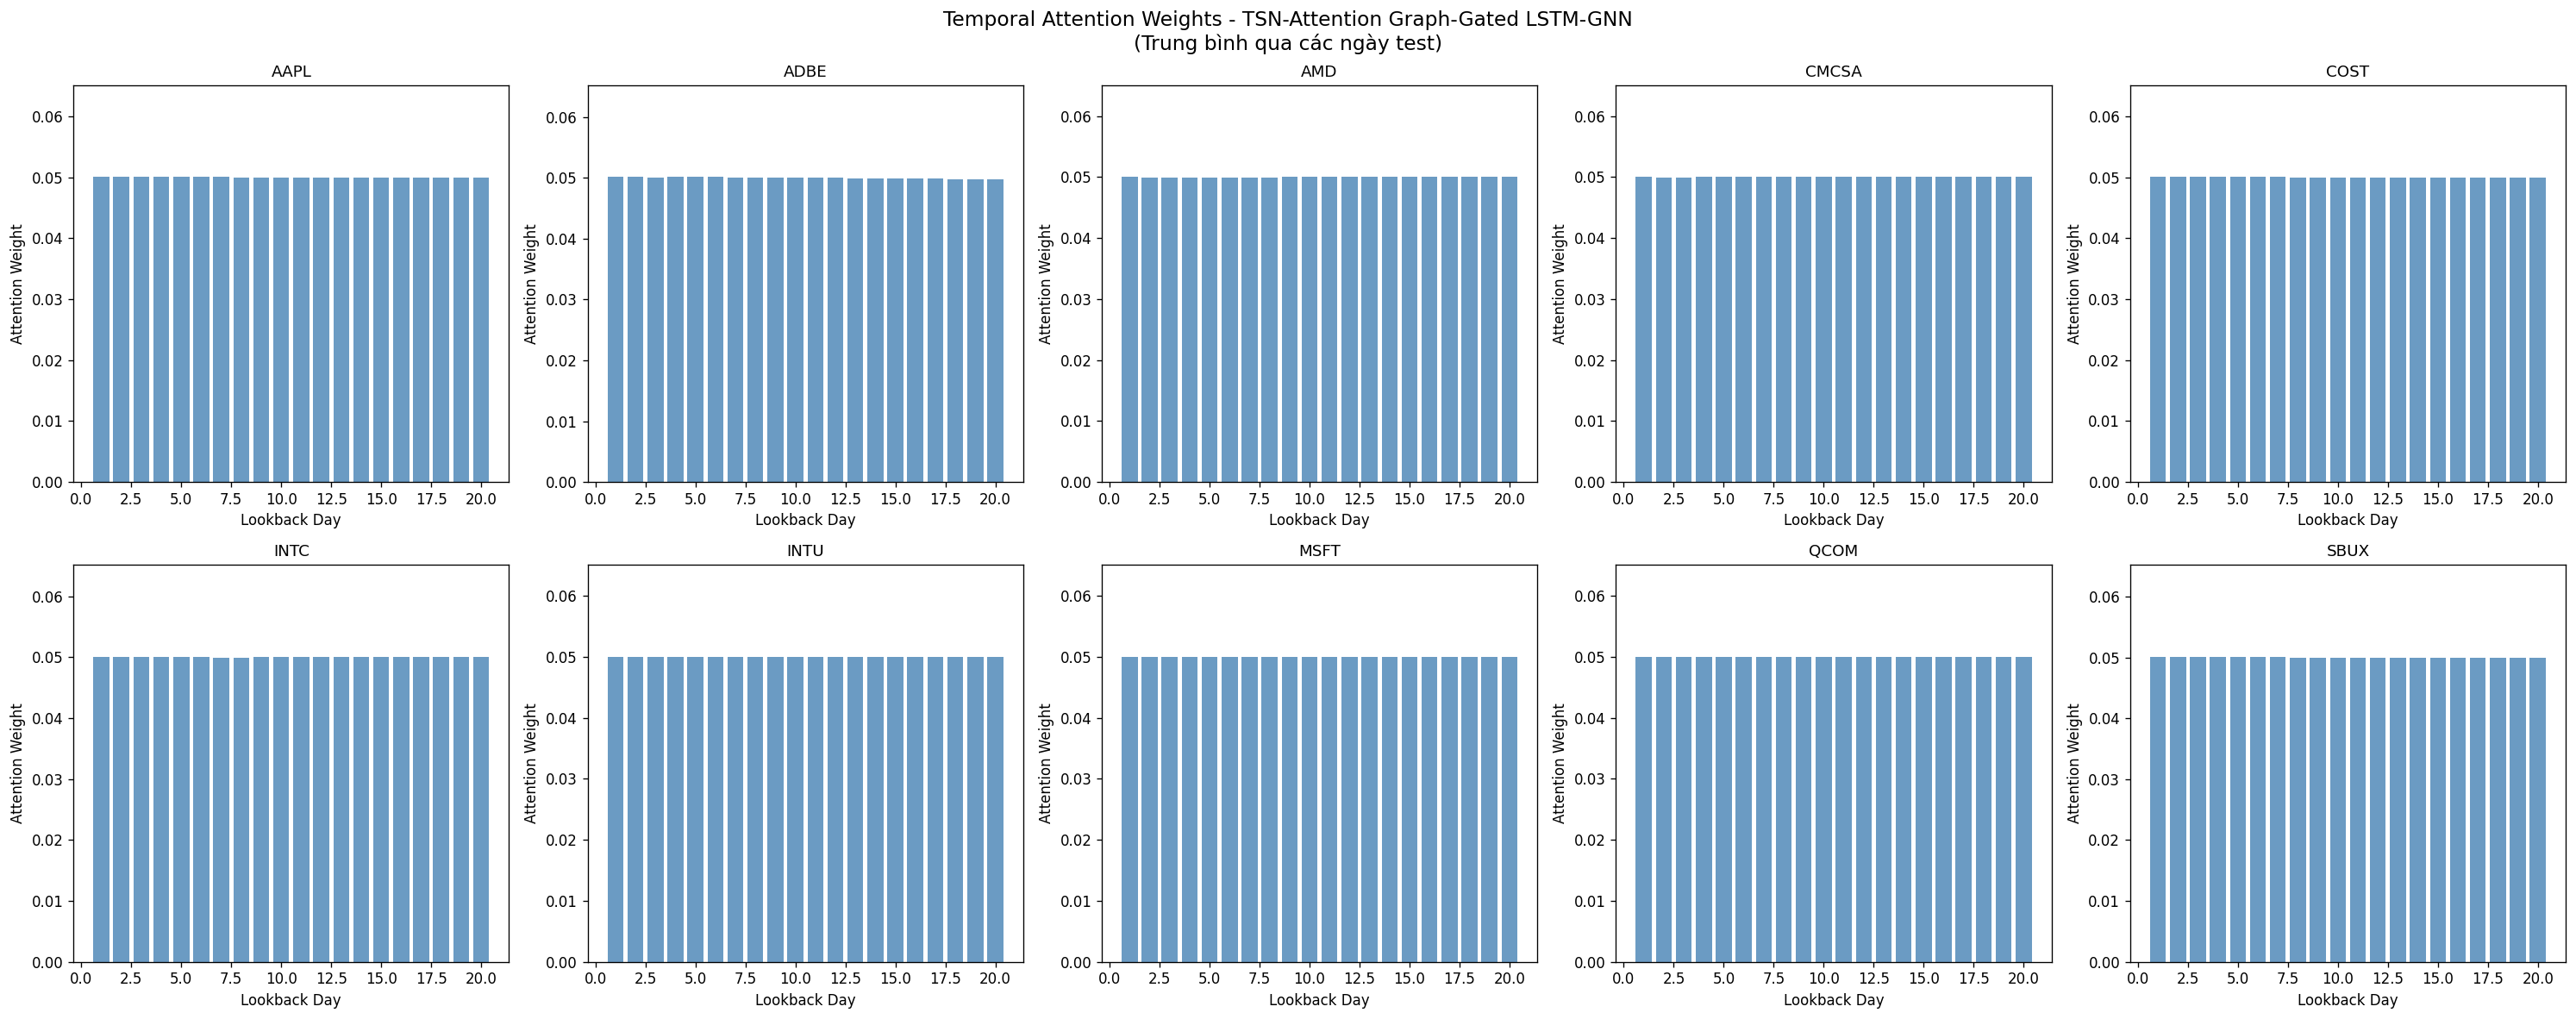

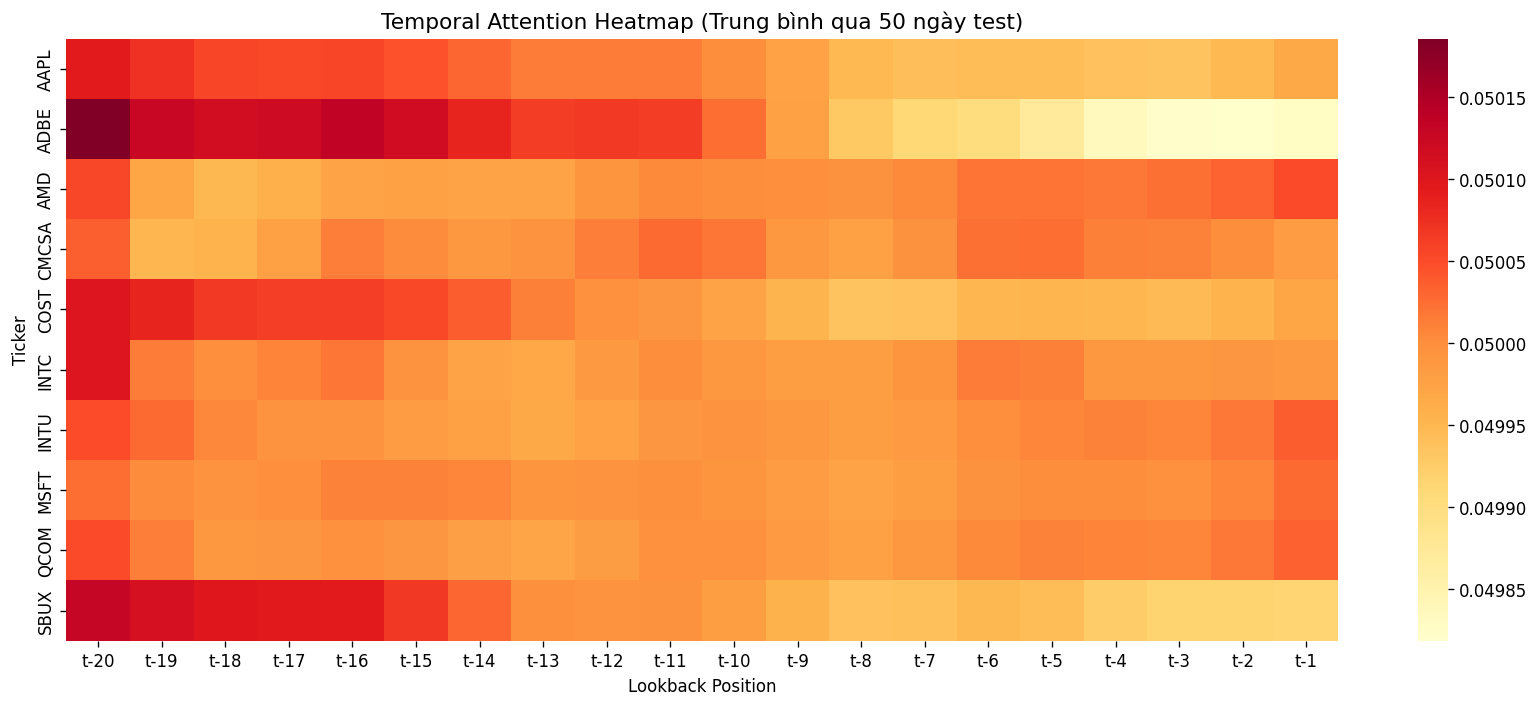

In [35]:
# CELL 26 - Heatmap Temporal Attention Weights (TSN-Attention)
# Mục tiêu: trực quan hóa attention weights cho 20 ngày lookback theo ticker

import seaborn as sns

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
fig.suptitle("Temporal Attention Weights - TSN-Attention Graph-Gated LSTM-GNN\n(Trung bình qua các ngày test)", fontsize=14)

mean_attn = tsn_attn_weights_all.mean(axis=0)

for j, ticker in enumerate(TICKERS):
    ax = axes[j // 5, j % 5]
    attn_j = mean_attn[j, :]
    ax.bar(range(1, LOOKBACK + 1), attn_j, color="steelblue", alpha=0.8)
    ax.set_title(ticker, fontsize=11)
    ax.set_xlabel("Lookback Day")
    ax.set_ylabel("Attention Weight")
    ax.set_ylim(0, attn_j.max() * 1.3)

plt.tight_layout()
plt.show()

# Heatmap tổng hợp
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    mean_attn,
    xticklabels=[f"t-{LOOKBACK-i}" for i in range(LOOKBACK)],
    yticklabels=TICKERS,
    cmap="YlOrRd",
    annot=False,
    ax=ax
)
ax.set_title("Temporal Attention Heatmap (Trung bình qua 50 ngày test)", fontsize=13)
ax.set_xlabel("Lookback Position")
ax.set_ylabel("Ticker")
plt.tight_layout()
plt.show()


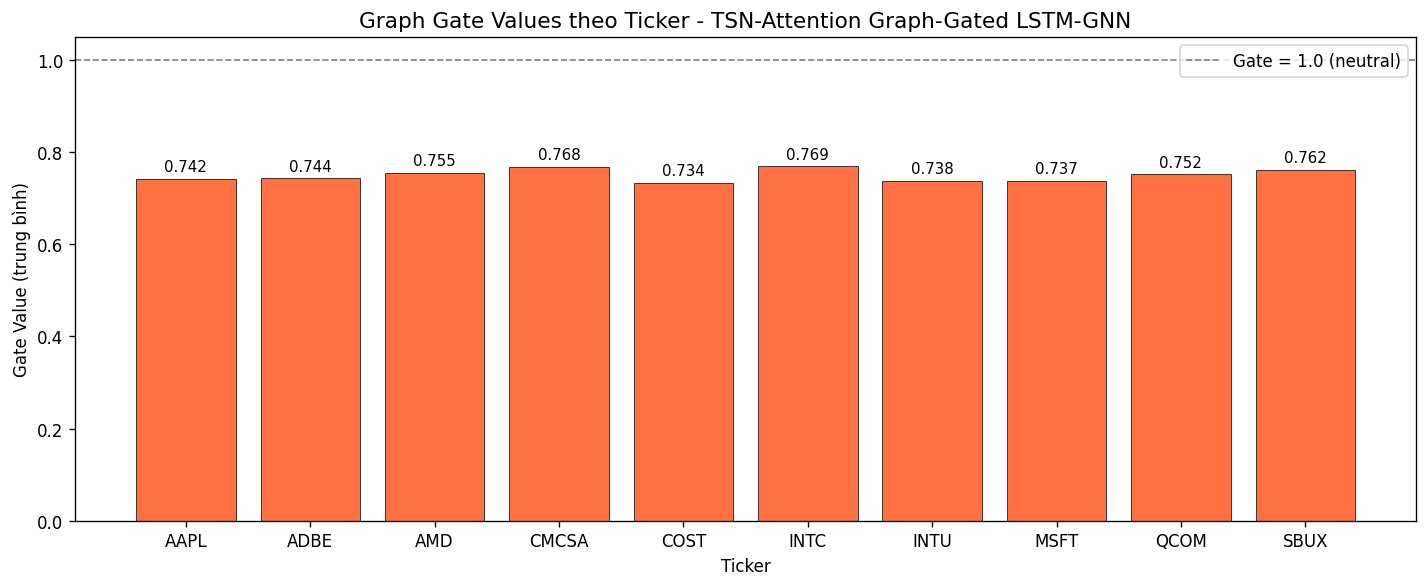

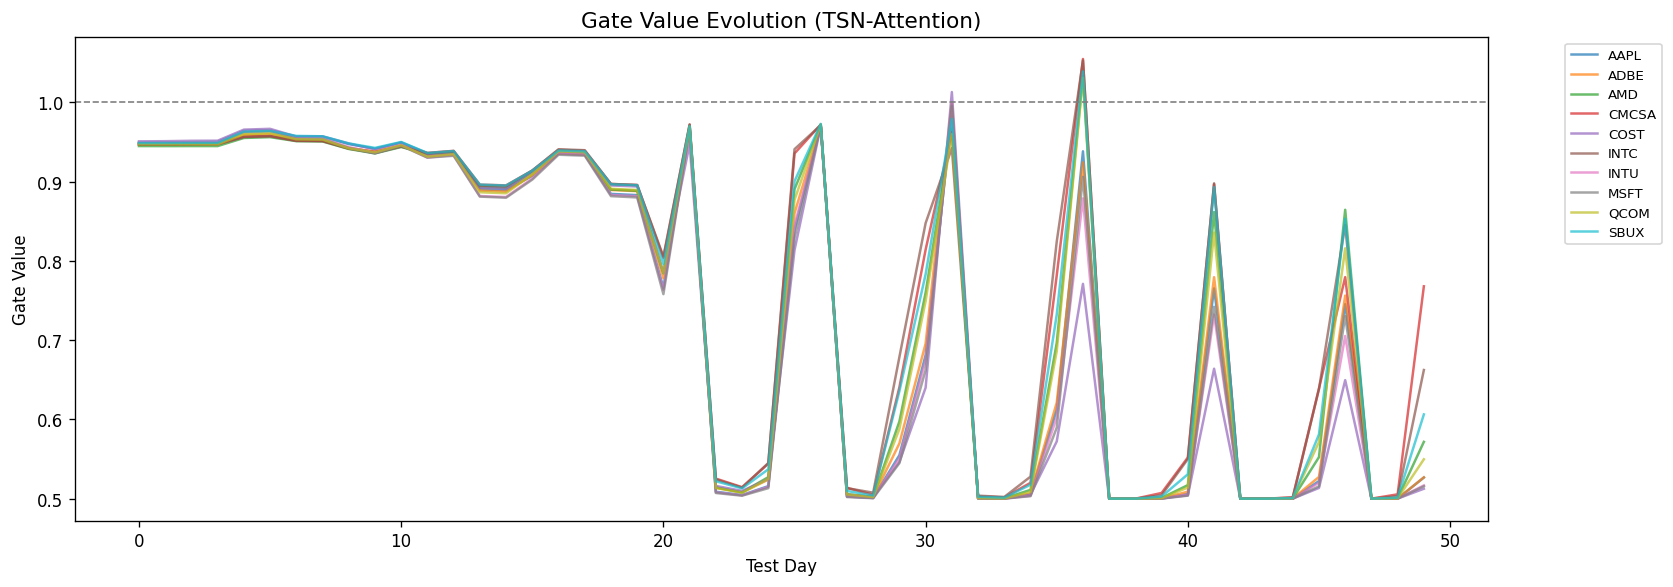

In [36]:
# CELL 27 - Bar Chart Gate Values theo Ticker (TSN-Attention)
# Mục tiêu: so sánh mức đóng góp graph gate theo từng ticker

mean_gate = tsn_gate_values_all.mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#4CAF50" if g >= 1.0 else "#FF5722" for g in mean_gate]
bars = ax.bar(TICKERS, mean_gate, color=colors, alpha=0.85, edgecolor="black", linewidth=0.5)
ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=1, label="Gate = 1.0 (neutral)")
ax.set_title("Graph Gate Values theo Ticker - TSN-Attention Graph-Gated LSTM-GNN", fontsize=13)
ax.set_xlabel("Ticker")
ax.set_ylabel("Gate Value (trung bình)")
ax.legend()

for bar, val in zip(bars, mean_gate):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{val:.3f}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Gate evolution over time
fig, ax = plt.subplots(figsize=(14, 5))
for j, ticker in enumerate(TICKERS):
    gate_j = tsn_gate_values_all[:, j]
    ax.plot(range(len(gate_j)), gate_j, label=ticker, alpha=0.7)
ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Gate Value Evolution (TSN-Attention)", fontsize=13)
ax.set_xlabel("Test Day")
ax.set_ylabel("Gate Value")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


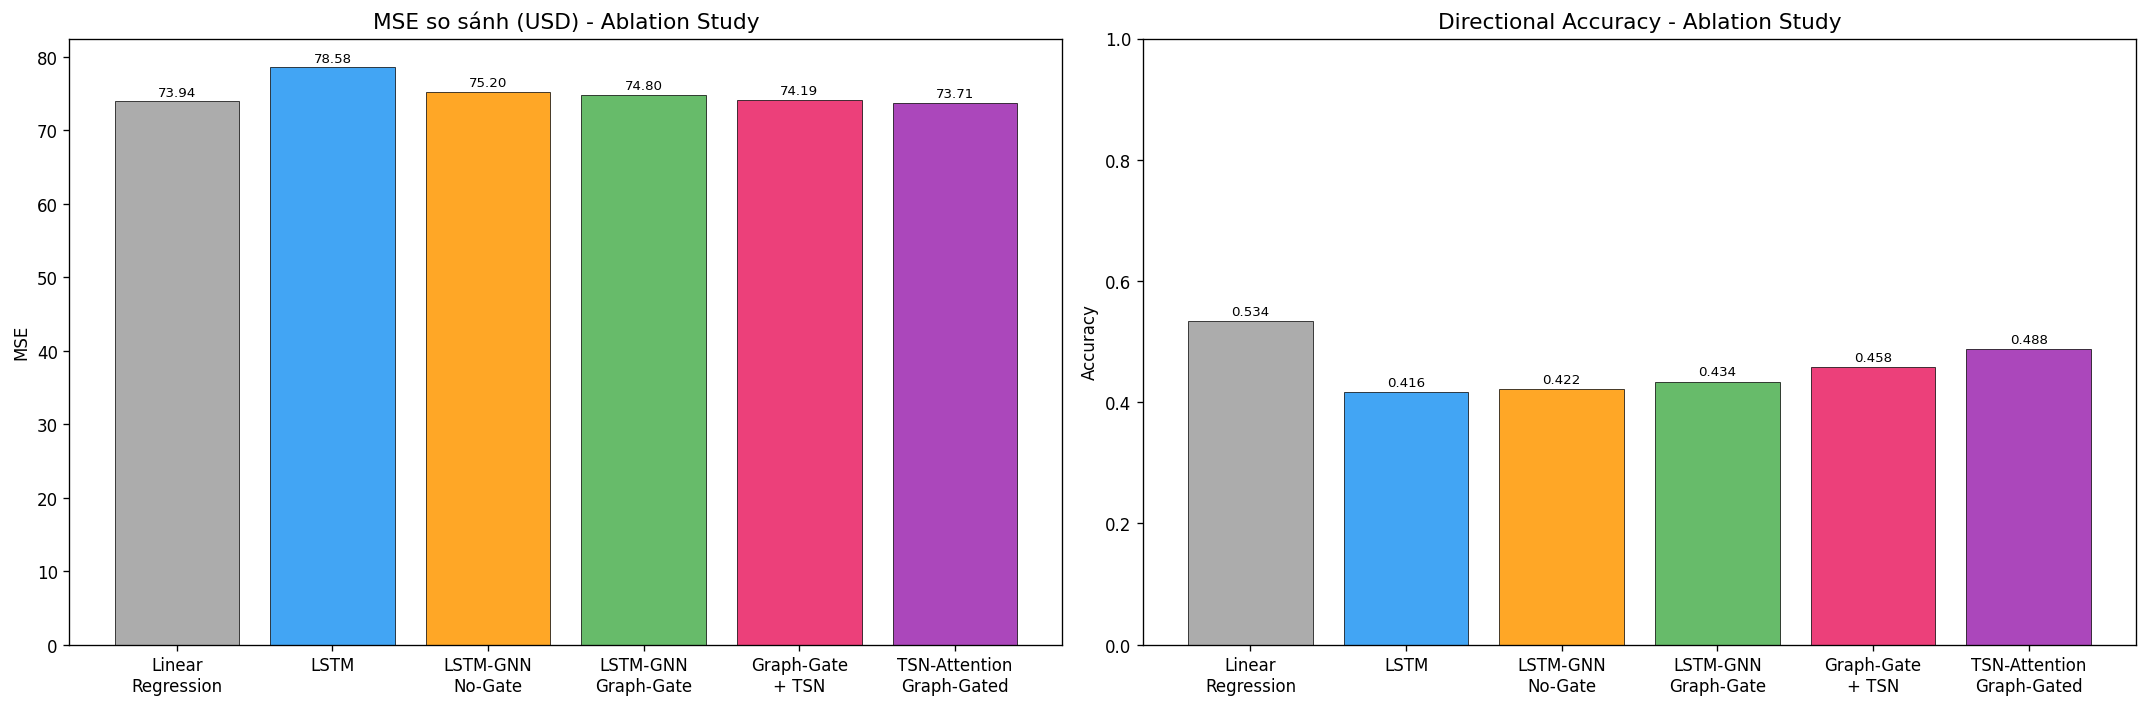

In [37]:
# CELL 28 - Ablation Study Bar Chart
# Mục tiêu: trực quan hóa hiệu năng 6 mô hình

model_names = [
    "Linear\nRegression",
    "LSTM",
    "LSTM-GNN\nNo-Gate",
    "LSTM-GNN\nGraph-Gate",
    "Graph-Gate\n+ TSN",
    "TSN-Attention\nGraph-Gated"
]

mse_vals = [
    linear_exp_metrics["MSE"],
    lstm_exp_metrics["MSE"],
    no_gate_exp_metrics["MSE"],
    graph_gate_exp_metrics["MSE"],
    gg_tsn_exp_metrics["MSE"],
    tsn_attn_exp_metrics["MSE"]
]

da_vals = [
    linear_exp_metrics["Directional_Accuracy"],
    lstm_exp_metrics["Directional_Accuracy"],
    no_gate_exp_metrics["Directional_Accuracy"],
    graph_gate_exp_metrics["Directional_Accuracy"],
    gg_tsn_exp_metrics["Directional_Accuracy"],
    tsn_attn_exp_metrics["Directional_Accuracy"]
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

colors = ["#9E9E9E", "#2196F3", "#FF9800", "#4CAF50", "#E91E63", "#9C27B0"]
ax1.bar(model_names, mse_vals, color=colors, alpha=0.85, edgecolor="black", linewidth=0.5)
ax1.set_title("MSE so sánh (USD) - Ablation Study", fontsize=13)
ax1.set_ylabel("MSE")
for i, v in enumerate(mse_vals):
    ax1.text(i, v + max(mse_vals) * 0.01, f"{v:.2f}", ha="center", fontsize=8)

ax2.bar(model_names, da_vals, color=colors, alpha=0.85, edgecolor="black", linewidth=0.5)
ax2.set_title("Directional Accuracy - Ablation Study", fontsize=13)
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1.0)
for i, v in enumerate(da_vals):
    ax2.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()
